In [ ]:
# ============================================================
# 01 - CONFIGURATION
# ============================================================

TEST_MODE = True

# Reproducibility
SEED = 42

# Data
WINDOW_SIZE = 256
STRIDE = 1
SMOOTHING_WINDOW = 10

# Training
if TEST_MODE:
    EPOCHS = 3
    BATCH_SIZE = 8
    MAX_TRAIN_TRIPS = 4
    MAX_VAL_TRIPS = 1
    MAX_TEST_TRIPS = 1
else:
    EPOCHS = 100
    BATCH_SIZE = 32
    MAX_TRAIN_TRIPS = None
    MAX_VAL_TRIPS = None
    MAX_TEST_TRIPS = None

# Learning rate
LR = 0.0002

# L1 loss weight
LAMBDA_L1 = 100.0

print("TEST_MODE:", TEST_MODE)
print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

TEST_MODE: True
Window size: 256
Stride: 1
Epochs: 3
Batch size: 8


In [ ]:
# ============================================================
# 01 - INSTALL / IMPORT LIBRARIES
# ============================================================

!pip -q install tslearn openpyxl

In [ ]:
import os
import glob
import random
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# ============================================================
# GPU CHECK
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. Go to:")
    print("Runtime → Change runtime type → Hardware accelerator → GPU")

GPU detected:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed fixed at:", SEED)

Random seed fixed at: 42


In [ ]:
# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 02 - DATASET LOADING AND INSPECTION
# ============================================================

import os
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_DIR = "/content/drive/MyDrive/RE_PI_CycleEV"
DATA_DIR = os.path.join(PROJECT_DIR, "dataset")

print("Project directory:")
print(PROJECT_DIR)

print("\nDataset directory:")
print(DATA_DIR)

print("\nDataset folder exists:", os.path.exists(DATA_DIR))


# ------------------------------------------------------------
# Find the 70 trip CSV files
# ------------------------------------------------------------

csv_files = []

for file in os.listdir(DATA_DIR):
    if file.lower().endswith(".csv"):
        csv_files.append(os.path.join(DATA_DIR, file))

csv_files = sorted(csv_files)

print("\nNumber of CSV trip files found:", len(csv_files))


# ------------------------------------------------------------
# Display filenames
# ------------------------------------------------------------

print("\nFirst 10 trip files:")

for file in csv_files[:10]:
    print(" -", os.path.basename(file))

print("\nLast 10 trip files:")

for file in csv_files[-10:]:
    print(" -", os.path.basename(file))


# ------------------------------------------------------------
# Check expected trip groups
# ------------------------------------------------------------

summer_files = [
    f for f in csv_files
    if os.path.basename(f).upper().startswith("TRIPA")
]

winter_files = [
    f for f in csv_files
    if os.path.basename(f).upper().startswith("TRIPB")
]

print("\nSummer / Group A files:", len(summer_files))
print("Winter / Group B files:", len(winter_files))


# ------------------------------------------------------------
# Check for unexpected CSV filenames
# ------------------------------------------------------------

expected_names = {
    f"TripA{i:02d}.csv" for i in range(1, 33)
}

expected_names.update(
    {f"TripB{i:02d}.csv" for i in range(1, 39)}
)

actual_names = {
    os.path.basename(f) for f in csv_files
}

unexpected_files = sorted(actual_names - expected_names)
missing_files = sorted(expected_names - actual_names)

print("\nUnexpected CSV files:", unexpected_files)
print("Missing expected trip files:", missing_files)

Project directory:
/content/drive/MyDrive/RE_PI_CycleEV

Dataset directory:
/content/drive/MyDrive/RE_PI_CycleEV/dataset

Dataset folder exists: True

Number of CSV trip files found: 70

First 10 trip files:
 - TripA01.csv
 - TripA02.csv
 - TripA03.csv
 - TripA04.csv
 - TripA05.csv
 - TripA06.csv
 - TripA07.csv
 - TripA08.csv
 - TripA09.csv
 - TripA10.csv

Last 10 trip files:
 - TripB29.csv
 - TripB30.csv
 - TripB31.csv
 - TripB32.csv
 - TripB33.csv
 - TripB34.csv
 - TripB35.csv
 - TripB36.csv
 - TripB37.csv
 - TripB38.csv

Summer / Group A files: 32
Winter / Group B files: 38

Unexpected CSV files: []
Missing expected trip files: []


In [ ]:
# ============================================================
# 02 - INSPECT ONE REAL TRIP FILE
# ============================================================

# Use TripA01 as the first representative trip
first_trip_file = [
    f for f in csv_files
    if os.path.basename(f) == "TripA01.csv"
][0]

print("Inspecting file:")
print(first_trip_file)


# ------------------------------------------------------------
# Read the CSV
# ------------------------------------------------------------

trip_df = pd.read_csv(
    first_trip_file,
    encoding="latin1"
)

print("\nShape:")
print(trip_df.shape)


# ------------------------------------------------------------
# Display actual column names
# ------------------------------------------------------------

print("\nACTUAL COLUMN NAMES:")
for i, col in enumerate(trip_df.columns):
    print(i, repr(col))


# ------------------------------------------------------------
# Display first 5 rows
# ------------------------------------------------------------

print("\nFIRST 5 ROWS:")
display(trip_df.head())

Inspecting file:
/content/drive/MyDrive/RE_PI_CycleEV/dataset/TripA01.csv

Shape:
(10090, 1)

ACTUAL COLUMN NAMES:
0 'Time [s];Velocity [km/h];Elevation [m];Throttle [%];Motor Torque [Nm];Longitudinal Acceleration [m/s^2];Regenerative Braking Signal ;Battery Voltage [V];Battery Current [A];Battery Temperature [°C];max. Battery Temperature [°C];SoC [%];displayed SoC [%];min. SoC [%];max. SoC [%);Heating Power CAN [kW];Heating Power LIN [W];Requested Heating Power [W];AirCon Power [kW];Heater Signal;Heater Voltage [V];Heater Current [A];Ambient Temperature [°C];Coolant Temperature Heatercore [°C];Requested Coolant Temperature [°C];Coolant Temperature Inlet [°C];Heat Exchanger Temperature [°C];Cabin Temperature Sensor [°C]'

FIRST 5 ROWS:


,Time [s];Velocity [km/h];Elevation [m];Throttle [%];Motor Torque [Nm];Longitudinal Acceleration [m/s^2];Regenerative Braking Signal ;Battery Voltage [V];Battery Current [A];Battery Temperature [°C];max. Battery Temperature [°C];SoC [%];displayed SoC [%];min. SoC [%];max. SoC [%);Heating Power CAN [kW];Heating Power LIN [W];Requested Heating Power [W];AirCon Power [kW];Heater Signal;Heater Voltage [V];Heater Current [A];Ambient Temperature [°C];Coolant Temperature Heatercore [°C];Requested Coolant Temperature [°C];Coolant Temperature Inlet [°C];Heat Exchanger Temperature [°C];Cabin Temperature Sensor [°C]
0,0;0;574;0;0;-0.03;0;391.4;-2.2;21;22;86.9;100;...
1,0.1;0;574;0;0;0;0;391.4;-2.21;21;22;86.9;100;8...
2,0.2;0;574;0;0;-0.01;0;391.4;-2.26;21;22;86.9;1...
3,0.3;0;574;0;0;-0.03;0;391.4;-2.3;21;22;86.9;10...
4,0.4;0;574;0;0;-0.03;0;391.4;-2.3;21;22;86.9;10...


In [ ]:
# ============================================================
# 02 - READ TRIPA01 CORRECTLY
# ============================================================

trip_df = pd.read_csv(
    first_trip_file,
    sep=";",
    encoding="latin1"
)

print("Shape:", trip_df.shape)

print("\nNumber of columns:", len(trip_df.columns))

print("\nACTUAL COLUMN NAMES:")
for i, col in enumerate(trip_df.columns):
    print(i, repr(col))

print("\nFIRST 5 ROWS:")
display(trip_df.head())

Shape: (10090, 28)

Number of columns: 28

ACTUAL COLUMN NAMES:
0 'Time [s]'
1 'Velocity [km/h]'
2 'Elevation [m]'
3 'Throttle [%]'
4 'Motor Torque [Nm]'
5 'Longitudinal Acceleration [m/s^2]'
6 'Regenerative Braking Signal '
7 'Battery Voltage [V]'
8 'Battery Current [A]'
9 'Battery Temperature [°C]'
10 'max. Battery Temperature [°C]'
11 'SoC [%]'
12 'displayed SoC [%]'
13 'min. SoC [%]'
14 'max. SoC [%)'
15 'Heating Power CAN [kW]'
16 'Heating Power LIN [W]'
17 'Requested Heating Power [W]'
18 'AirCon Power [kW]'
19 'Heater Signal'
20 'Heater Voltage [V]'
21 'Heater Current [A]'
22 'Ambient Temperature [°C]'
23 'Coolant Temperature Heatercore [°C]'
24 'Requested Coolant Temperature [°C]'
25 'Coolant Temperature Inlet [°C]'
26 'Heat Exchanger Temperature [°C]'
27 'Cabin Temperature Sensor [°C]'

FIRST 5 ROWS:


,Time [s],Velocity [km/h],Elevation [m],Throttle [%],Motor Torque [Nm],Longitudinal Acceleration [m/s^2],Regenerative Braking Signal,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],...,AirCon Power [kW],Heater Signal,Heater Voltage [V],Heater Current [A],Ambient Temperature [°C],Coolant Temperature Heatercore [°C],Requested Coolant Temperature [°C],Coolant Temperature Inlet [°C],Heat Exchanger Temperature [°C],Cabin Temperature Sensor [°C]
0,0.0,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.20,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
1,0.1,0.0,574.0,0.0,0.0,0.00,0.0,391.4,-2.21,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
2,0.2,0.0,574.0,0.0,0.0,-0.01,0.0,391.4,-2.26,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
3,0.3,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5
4,0.4,0.0,574.0,0.0,0.0,-0.03,0.0,391.4,-2.30,21.0,...,0.4,1,0,0,25.5,0,0,0,30.5,24.5


In [ ]:
# ============================================================
# 02 - CHECK ALL 70 TRIP FILES
# ============================================================

print("Checking all trip files...")
print("=" * 60)

trip_check_results = []

for path in csv_files:

    trip_name = os.path.basename(path)

    try:
        df = pd.read_csv(
            path,
            sep=";",
            encoding="latin1"
        )

        # Calculate time interval
        if "Time [s]" in df.columns and len(df) > 1:
            time_values = pd.to_numeric(
                df["Time [s]"],
                errors="coerce"
            )

            time_diff = time_values.diff().dropna()

            median_dt = time_diff.median()
        else:
            median_dt = np.nan

        trip_check_results.append({
            "Trip": trip_name,
            "Rows": len(df),
            "Columns": len(df.columns),
            "Missing_Values": int(df.isna().sum().sum()),
            "Median_Time_Step_s": median_dt,
            "Status": "OK"
        })

    except Exception as e:

        trip_check_results.append({
            "Trip": trip_name,
            "Rows": np.nan,
            "Columns": np.nan,
            "Missing_Values": np.nan,
            "Median_Time_Step_s": np.nan,
            "Status": f"ERROR: {e}"
        })


# Convert results to DataFrame
trip_check_df = pd.DataFrame(trip_check_results)

print("\nCHECK COMPLETE")
print("=" * 60)

print("\nNumber of files checked:",
      len(trip_check_df))

print("\nStatus counts:")
print(trip_check_df["Status"].value_counts())

print("\nColumn counts:")
print(trip_check_df["Columns"].value_counts())

print("\nFirst 10 trips:")
display(trip_check_df.head(10))

print("\nLast 10 trips:")
display(trip_check_df.tail(10))

Checking all trip files...

CHECK COMPLETE

Number of files checked: 70

Status counts:
Status
OK    70
Name: count, dtype: int64

Column counts:
Columns
48    38
23    18
28    12
24     1
22     1
Name: count, dtype: int64

First 10 trips:


,Trip,Rows,Columns,Missing_Values,Median_Time_Step_s,Status
0,TripA01.csv,10090,28,0,0.1,OK
1,TripA02.csv,14130,28,0,0.1,OK
2,TripA03.csv,6706,23,0,0.1,OK
3,TripA04.csv,4124,23,0,0.1,OK
4,TripA05.csv,13667,23,0,0.1,OK
5,TripA06.csv,31645,23,0,0.1,OK
6,TripA07.csv,20933,23,0,0.1,OK
7,TripA08.csv,28059,23,0,0.1,OK
8,TripA09.csv,18344,23,0,0.1,OK
9,TripA10.csv,14176,23,0,0.1,OK



Last 10 trips:


,Trip,Rows,Columns,Missing_Values,Median_Time_Step_s,Status
60,TripB29.csv,9686,48,64,0.1,OK
61,TripB30.csv,9209,48,48,0.1,OK
62,TripB31.csv,10969,48,4,0.1,OK
63,TripB32.csv,7958,48,48,0.1,OK
64,TripB33.csv,5480,48,0,0.1,OK
65,TripB34.csv,7338,48,17748,0.1,OK
66,TripB35.csv,13626,48,104,0.1,OK
67,TripB36.csv,28523,48,8,0.1,OK
68,TripB37.csv,14173,48,64,0.1,OK
69,TripB38.csv,16429,48,100,0.1,OK


In [ ]:
# ============================================================
# 02 - FIND COMMON COLUMNS ACROSS ALL 70 TRIPS
# ============================================================

print("Finding columns available in every trip...")
print("=" * 60)

# Store column names for every trip
trip_columns = {}

for path in csv_files:

    trip_name = os.path.basename(path)

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        nrows=5
    )

    trip_columns[trip_name] = list(df.columns)


# ------------------------------------------------------------
# Find columns common to ALL 70 trips
# ------------------------------------------------------------

common_columns = set(trip_columns[csv_files[0].split("/")[-1]])

for cols in trip_columns.values():
    common_columns = common_columns.intersection(set(cols))

common_columns = sorted(common_columns)


print("\nNumber of columns common to ALL 70 trips:")
print(len(common_columns))

print("\nCOMMON COLUMNS:")
for i, col in enumerate(common_columns):
    print(i, repr(col))


# ------------------------------------------------------------
# Show column counts by trip
# ------------------------------------------------------------

print("\n\nColumn count distribution:")
print(trip_check_df["Columns"].value_counts().sort_index())

Finding columns available in every trip...

Number of columns common to ALL 70 trips:
21

COMMON COLUMNS:
0 'AirCon Power [kW]'
1 'Ambient Temperature [°C]'
2 'Battery Current [A]'
3 'Battery Temperature [°C]'
4 'Battery Voltage [V]'
5 'Cabin Temperature Sensor [°C]'
6 'Elevation [m]'
7 'Heat Exchanger Temperature [°C]'
8 'Heater Signal'
9 'Heating Power CAN [kW]'
10 'Longitudinal Acceleration [m/s^2]'
11 'Motor Torque [Nm]'
12 'Regenerative Braking Signal '
13 'Requested Heating Power [W]'
14 'SoC [%]'
15 'Throttle [%]'
16 'Time [s]'
17 'displayed SoC [%]'
18 'max. Battery Temperature [°C]'
19 'max. SoC [%)'
20 'min. SoC [%]'


Column count distribution:
Columns
22     1
23    18
24     1
28    12
48    38
Name: count, dtype: int64


In [ ]:
# ============================================================
# 02 - CHECK REQUIRED PROJECT FEATURES ACROSS ALL TRIPS
# ============================================================

required_keywords = {
    "Velocity": ["Velocity"],
    "Battery Current": ["Battery Current"],
    "Battery Temperature": ["Battery Temperature"],
    "Elevation": ["Elevation"],
    "Throttle": ["Throttle"],
    "Requested Heating Power": ["Requested Heating Power"],
    "AirCon Power": ["AirCon Power"],
    "Heater Voltage": ["Heater Voltage"],
    "Heater Current": ["Heater Current"],
    "Ambient Temperature": ["Ambient Temperature"],
    "SOC": ["SoC", "SOC"],
    "Battery Voltage": ["Battery Voltage"],
    "Motor Torque": ["Motor Torque"],
    "Longitudinal Acceleration": ["Longitudinal Acceleration"]
}


print("Checking required project features...")
print("=" * 70)


feature_presence = []

for feature, keywords in required_keywords.items():

    trips_with_feature = []
    trips_without_feature = []

    for path in csv_files:

        trip_name = os.path.basename(path)

        # Read only header
        df_header = pd.read_csv(
            path,
            sep=";",
            encoding="latin1",
            nrows=0
        )

        columns = list(df_header.columns)

        found = False

        for col in columns:
            for keyword in keywords:
                if keyword.lower() in str(col).lower():
                    found = True
                    break
            if found:
                break

        if found:
            trips_with_feature.append(trip_name)
        else:
            trips_without_feature.append(trip_name)

    feature_presence.append({
        "Feature": feature,
        "Trips_with_feature": len(trips_with_feature),
        "Trips_without_feature": len(trips_without_feature),
        "Example_missing": trips_without_feature[:5]
    })


feature_presence_df = pd.DataFrame(feature_presence)

display(feature_presence_df)

Checking required project features...


,Feature,Trips_with_feature,Trips_without_feature,Example_missing
0,Velocity,70,0,[]
1,Battery Current,70,0,[]
2,Battery Temperature,70,0,[]
3,Elevation,70,0,[]
4,Throttle,70,0,[]
5,Requested Heating Power,70,0,[]
6,AirCon Power,70,0,[]
7,Heater Voltage,50,20,"[TripA03.csv, TripA04.csv, TripA05.csv, TripA0..."
8,Heater Current,50,20,"[TripA03.csv, TripA04.csv, TripA05.csv, TripA0..."
9,Ambient Temperature,70,0,[]


In [ ]:
# ============================================================
# 02 - IDENTIFY TRIPS MISSING HEATER VOLTAGE / CURRENT
# ============================================================

heater_features = [
    "Heater Voltage",
    "Heater Current"
]

for feature in heater_features:

    print("\n" + "=" * 70)
    print(feature)
    print("=" * 70)

    missing_trips = []

    for path in csv_files:

        trip_name = os.path.basename(path)

        header = pd.read_csv(
            path,
            sep=";",
            encoding="latin1",
            nrows=0
        )

        columns = [str(c).strip() for c in header.columns]

        found = any(
            feature.lower() in c.lower()
            for c in columns
        )

        if not found:
            missing_trips.append(trip_name)

    print("Missing in", len(missing_trips), "trips:")
    print(missing_trips)


Heater Voltage
Missing in 20 trips:
['TripA03.csv', 'TripA04.csv', 'TripA05.csv', 'TripA06.csv', 'TripA07.csv', 'TripA08.csv', 'TripA09.csv', 'TripA10.csv', 'TripA11.csv', 'TripA12.csv', 'TripA13.csv', 'TripA14.csv', 'TripA15.csv', 'TripA16.csv', 'TripA17.csv', 'TripA18.csv', 'TripA19.csv', 'TripA20.csv', 'TripA21.csv', 'TripA22.csv']

Heater Current
Missing in 20 trips:
['TripA03.csv', 'TripA04.csv', 'TripA05.csv', 'TripA06.csv', 'TripA07.csv', 'TripA08.csv', 'TripA09.csv', 'TripA10.csv', 'TripA11.csv', 'TripA12.csv', 'TripA13.csv', 'TripA14.csv', 'TripA15.csv', 'TripA16.csv', 'TripA17.csv', 'TripA18.csv', 'TripA19.csv', 'TripA20.csv', 'TripA21.csv', 'TripA22.csv']


In [ ]:
# ============================================================
# 02 - COMPARE HEATING VARIABLES
# ============================================================

def get_trip_columns(trip_name):
    path = os.path.join(DATA_DIR, trip_name)

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        nrows=5
    )

    return list(df.columns)


# Get columns for one trip WITH heater voltage/current
columns_A02 = get_trip_columns("TripA02.csv")

# Get columns for one trip WITHOUT heater voltage/current
columns_A03 = get_trip_columns("TripA03.csv")


print("=" * 70)
print("TripA02 - available columns")
print("=" * 70)

for i, col in enumerate(columns_A02):
    print(i, repr(col))


print("\n" + "=" * 70)
print("TripA03 - available columns")
print("=" * 70)

for i, col in enumerate(columns_A03):
    print(i, repr(col))


print("\n" + "=" * 70)
print("Columns in A02 but NOT in A03")
print("=" * 70)

only_A02 = [
    col for col in columns_A02
    if col not in columns_A03
]

for col in only_A02:
    print(repr(col))


print("\n" + "=" * 70)
print("Columns common to A02 and A03")
print("=" * 70)

common_A02_A03 = [
    col for col in columns_A02
    if col in columns_A03
]

for col in common_A02_A03:
    print(repr(col))

TripA02 - available columns
0 'Time [s]'
1 'Velocity [km/h]'
2 'Elevation [m]'
3 'Throttle [%]'
4 'Motor Torque [Nm]'
5 'Longitudinal Acceleration [m/s^2]'
6 'Regenerative Braking Signal '
7 'Battery Voltage [V]'
8 'Battery Current [A]'
9 'Battery Temperature [°C]'
10 'max. Battery Temperature [°C]'
11 'SoC [%]'
12 'displayed SoC [%]'
13 'min. SoC [%]'
14 'max. SoC [%)'
15 'Heating Power CAN [kW]'
16 'Heating Power LIN [W]'
17 'Requested Heating Power [W]'
18 'AirCon Power [kW]'
19 'Heater Signal'
20 'Heater Voltage [V]'
21 'Heater Current [A]'
22 'Ambient Temperature [°C]'
23 'Coolant Temperature Heatercore [°C]'
24 'Requested Coolant Temperature [°C]'
25 'Coolant Temperature Inlet [°C]'
26 'Heat Exchanger Temperature [°C]'
27 'Cabin Temperature Sensor [°C]'

TripA03 - available columns
0 'Time [s]'
1 'Velocity [km/h]'
2 'Elevation [m]'
3 'Throttle [%]'
4 'Motor Torque [Nm]'
5 'Longitudinal Acceleration [m/s^2]'
6 'Regenerative Braking Signal '
7 'Battery Voltage [V]'
8 'Battery Curre

In [ ]:
# ============================================================
# 02 - CHECK HEATING VARIABLES IN ALL TRIPS
# ============================================================

heating_columns = [
    'Heating Power CAN [kW]',
    'Heating Power LIN [W]',
    'Requested Heating Power [W]',
    'AirCon Power [kW]',
    'Heater Signal',
    'Heater Voltage [V]',
    'Heater Current [A]',
    'Ambient Temperature [°C]'
]

heating_presence = []

for path in csv_files:
    trip_name = os.path.basename(path)
    df = pd.read_csv(path, sep=";", encoding="latin1", nrows=5)

    row = {"Trip": trip_name}

    for col in heating_columns:
        row[col] = col in df.columns

    heating_presence.append(row)

heating_presence_df = pd.DataFrame(heating_presence)

print("Heating-related variable availability across all 70 trips:")
display(heating_presence_df)

print("\nNumber of trips containing each variable:")
for col in heating_columns:
    print(f"{col:35s}: {heating_presence_df[col].sum()}/70")

Heating-related variable availability across all 70 trips:


,Trip,Heating Power CAN [kW],Heating Power LIN [W],Requested Heating Power [W],AirCon Power [kW],Heater Signal,Heater Voltage [V],Heater Current [A],Ambient Temperature [°C]
0,TripA01.csv,True,True,True,True,True,True,True,True
1,TripA02.csv,True,True,True,True,True,True,True,True
2,TripA03.csv,True,False,True,True,True,False,False,True
3,TripA04.csv,True,False,True,True,True,False,False,True
4,TripA05.csv,True,False,True,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...
65,TripB34.csv,True,True,True,True,True,True,True,True
66,TripB35.csv,True,True,True,True,True,True,True,True
67,TripB36.csv,True,True,True,True,True,True,True,True
68,TripB37.csv,True,True,True,True,True,True,True,True



Number of trips containing each variable:
Heating Power CAN [kW]             : 70/70
Heating Power LIN [W]              : 50/70
Requested Heating Power [W]        : 70/70
AirCon Power [kW]                  : 70/70
Heater Signal                      : 70/70
Heater Voltage [V]                 : 50/70
Heater Current [A]                 : 50/70
Ambient Temperature [°C]           : 70/70


In [ ]:
# ============================================================
# 02 - VERIFY SELECTED 10 INPUT + 4 OUTPUT FEATURES
# ============================================================

INPUT_FEATURES = [
    'Battery Current [A]',
    'Battery Temperature [°C]',
    'Velocity [km/h]',
    'Elevation [m]',
    'Throttle [%]',
    'Requested Heating Power [W]',
    'AirCon Power [kW]',
    'Ambient Temperature [°C]',
    'Heating Power CAN [kW]',
    'Heater Signal'
]

OUTPUT_FEATURES = [
    'SoC [%]',
    'Battery Voltage [V]',
    'Motor Torque [Nm]',
    'Longitudinal Acceleration [m/s^2]'
]

SELECTED_FEATURES = INPUT_FEATURES + OUTPUT_FEATURES

print("INPUT FEATURES:", len(INPUT_FEATURES))
for i, col in enumerate(INPUT_FEATURES, 1):
    print(f"{i:2d}. {col}")

print("\nOUTPUT FEATURES:", len(OUTPUT_FEATURES))
for i, col in enumerate(OUTPUT_FEATURES, 1):
    print(f"{i:2d}. {col}")

print("\nTOTAL SELECTED FEATURES:", len(SELECTED_FEATURES))


# Check availability in all 70 trips
print("\n" + "=" * 70)
print("FEATURE AVAILABILITY ACROSS ALL 70 TRIPS")
print("=" * 70)

for col in SELECTED_FEATURES:
    count = 0

    for path in csv_files:
        df_temp = pd.read_csv(
            path,
            sep=";",
            encoding="latin1",
            nrows=1
        )

        if col in df_temp.columns:
            count += 1

    print(f"{count:2d}/70   {col}")

INPUT FEATURES: 10
 1. Battery Current [A]
 2. Battery Temperature [°C]
 3. Velocity [km/h]
 4. Elevation [m]
 5. Throttle [%]
 6. Requested Heating Power [W]
 7. AirCon Power [kW]
 8. Ambient Temperature [°C]
 9. Heating Power CAN [kW]
10. Heater Signal

OUTPUT FEATURES: 4
 1. SoC [%]
 2. Battery Voltage [V]
 3. Motor Torque [Nm]
 4. Longitudinal Acceleration [m/s^2]

TOTAL SELECTED FEATURES: 14

FEATURE AVAILABILITY ACROSS ALL 70 TRIPS
70/70   Battery Current [A]
70/70   Battery Temperature [°C]
69/70   Velocity [km/h]
70/70   Elevation [m]
70/70   Throttle [%]
70/70   Requested Heating Power [W]
70/70   AirCon Power [kW]
70/70   Ambient Temperature [°C]
70/70   Heating Power CAN [kW]
70/70   Heater Signal
70/70   SoC [%]
70/70   Battery Voltage [V]
70/70   Motor Torque [Nm]
70/70   Longitudinal Acceleration [m/s^2]


In [ ]:
# ============================================================
# 02 - FIND THE TRIP MISSING VELOCITY
# ============================================================

velocity_column = 'Velocity [km/h]'

missing_velocity_trips = []

for path in csv_files:
    df_temp = pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        nrows=1
    )

    if velocity_column not in df_temp.columns:
        missing_velocity_trips.append(os.path.basename(path))

print("Trips missing 'Velocity [km/h]':")
for trip in missing_velocity_trips:
    print(trip)

print("\nNumber of missing trips:", len(missing_velocity_trips))

Trips missing 'Velocity [km/h]':
TripB38.csv

Number of missing trips: 1


In [ ]:
# ============================================================
# 02 - INSPECT TRIPB38 VELOCITY ISSUE
# ============================================================

trip_b38_path = os.path.join(DATA_DIR, "TripB38.csv")

b38_df = pd.read_csv(
    trip_b38_path,
    sep=";",
    encoding="latin1"
)

print("=" * 70)
print("TripB38 shape:", b38_df.shape)
print("=" * 70)

print("\nTripB38 columns:")
for i, col in enumerate(b38_df.columns):
    print(i, repr(col))

print("\n" + "=" * 70)
print("Columns containing 'speed' or 'velocity'")
print("=" * 70)

for col in b38_df.columns:
    if "velocity" in col.lower() or "speed" in col.lower():
        print(repr(col))

TripB38 shape: (16429, 48)

TripB38 columns:
0 'Time [s]'
1 'Velocity [km/h]]]'
2 'Elevation [m]'
3 'Throttle [%]'
4 'Motor Torque [Nm]'
5 'Longitudinal Acceleration [m/s^2]'
6 'Regenerative Braking Signal '
7 'Battery Voltage [V]'
8 'Battery Current [A]'
9 'Battery Temperature [°C]'
10 'max. Battery Temperature [°C]'
11 'SoC [%]'
12 'displayed SoC [%]'
13 'min. SoC [%]'
14 'max. SoC [%)'
15 'Heating Power CAN [kW]'
16 'Heating Power LIN [W]'
17 'Requested Heating Power [W]'
18 'AirCon Power [kW]'
19 'Heater Signal'
20 'Heater Voltage [V]'
21 'Heater Current [A]'
22 'Ambient Temperature [°C]'
23 'Ambient Temperature Sensor [°C]'
24 'Coolant Temperature Heatercore [°C]'
25 'Requested Coolant Temperature [°C]'
26 'Coolant Temperature Inlet [°C]'
27 'Coolant Volume Flow +500 [l/h]'
28 'Heat Exchanger Temperature [°C]'
29 'Cabin Temperature Sensor [°C]'
30 'Temperature Coolant Heater Inlet [°C]'
31 'Temperature Coolant Heater Outlet [°C]'
32 'Temperature Heat Exchanger Outlet [°C]'
33 'Tem

In [ ]:
# ============================================================
# 02 - CHECK MISSING VALUES IN SELECTED FEATURES
# ============================================================

missing_summary = []

for path in csv_files:

    trip_name = os.path.basename(path)

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin1"
    )

    # Fix the known TripB38 column-name typo
    if 'Velocity [km/h]]]' in df.columns:
        df = df.rename(
            columns={'Velocity [km/h]]]': 'Velocity [km/h]'}
        )

    row = {
        "Trip": trip_name,
        "Rows": len(df)
    }

    # Count missing values for each selected feature
    for col in SELECTED_FEATURES:
        row[col] = df[col].isna().sum()

    missing_summary.append(row)

missing_df = pd.DataFrame(missing_summary)

# Total missing values for each feature across all trips
print("=" * 70)
print("TOTAL MISSING VALUES BY FEATURE")
print("=" * 70)

for col in SELECTED_FEATURES:
    total_missing = missing_df[col].sum()
    print(f"{col:40s}: {total_missing}")

# Trips containing at least one missing selected value
feature_columns = SELECTED_FEATURES

missing_df["Total_Selected_Missing"] = missing_df[feature_columns].sum(axis=1)

print("\n" + "=" * 70)
print("TRIPS WITH MISSING VALUES")
print("=" * 70)

trips_with_missing = missing_df[
    missing_df["Total_Selected_Missing"] > 0
]

print(
    trips_with_missing[
        ["Trip", "Rows", "Total_Selected_Missing"]
    ].to_string(index=False)
)

print("\nNumber of trips with missing selected-feature values:",
      len(trips_with_missing))

TOTAL MISSING VALUES BY FEATURE
Battery Current [A]                     : 0
Battery Temperature [°C]                : 0
Velocity [km/h]                         : 0
Elevation [m]                           : 0
Throttle [%]                            : 0
Requested Heating Power [W]             : 0
AirCon Power [kW]                       : 0
Ambient Temperature [°C]                : 0
Heating Power CAN [kW]                  : 0
Heater Signal                           : 0
SoC [%]                                 : 30793
Battery Voltage [V]                     : 0
Motor Torque [Nm]                       : 0
Longitudinal Acceleration [m/s^2]       : 0

TRIPS WITH MISSING VALUES
       Trip  Rows  Total_Selected_Missing
TripB05.csv 10195                       1
TripB06.csv 13521                       1
TripB07.csv 22899                    4175
TripB08.csv 29140                       1
TripB09.csv 56102                   20541
TripB10.csv 20233                       2
TripB11.csv  7534          

In [ ]:
# ============================================================
# 02 - INSPECT SOC MISSINGNESS PATTERN
# ============================================================

soc_missing_details = []

for path in csv_files:

    trip_name = os.path.basename(path)

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin1"
    )

    # Fix TripB38 velocity column typo
    if 'Velocity [km/h]]]' in df.columns:
        df = df.rename(
            columns={'Velocity [km/h]]]': 'Velocity [km/h]'}
        )

    soc_missing = df['SoC [%]'].isna()

    if soc_missing.any():

        missing_indices = np.where(soc_missing)[0]

        first_missing = missing_indices[0]
        last_missing = missing_indices[-1]

        # Number of missing blocks
        block_starts = np.where(
            np.diff(missing_indices) > 1
        )[0] + 1

        n_blocks = len(block_starts) + 1

        soc_missing_details.append({
            "Trip": trip_name,
            "Total_Rows": len(df),
            "Missing_SOC": int(soc_missing.sum()),
            "Missing_%": round(
                100 * soc_missing.sum() / len(df), 2
            ),
            "First_Missing_Index": int(first_missing),
            "Last_Missing_Index": int(last_missing),
            "Missing_Blocks": n_blocks
        })

soc_missing_details_df = pd.DataFrame(soc_missing_details)

print("=" * 80)
print("SOC MISSINGNESS DETAILS")
print("=" * 80)

display(soc_missing_details_df)

SOC MISSINGNESS DETAILS


,Trip,Total_Rows,Missing_SOC,Missing_%,First_Missing_Index,Last_Missing_Index,Missing_Blocks
0,TripB05.csv,10195,1,0.01,10194,10194,1
1,TripB06.csv,13521,1,0.01,13520,13520,1
2,TripB07.csv,22899,4175,18.23,18724,22898,1
3,TripB08.csv,29140,1,0.00,29139,29139,1
4,TripB09.csv,56102,20541,36.61,35561,56101,1
5,TripB10.csv,20233,2,0.01,20231,20232,1
6,TripB11.csv,7534,2,0.03,0,7533,2
7,TripB12.csv,32256,1,0.00,32255,32255,1
8,TripB13.csv,3545,13,0.37,3532,3544,1
9,TripB18.csv,11095,2,0.02,11093,11094,1


In [ ]:
# ============================================================
# 02 - INSPECT LARGE SOC GAPS
# ============================================================

large_gap_trips = [
    "TripB07.csv",
    "TripB09.csv",
    "TripB28.csv",
    "TripB34.csv"
]

for trip_name in large_gap_trips:

    path = os.path.join(DATA_DIR, trip_name)

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin1"
    )

    print("\n" + "=" * 80)
    print(trip_name)
    print("=" * 80)

    soc = df["SoC [%]"]

    first_missing = soc.isna().idxmax()

    print("Total rows:", len(df))
    print("First missing SOC index:", first_missing)
    print("Missing SOC:", soc.isna().sum())
    print("Missing SOC %:",
          round(100 * soc.isna().sum() / len(df), 2))

    print("\nLast 5 valid SOC values before missing region:")
    print(
        df.loc[
            max(0, first_missing - 5):first_missing - 1,
            ["Time [s]", "SoC [%]", "Battery Current [A]",
             "Battery Voltage [V]", "Velocity [km/h]"]
        ]
    )

    print("\nFirst 5 rows of missing region:")
    print(
        df.loc[
            first_missing:min(first_missing + 4, len(df)-1),
            ["Time [s]", "SoC [%]", "Battery Current [A]",
             "Battery Voltage [V]", "Velocity [km/h]"]
        ]
    )


TripB07.csv
Total rows: 22899
First missing SOC index: 18724
Missing SOC: 4175
Missing SOC %: 18.23

Last 5 valid SOC values before missing region:
       Time [s]  SoC [%]  Battery Current [A]  Battery Voltage [V]  \
18719    1871.9     50.4               -84.14               353.99   
18720    1872.0     50.4               -80.12               354.55   
18721    1872.1     50.4               -76.87               354.90   
18722    1872.2     50.4               -73.51               355.29   
18723    1872.3     50.4               -69.51               355.89   

       Velocity [km/h]  
18719            71.50  
18720            71.71  
18721            71.87  
18722            72.06  
18723            72.15  

First 5 rows of missing region:
       Time [s]  SoC [%]  Battery Current [A]  Battery Voltage [V]  \
18724    1872.4      NaN               -65.01               356.53   
18725    1872.5      NaN               -57.61               357.43   
18726    1872.6      NaN             

In [ ]:
# ============================================================
# 02 - INSPECT TRIPB11 SOC MISSINGNESS
# ============================================================

trip_name = "TripB11.csv"
path = os.path.join(DATA_DIR, trip_name)

df_b11 = pd.read_csv(
    path,
    sep=";",
    encoding="latin1"
)

soc = df_b11["SoC [%]"]

missing_indices = np.where(soc.isna())[0]

print("=" * 70)
print("TripB11 SOC MISSINGNESS")
print("=" * 70)

print("Total rows:", len(df_b11))
print("Missing SOC:", soc.isna().sum())

print("\nFirst 10 rows:")
display(
    df_b11[
        ["Time [s]", "SoC [%]", "Battery Current [A]",
         "Battery Voltage [V]", "Velocity [km/h]"]
    ].head(10)
)

print("\nLast 10 rows:")
display(
    df_b11[
        ["Time [s]", "SoC [%]", "Battery Current [A]",
         "Battery Voltage [V]", "Velocity [km/h]"]
    ].tail(10)
)

print("\nFirst valid SOC index:",
      df_b11["SoC [%]"].first_valid_index())

print("Last valid SOC index:",
      df_b11["SoC [%]"].last_valid_index())

TripB11 SOC MISSINGNESS
Total rows: 7534
Missing SOC: 2

First 10 rows:


,Time [s],SoC [%],Battery Current [A],Battery Voltage [V],Velocity [km/h]
0,0.0,NaN,-10.60,366.80,0.0
1,0.1,38.9,-10.60,366.80,0.0
2,0.2,38.9,-10.05,366.71,0.0
3,0.3,38.9,-9.45,366.61,0.0
4,0.4,38.9,-10.73,366.60,0.0
5,0.5,38.9,-12.18,366.60,0.0
6,0.6,38.9,-11.75,366.55,0.0
7,0.7,38.9,-11.15,366.50,0.0
8,0.8,38.9,-12.52,366.45,0.0
9,0.9,38.9,-14.07,366.40,0.0



Last 10 rows:


,Time [s],SoC [%],Battery Current [A],Battery Voltage [V],Velocity [km/h]
7524,752.4,30.8,-3.54,360.40,0.0
7525,752.5,30.8,-3.19,360.40,0.0
7526,752.6,30.8,-3.00,360.38,0.0
7527,752.7,30.8,-3.00,360.33,0.0
7528,752.8,30.8,-3.12,360.32,0.0
7529,752.9,30.8,-3.37,360.37,0.0
7530,753.0,30.8,-3.43,360.40,0.0
7531,753.1,30.8,-3.28,360.40,0.0
7532,753.2,30.8,-3.20,360.40,0.0
7533,753.3,NaN,-3.20,360.40,0.0



First valid SOC index: 1
Last valid SOC index: 7532


In [ ]:
# ============================================================
# 02 - CLEAN TRIPS USING THE 14 SELECTED FEATURES
# ============================================================

cleaned_trips = {}
cleaning_summary = []

for path in csv_files:

    trip_name = os.path.basename(path)

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin1"
    )

    # --------------------------------------------------------
    # Fix known velocity column-name typo in TripB38
    # --------------------------------------------------------
    if 'Velocity [km/h]]]' in df.columns:
        df = df.rename(
            columns={
                'Velocity [km/h]]]': 'Velocity [km/h]'
            }
        )

    original_rows = len(df)

    # --------------------------------------------------------
    # Keep only rows where ALL 14 selected features exist
    # --------------------------------------------------------
    valid_mask = df[SELECTED_FEATURES].notna().all(axis=1)

    df_clean = df.loc[valid_mask, SELECTED_FEATURES].copy()

    cleaned_rows = len(df_clean)
    removed_rows = original_rows - cleaned_rows

    # --------------------------------------------------------
    # Store cleaned trip
    # --------------------------------------------------------
    cleaned_trips[trip_name] = df_clean.reset_index(drop=True)

    cleaning_summary.append({
        "Trip": trip_name,
        "Original_Rows": original_rows,
        "Cleaned_Rows": cleaned_rows,
        "Removed_Rows": removed_rows,
        "Removed_%": round(
            100 * removed_rows / original_rows, 2
        )
    })

cleaning_summary_df = pd.DataFrame(cleaning_summary)

print("=" * 80)
print("CLEANING SUMMARY")
print("=" * 80)

display(cleaning_summary_df)

print("\n" + "=" * 80)
print("TOTAL DATA")
print("=" * 80)

print("Total original rows:",
      cleaning_summary_df["Original_Rows"].sum())

print("Total cleaned rows:",
      cleaning_summary_df["Cleaned_Rows"].sum())

print("Total removed rows:",
      cleaning_summary_df["Removed_Rows"].sum())

print("Total removed (%):",
      round(
          100 * cleaning_summary_df["Removed_Rows"].sum()
          / cleaning_summary_df["Original_Rows"].sum(),
          2
      ))

print("\nNumber of cleaned trips:",
      len(cleaned_trips))

# ------------------------------------------------------------
# Verify that NO missing values remain
# ------------------------------------------------------------

remaining_missing = 0

for trip_name, df in cleaned_trips.items():
    remaining_missing += df[SELECTED_FEATURES].isna().sum().sum()

print("\nRemaining missing values:",
      remaining_missing)

CLEANING SUMMARY


,Trip,Original_Rows,Cleaned_Rows,Removed_Rows,Removed_%
0,TripA01.csv,10090,10090,0,0.00
1,TripA02.csv,14130,14130,0,0.00
2,TripA03.csv,6706,6706,0,0.00
3,TripA04.csv,4124,4124,0,0.00
4,TripA05.csv,13667,13667,0,0.00
...,...,...,...,...,...
65,TripB34.csv,7338,2931,4407,60.06
66,TripB35.csv,13626,13625,1,0.01
67,TripB36.csv,28523,28521,2,0.01
68,TripB37.csv,14173,14172,1,0.01



TOTAL DATA
Total original rows: 1094793
Total cleaned rows: 1064000
Total removed rows: 30793
Total removed (%): 2.81

Number of cleaned trips: 70

Remaining missing values: 0


In [ ]:
# ============================================================
# 03 - TRIP-LEVEL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Get trip names
# ------------------------------------------------------------

all_trip_names = sorted(cleaned_trips.keys())

summer_trips = [
    trip for trip in all_trip_names
    if trip.startswith("TripA")
]

winter_trips = [
    trip for trip in all_trip_names
    if trip.startswith("TripB")
]

print("Summer trips (Group A):", len(summer_trips))
print("Winter trips (Group B):", len(winter_trips))
print("Total trips:", len(all_trip_names))


# ------------------------------------------------------------
# Split each season separately
# 70% train, 15% validation, 15% test
# ------------------------------------------------------------

train_A, temp_A = train_test_split(
    summer_trips,
    test_size=0.30,
    random_state=SEED
)

val_A, test_A = train_test_split(
    temp_A,
    test_size=0.50,
    random_state=SEED
)


train_B, temp_B = train_test_split(
    winter_trips,
    test_size=0.30,
    random_state=SEED
)

val_B, test_B = train_test_split(
    temp_B,
    test_size=0.50,
    random_state=SEED
)


# ------------------------------------------------------------
# Combine seasons
# ------------------------------------------------------------

train_trips = sorted(train_A + train_B)
val_trips   = sorted(val_A + val_B)
test_trips  = sorted(test_A + test_B)


# ------------------------------------------------------------
# Display split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRIP-LEVEL SPLIT")
print("=" * 70)

print("\nTRAIN:")
print("Total:", len(train_trips))
print("Summer:", len(train_A))
print("Winter:", len(train_B))

print("\nVALIDATION:")
print("Total:", len(val_trips))
print("Summer:", len(val_A))
print("Winter:", len(val_B))

print("\nTEST:")
print("Total:", len(test_trips))
print("Summer:", len(test_A))
print("Winter:", len(test_B))


# ------------------------------------------------------------
# Show actual trip assignments
# ------------------------------------------------------------

split_table = []

for trip in train_trips:
    split_table.append({
        "Trip": trip,
        "Group": "Summer" if trip.startswith("TripA") else "Winter",
        "Split": "Train"
    })

for trip in val_trips:
    split_table.append({
        "Trip": trip,
        "Group": "Summer" if trip.startswith("TripA") else "Winter",
        "Split": "Validation"
    })

for trip in test_trips:
    split_table.append({
        "Trip": trip,
        "Group": "Summer" if trip.startswith("TripA") else "Winter",
        "Split": "Test"
    })

split_df = pd.DataFrame(split_table)

display(split_df)

Summer trips (Group A): 32
Winter trips (Group B): 38
Total trips: 70

TRIP-LEVEL SPLIT

TRAIN:
Total: 48
Summer: 22
Winter: 26

VALIDATION:
Total: 11
Summer: 5
Winter: 6

TEST:
Total: 11
Summer: 5
Winter: 6


,Trip,Group,Split
0,TripA02.csv,Summer,Train
1,TripA03.csv,Summer,Train
2,TripA04.csv,Summer,Train
3,TripA05.csv,Summer,Train
4,TripA06.csv,Summer,Train
...,...,...,...
65,TripB16.csv,Winter,Test
66,TripB18.csv,Winter,Test
67,TripB25.csv,Winter,Test
68,TripB27.csv,Winter,Test


In [ ]:
# ============================================================
# STEP 1: APPLY 1-SECOND MOVING AVERAGE SMOOTHING
# ============================================================

SMOOTHING_WINDOW = 10   # 10 samples × 100 ms = 1 second

smoothed_trips = {}

for trip_name, df in cleaned_trips.items():

    df_smooth = df.copy()

    # Apply 10-point moving average to all selected features
    df_smooth[SELECTED_FEATURES] = (
        df_smooth[SELECTED_FEATURES]
        .rolling(window=SMOOTHING_WINDOW, min_periods=1)
        .mean()
    )

    smoothed_trips[trip_name] = df_smooth

print("=" * 80)
print("1-SECOND MOVING AVERAGE SMOOTHING")
print("=" * 80)

print(f"Number of trips: {len(smoothed_trips)}")
print(f"Smoothing window: {SMOOTHING_WINDOW} samples")
print("Sampling interval: 100 ms")
print("Equivalent smoothing duration: 1 second")

# Check shapes
for trip_name in list(smoothed_trips.keys())[:3]:
    print(
        trip_name,
        "original:",
        cleaned_trips[trip_name].shape,
        "smoothed:",
        smoothed_trips[trip_name].shape
    )

# Check missing values after smoothing
total_missing = sum(
    df.isna().sum().sum()
    for df in smoothed_trips.values()
)

print("\nTotal missing values after smoothing:", total_missing)

1-SECOND MOVING AVERAGE SMOOTHING
Number of trips: 70
Smoothing window: 10 samples
Sampling interval: 100 ms
Equivalent smoothing duration: 1 second
TripA01.csv original: (10090, 14) smoothed: (10090, 14)
TripA02.csv original: (14130, 14) smoothed: (14130, 14)
TripA03.csv original: (6706, 14) smoothed: (6706, 14)

Total missing values after smoothing: 0


In [ ]:
# ============================================================
# STEP 2: RARE-EVENT THRESHOLD DISCOVERY AFTER SMOOTHING
# ============================================================

WINDOW_SIZE = 256
THRESHOLD_STRIDE = 256

# ------------------------------------------------------------
# Helper function: stop-and-go events
# ------------------------------------------------------------

def count_stop_to_move_events(
    velocity,
    stop_threshold=2.0,
    move_threshold=10.0,
    lookahead=50
):
    """
    Count stop-to-move transitions within a window.

    stop_threshold = velocity <= 2 km/h
    move_threshold = velocity >= 10 km/h
    lookahead = 50 samples = 5 seconds
    """

    count = 0
    i = 0

    while i < len(velocity) - 1:

        # Detect a stopped state
        if velocity[i] <= stop_threshold:

            # Look ahead for movement
            end = min(i + lookahead + 1, len(velocity))

            if np.any(velocity[i+1:end] >= move_threshold):
                count += 1

                # Move forward to avoid counting the same transition again
                move_indices = np.where(
                    velocity[i+1:end] >= move_threshold
                )[0]

                if len(move_indices) > 0:
                    i = i + 1 + move_indices[0]

        i += 1

    return count


# ------------------------------------------------------------
# Calculate window-level statistics from TRAINING trips only
# ------------------------------------------------------------

threshold_windows = []

for trip_name in train_trips:

    df = smoothed_trips[trip_name]

    for start in range(
        0,
        len(df) - WINDOW_SIZE + 1,
        THRESHOLD_STRIDE
    ):

        window = df.iloc[
            start:start + WINDOW_SIZE
        ]

        soc = window['SoC [%]'].values
        current = window['Battery Current [A]'].values
        accel = window['Longitudinal Acceleration [m/s^2]'].values
        heating = window['Requested Heating Power [W]'].values
        ambient = window['Ambient Temperature [°C]'].values
        velocity = window['Velocity [km/h]'].values

        threshold_windows.append({

            'trip': trip_name,

            'SOC_min': np.min(soc),
            'SOC_mean': np.mean(soc),

            'Current_max_abs': np.max(np.abs(current)),
            'Current_p95_abs': np.percentile(
                np.abs(current), 95
            ),

            'Acceleration_max_abs': np.max(np.abs(accel)),
            'Acceleration_p95_abs': np.percentile(
                np.abs(accel), 95
            ),

            'Heating_max': np.max(heating),
            'Heating_p95': np.percentile(
                heating, 95
            ),

            'Ambient_min': np.min(ambient),

            'Stop_and_Go_Count': count_stop_to_move_events(
                velocity
            )
        })


threshold_df = pd.DataFrame(threshold_windows)

print("=" * 80)
print("SMOOTHED TRAINING WINDOW STATISTICS")
print("=" * 80)

print(f"Number of training trips: {len(train_trips)}")
print(f"Number of threshold windows: {len(threshold_df)}")

print("\nWindow-level quantiles:")
print("-" * 80)

quantile_columns = [
    'SOC_min',
    'SOC_mean',
    'Current_max_abs',
    'Current_p95_abs',
    'Acceleration_max_abs',
    'Acceleration_p95_abs',
    'Heating_max',
    'Heating_p95',
    'Ambient_min',
    'Stop_and_Go_Count'
]

for col in quantile_columns:

    q = threshold_df[col].quantile(
        [0.50, 0.90, 0.95, 0.975, 0.99]
    )

    print(f"\n{col}")
    print(f"  50%  = {q.loc[0.50]:.4f}")
    print(f"  90%  = {q.loc[0.90]:.4f}")
    print(f"  95%  = {q.loc[0.95]:.4f}")
    print(f"  97.5% = {q.loc[0.975]:.4f}")
    print(f"  99%  = {q.loc[0.99]:.4f}")

print("\n" + "=" * 80)
print("BASIC RANGE CHECK")
print("=" * 80)

for col in [
    'SOC_min',
    'Current_max_abs',
    'Acceleration_max_abs',
    'Heating_p95',
    'Ambient_min'
]:

    print(
        f"{col:30s} "
        f"min={threshold_df[col].min():.4f}, "
        f"max={threshold_df[col].max():.4f}"
    )

print("\nStop-and-Go distribution:")
print(
    threshold_df['Stop_and_Go_Count']
    .value_counts()
    .sort_index()
)

SMOOTHED TRAINING WINDOW STATISTICS
Number of training trips: 48
Number of threshold windows: 2879

Window-level quantiles:
--------------------------------------------------------------------------------

SOC_min
  50%  = 69.2000
  90%  = 82.4004
  95%  = 84.6000
  97.5% = 85.5450
  99%  = 86.4649

SOC_mean
  50%  = 69.3249
  90%  = 82.5387
  95%  = 84.7017
  97.5% = 85.6003
  99%  = 86.5411

Current_max_abs
  50%  = 64.6850
  90%  = 159.1048
  95%  = 205.2776
  97.5% = 259.2244
  99%  = 315.6024

Current_p95_abs
  50%  = 55.9153
  90%  = 138.6387
  95%  = 180.4130
  97.5% = 238.1753
  99%  = 298.3032

Acceleration_max_abs
  50%  = 1.2490
  90%  = 2.2803
  95%  = 2.7512
  97.5% = 3.1213
  99%  = 3.4712

Acceleration_p95_abs
  50%  = 1.0231
  90%  = 1.9701
  95%  = 2.4006
  97.5% = 2.7606
  99%  = 3.0819

Heating_max
  50%  = 880.0000
  90%  = 3001.9170
  95%  = 5603.9738
  97.5% = 6256.5353
  99%  = 7000.0000

Heating_p95
  50%  = 880.0000
  90%  = 2960.0000
  95%  = 5530.1398
  97.5%

In [ ]:
# ============================================================
# STEP 3A: CALCULATE FINAL LOW-SOC THRESHOLD
# ============================================================

LOW_SOC_THRESHOLD = threshold_df['SOC_min'].quantile(0.10)

print("=" * 80)
print("FINAL RARE-EVENT THRESHOLDS")
print("=" * 80)

print(f"Low SOC threshold              : {LOW_SOC_THRESHOLD:.4f} %")
print(f"High |Current| threshold       : {threshold_df['Current_max_abs'].quantile(0.95):.4f} A")
print(f"Aggressive acceleration        : {threshold_df['Acceleration_max_abs'].quantile(0.95):.4f} m/s²")
print(f"Heating stress                 : {threshold_df['Heating_p95'].quantile(0.95):.4f} W")
print(f"Stop-and-go                    : >= 1 transition")
print(f"Multi-stress                   : >= 2 events")

FINAL RARE-EVENT THRESHOLDS
Low SOC threshold              : 45.3800 %
High |Current| threshold       : 205.2776 A
Aggressive acceleration        : 2.7512 m/s²
Heating stress                 : 5530.1398 W
Stop-and-go                    : >= 1 transition
Multi-stress                   : >= 2 events


In [ ]:
# ============================================================
# STEP 4: BUILD FINAL WINDOWS + RARE-EVENT LABELS
# ============================================================

WINDOW_SIZE = 256
WINDOW_STRIDE = 256

# ------------------------------------------------------------
# Final training-derived thresholds
# ------------------------------------------------------------

LOW_SOC_THRESHOLD = 45.3800
HIGH_CURRENT_THRESHOLD = 205.2776
AGGRESSIVE_ACCEL_THRESHOLD = 2.7512
HEATING_THRESHOLD = 5530.1398

# ------------------------------------------------------------
# Rare-event labeling function
# ------------------------------------------------------------

def label_window(window):

    soc = window['SoC [%]'].values
    current = window['Battery Current [A]'].values
    accel = window['Longitudinal Acceleration [m/s^2]'].values
    heating = window['Requested Heating Power [W]'].values
    velocity = window['Velocity [km/h]'].values

    # 1. Low SOC
    low_soc = (
        np.min(soc) <= LOW_SOC_THRESHOLD
    )

    # 2. High absolute battery current
    high_current = (
        np.max(np.abs(current)) >= HIGH_CURRENT_THRESHOLD
    )

    # 3. Aggressive acceleration/braking
    aggressive_accel = (
        np.max(np.abs(accel)) >= AGGRESSIVE_ACCEL_THRESHOLD
    )

    # 4. Heating stress
    heating_stress = (
        np.percentile(heating, 95) >= HEATING_THRESHOLD
    )

    # 5. Stop-and-go
    stop_go_count = count_stop_to_move_events(
        velocity
    )

    stop_and_go = (
        stop_go_count >= 1
    )

    # Condition vector contains FIVE primary events
    condition = np.array([
        int(low_soc),
        int(high_current),
        int(aggressive_accel),
        int(heating_stress),
        int(stop_and_go)
    ], dtype=np.float32)

    # Multi-stress is derived from the five primary events
    multi_stress = (
        np.sum(condition) >= 2
    )

    return condition, int(multi_stress), stop_go_count


# ------------------------------------------------------------
# Build windows for each split
# ------------------------------------------------------------

def build_windows(trip_names, trip_data):

    X_windows = []
    C_windows = []
    metadata = []

    for trip_name in trip_names:

        df = trip_data[trip_name]

        for start in range(
            0,
            len(df) - WINDOW_SIZE + 1,
            WINDOW_STRIDE
        ):

            end = start + WINDOW_SIZE

            window = df.iloc[start:end]

            # All 14 selected features
            X_windows.append(
                window[SELECTED_FEATURES].values.astype(
                    np.float32
                )
            )

            condition, multi_stress, stop_go_count = (
                label_window(window)
            )

            C_windows.append(condition)

            metadata.append({
                'trip': trip_name,
                'start': start,
                'end': end,
                'Low_SOC': int(condition[0]),
                'High_Current': int(condition[1]),
                'Aggressive_Accel_Braking': int(condition[2]),
                'Heating_Stress': int(condition[3]),
                'Stop_and_Go': int(condition[4]),
                'Multi_Stress': multi_stress,
                'Number_of_Events': int(condition.sum())
            })

    return (
        np.array(X_windows, dtype=np.float32),
        np.array(C_windows, dtype=np.float32),
        pd.DataFrame(metadata)
    )


# ------------------------------------------------------------
# Build train / validation / test windows
# ------------------------------------------------------------

X_train_raw, C_train, train_metadata = build_windows(
    train_trips,
    smoothed_trips
)

X_val_raw, C_val, val_metadata = build_windows(
    val_trips,
    smoothed_trips
)

X_test_raw, C_test, test_metadata = build_windows(
    test_trips,
    smoothed_trips
)


# ------------------------------------------------------------
# Check shapes
# ------------------------------------------------------------

print("=" * 80)
print("FINAL WINDOW DATASET")
print("=" * 80)

print("Train:")
print("  X:", X_train_raw.shape)
print("  C:", C_train.shape)

print("\nValidation:")
print("  X:", X_val_raw.shape)
print("  C:", C_val.shape)

print("\nTest:")
print("  X:", X_test_raw.shape)
print("  C:", C_test.shape)


# ------------------------------------------------------------
# Event frequency report
# ------------------------------------------------------------

event_names = [
    'Low_SOC',
    'High_Current',
    'Aggressive_Accel_Braking',
    'Heating_Stress',
    'Stop_and_Go'
]


def print_event_statistics(C, metadata, split_name):

    total = len(C)

    print("\n" + "=" * 80)
    print(f"{split_name.upper()} RARE-EVENT STATISTICS")
    print("=" * 80)

    for i, event in enumerate(event_names):

        count = int(C[:, i].sum())
        frequency = count / total

        print(
            f"{event:30s}: "
            f"{count:5d} "
            f"({frequency:.2%})"
        )

    normal_count = int(
        np.sum(C.sum(axis=1) == 0)
    )

    multi_count = int(
        np.sum(C.sum(axis=1) >= 2)
    )

    print(
        f"{'Normal':30s}: "
        f"{normal_count:5d} "
        f"({normal_count / total:.2%})"
    )

    print(
        f"{'Multi-Stress':30s}: "
        f"{multi_count:5d} "
        f"({multi_count / total:.2%})"
    )

    print("\nNumber of primary events per window:")

    counts = pd.Series(
        C.sum(axis=1).astype(int)
    ).value_counts().sort_index()

    print(counts)


print_event_statistics(
    C_train,
    train_metadata,
    "Training"
)

print_event_statistics(
    C_val,
    val_metadata,
    "Validation"
)

print_event_statistics(
    C_test,
    test_metadata,
    "Test"
)

FINAL WINDOW DATASET
Train:
  X: (2879, 256, 14)
  C: (2879, 5)

Validation:
  X: (723, 256, 14)
  C: (723, 5)

Test:
  X: (520, 256, 14)
  C: (520, 5)

TRAINING RARE-EVENT STATISTICS
Low_SOC                       :   288 (10.00%)
High_Current                  :   144 (5.00%)
Aggressive_Accel_Braking      :   144 (5.00%)
Heating_Stress                :   144 (5.00%)
Stop_and_Go                   :   304 (10.56%)
Normal                        :  2049 (71.17%)
Multi-Stress                  :   162 (5.63%)

Number of primary events per window:
0    2049
1     668
2     134
3      24
4       4
Name: count, dtype: int64

VALIDATION RARE-EVENT STATISTICS
Low_SOC                       :   154 (21.30%)
High_Current                  :    27 (3.73%)
Aggressive_Accel_Braking      :    18 (2.49%)
Heating_Stress                :    22 (3.04%)
Stop_and_Go                   :    63 (8.71%)
Normal                        :   475 (65.70%)
Multi-Stress                  :    34 (4.70%)

Number of primary 

In [ ]:
# ============================================================
# STEP 5: TRAINING-ONLY MIN-MAX NORMALIZATION
# ============================================================

from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# ------------------------------------------------------------
# Create scaler
# ------------------------------------------------------------

scaler = MinMaxScaler(feature_range=(-1, 1))

# Flatten training windows:
# (samples, time, features)
#        ↓
# (samples*time, features)

train_flat = X_train_raw.reshape(
    -1,
    X_train_raw.shape[-1]
)

val_flat = X_val_raw.reshape(
    -1,
    X_val_raw.shape[-1]
)

test_flat = X_test_raw.reshape(
    -1,
    X_test_raw.shape[-1]
)

# ------------------------------------------------------------
# FIT ONLY ON TRAINING DATA
# ------------------------------------------------------------

scaler.fit(train_flat)

# ------------------------------------------------------------
# Transform all splits
# ------------------------------------------------------------

X_train = scaler.transform(train_flat).reshape(
    X_train_raw.shape
).astype(np.float32)

X_val = scaler.transform(val_flat).reshape(
    X_val_raw.shape
).astype(np.float32)

X_test = scaler.transform(test_flat).reshape(
    X_test_raw.shape
).astype(np.float32)

# ------------------------------------------------------------
# Save scaler
# ------------------------------------------------------------

SCALER_PATH = os.path.join(
    PROJECT_DIR,
    "scaler_minmax.pkl"
)

joblib.dump(scaler, SCALER_PATH)

# ------------------------------------------------------------
# Check results
# ------------------------------------------------------------

print("=" * 80)
print("TRAINING-ONLY NORMALIZATION")
print("=" * 80)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

print("\nTraining range:")
print("Minimum:", X_train.min())
print("Maximum:", X_train.max())

print("\nValidation range:")
print("Minimum:", X_val.min())
print("Maximum:", X_val.max())

print("\nTest range:")
print("Minimum:", X_test.min())
print("Maximum:", X_test.max())

print("\nScaler saved to:")
print(SCALER_PATH)

TRAINING-ONLY NORMALIZATION
Train shape: (2879, 256, 14)
Validation shape: (723, 256, 14)
Test shape: (520, 256, 14)

Training range:
Minimum: -1.0
Maximum: 1.0000005

Validation range:
Minimum: -1.3539081
Maximum: 1.0014191

Test range:
Minimum: -1.1687942
Maximum: 1.0

Scaler saved to:
/content/drive/MyDrive/RE_PI_CycleEV/scaler_minmax.pkl


In [ ]:
# ============================================================
# STEP 6: SPLIT INPUT FEATURES AND TARGET OUTPUTS
# ============================================================

INPUT_FEATURES = [
    'Battery Current [A]',
    'Battery Temperature [°C]',
    'Velocity [km/h]',
    'Elevation [m]',
    'Throttle [%]',
    'Requested Heating Power [W]',
    'AirCon Power [kW]',
    'Ambient Temperature [°C]',
    'Heating Power CAN [kW]',
    'Heater Signal'
]

OUTPUT_FEATURES = [
    'SoC [%]',
    'Battery Voltage [V]',
    'Motor Torque [Nm]',
    'Longitudinal Acceleration [m/s^2]'
]

# ------------------------------------------------------------
# Find feature indices
# ------------------------------------------------------------

input_indices = [
    SELECTED_FEATURES.index(feature)
    for feature in INPUT_FEATURES
]

output_indices = [
    SELECTED_FEATURES.index(feature)
    for feature in OUTPUT_FEATURES
]

# ------------------------------------------------------------
# Split normalized data
# ------------------------------------------------------------

X_train_input = X_train[:, :, input_indices]
Y_train = X_train[:, :, output_indices]

X_val_input = X_val[:, :, input_indices]
Y_val = X_val[:, :, output_indices]

X_test_input = X_test[:, :, input_indices]
Y_test = X_test[:, :, output_indices]

# ------------------------------------------------------------
# Print shapes
# ------------------------------------------------------------

print("=" * 80)
print("INPUT / OUTPUT FEATURE SPLIT")
print("=" * 80)

print("\nInput features:")
for i, feature in enumerate(INPUT_FEATURES):
    print(f"{i+1:2d}. {feature}")

print("\nOutput features:")
for i, feature in enumerate(OUTPUT_FEATURES):
    print(f"{i+1:2d}. {feature}")

print("\n" + "-" * 80)

print("\nTraining:")
print("  Input :", X_train_input.shape)
print("  Output:", Y_train.shape)
print("  C     :", C_train.shape)

print("\nValidation:")
print("  Input :", X_val_input.shape)
print("  Output:", Y_val.shape)
print("  C     :", C_val.shape)

print("\nTest:")
print("  Input :", X_test_input.shape)
print("  Output:", Y_test.shape)
print("  C     :", C_test.shape)

INPUT / OUTPUT FEATURE SPLIT

Input features:
 1. Battery Current [A]
 2. Battery Temperature [°C]
 3. Velocity [km/h]
 4. Elevation [m]
 5. Throttle [%]
 6. Requested Heating Power [W]
 7. AirCon Power [kW]
 8. Ambient Temperature [°C]
 9. Heating Power CAN [kW]
10. Heater Signal

Output features:
 1. SoC [%]
 2. Battery Voltage [V]
 3. Motor Torque [Nm]
 4. Longitudinal Acceleration [m/s^2]

--------------------------------------------------------------------------------

Training:
  Input : (2879, 256, 10)
  Output: (2879, 256, 4)
  C     : (2879, 5)

Validation:
  Input : (723, 256, 10)
  Output: (723, 256, 4)
  C     : (723, 5)

Test:
  Input : (520, 256, 10)
  Output: (520, 256, 4)
  C     : (520, 5)


In [ ]:
# ============================================================
# STEP 20A: CORRECTED PI-CycleEV BASELINE GENERATOR
# ============================================================

from tensorflow.keras import layers, Model

# ------------------------------------------------------------
# Model dimensions
# ------------------------------------------------------------

WINDOW_SIZE = 256
N_INPUT_FEATURES = 10
N_OUTPUT_FEATURES = 4

# ------------------------------------------------------------
# Generator input
# ------------------------------------------------------------

baseline_input = layers.Input(
    shape=(WINDOW_SIZE, N_INPUT_FEATURES),
    name="conditioning_sequence"
)

# ------------------------------------------------------------
# Temporal feature extraction
# ------------------------------------------------------------

x = layers.Conv1D(
    64,
    kernel_size=5,
    padding="same",
    activation="relu"
)(baseline_input)

x = layers.BatchNormalization()(x)

x = layers.Conv1D(
    128,
    kernel_size=5,
    padding="same",
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

# ------------------------------------------------------------
# Temporal sequence modeling
# ------------------------------------------------------------

x = layers.Bidirectional(
    layers.LSTM(
        64,
        return_sequences=True
    )
)(x)

# ------------------------------------------------------------
# Generate 4 output signals
# ------------------------------------------------------------

baseline_output = layers.TimeDistributed(
    layers.Dense(
        N_OUTPUT_FEATURES,
        activation="tanh"
    )
)(x)

# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

corrected_baseline_generator = Model(
    baseline_input,
    baseline_output,
    name="Corrected_PI_CycleEV_Generator"
)

# ------------------------------------------------------------
# Display model
# ------------------------------------------------------------

corrected_baseline_generator.summary()

Model: "Corrected_PI_CycleEV_Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conditioning_sequence           │ (None, 256, 10)        │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 256, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 256, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 256, 4)         │           516 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,452 (564.27 KB)

 Trainable params: 144,068 (562.77 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# ============================================================
# STEP 20B: CORRECTED PI-CycleEV BASELINE DISCRIMINATOR
# ============================================================

# ------------------------------------------------------------
# Inputs
# ------------------------------------------------------------

disc_input_sequence = layers.Input(
    shape=(WINDOW_SIZE, N_INPUT_FEATURES),
    name="disc_conditioning_sequence"
)

disc_target_sequence = layers.Input(
    shape=(WINDOW_SIZE, N_OUTPUT_FEATURES),
    name="disc_target_sequence"
)

# ------------------------------------------------------------
# Combine conditioning inputs and target outputs
# ------------------------------------------------------------

disc_combined = layers.Concatenate(
    axis=-1
)([
    disc_input_sequence,
    disc_target_sequence
])

# ------------------------------------------------------------
# Convolutional discriminator
# ------------------------------------------------------------

x = layers.Conv1D(
    64,
    kernel_size=5,
    strides=2,
    padding="same"
)(disc_combined)

x = layers.LeakyReLU(
    negative_slope=0.2
)(x)

x = layers.Dropout(0.3)(x)

x = layers.Conv1D(
    128,
    kernel_size=5,
    strides=2,
    padding="same"
)(x)

x = layers.LeakyReLU(
    negative_slope=0.2
)(x)

x = layers.Dropout(0.3)(x)

x = layers.Conv1D(
    256,
    kernel_size=5,
    strides=2,
    padding="same"
)(x)

x = layers.LeakyReLU(
    negative_slope=0.2
)(x)

x = layers.GlobalAveragePooling1D()(x)

# ------------------------------------------------------------
# Real / Fake prediction
# ------------------------------------------------------------

disc_output = layers.Dense(
    1,
    activation="sigmoid",
    name="real_fake"
)(x)

# ------------------------------------------------------------
# Create discriminator
# ------------------------------------------------------------

corrected_baseline_discriminator = Model(
    [
        disc_input_sequence,
        disc_target_sequence
    ],
    disc_output,
    name="Corrected_PI_CycleEV_Discriminator"
)

# ------------------------------------------------------------
# Display model
# ------------------------------------------------------------

corrected_baseline_discriminator.summary()

Model: "Corrected_PI_CycleEV_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ disc_conditioning_… │ (None, 256, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disc_target_sequen… │ (None, 256, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256, 14)   │          0 │ disc_conditionin… │
│ (Concatenate)       │                   │            │ disc_target_sequ… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, 128, 64)   │      4,544 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 128, 64)   │          0 │ conv1d_33[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128, 64)   │          0 │ leaky_re_lu_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_34 (Conv1D)  │ (None, 64, 128)   │     41,088 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 64, 128)   │          0 │ conv1d_34[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64, 128)   │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_35 (Conv1D)  │ (None, 32, 256)   │    164,096 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 32, 256)   │          0 │ conv1d_35[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ leaky_re_lu_5[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ real_fake (Dense)   │ (None, 1)         │        257 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 209,985 (820.25 KB)

 Trainable params: 209,985 (820.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# STEP 20C: CORRECTED BASELINE SANITY CHECK
# ============================================================

# Take a small batch from the existing training data
X_check = tf.convert_to_tensor(
    X_train_input[:8],
    dtype=tf.float32
)

Y_check = tf.convert_to_tensor(
    Y_train[:8],
    dtype=tf.float32
)

# Generate synthetic target sequences
Y_fake_check = corrected_baseline_generator(
    X_check,
    training=False
)

# Discriminator predictions
real_pred_check = corrected_baseline_discriminator(
    [X_check, Y_check],
    training=False
)

fake_pred_check = corrected_baseline_discriminator(
    [X_check, Y_fake_check],
    training=False
)

# ------------------------------------------------------------
# Print shapes
# ------------------------------------------------------------

print("Input shape:       ", X_check.shape)
print("Real target shape: ", Y_check.shape)
print("Fake target shape: ", Y_fake_check.shape)

print("Real prediction:   ", real_pred_check.shape)
print("Fake prediction:   ", fake_pred_check.shape)

# ------------------------------------------------------------
# Check numerical validity
# ------------------------------------------------------------

print("\nFake output range:")
print("Minimum:", float(tf.reduce_min(Y_fake_check)))
print("Maximum:", float(tf.reduce_max(Y_fake_check)))

print("\nReal prediction range:")
print(
    "Minimum:",
    float(tf.reduce_min(real_pred_check))
)
print(
    "Maximum:",
    float(tf.reduce_max(real_pred_check))
)

print("\nFake prediction range:")
print(
    "Minimum:",
    float(tf.reduce_min(fake_pred_check))
)
print(
    "Maximum:",
    float(tf.reduce_max(fake_pred_check))
)

# ------------------------------------------------------------
# NaN / Inf checks
# ------------------------------------------------------------

print("\nNaN / Inf checks:")

print(
    "Fake output contains NaN:",
    bool(tf.reduce_any(tf.math.is_nan(Y_fake_check)))
)

print(
    "Fake output contains Inf:",
    bool(tf.reduce_any(tf.math.is_inf(Y_fake_check)))
)

print(
    "Real prediction contains NaN:",
    bool(tf.reduce_any(tf.math.is_nan(real_pred_check)))
)

print(
    "Fake prediction contains NaN:",
    bool(tf.reduce_any(tf.math.is_nan(fake_pred_check)))
)

Input shape:        (8, 256, 10)
Real target shape:  (8, 256, 4)
Fake target shape:  (8, 256, 4)
Real prediction:    (8, 1)
Fake prediction:    (8, 1)

Fake output range:
Minimum: -0.30038735270500183
Maximum: 0.17417235672473907

Real prediction range:
Minimum: 0.5106526613235474
Maximum: 0.5274292826652527

Fake prediction range:
Minimum: 0.5080689787864685
Maximum: 0.5256198644638062

NaN / Inf checks:
Fake output contains NaN: False
Fake output contains Inf: False
Real prediction contains NaN: False
Fake prediction contains NaN: False


In [ ]:
# ============================================================
# STEP 20D: CORRECTED BASELINE LOSS FUNCTIONS
# ============================================================

bce = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)

# ------------------------------------------------------------
# Discriminator loss
# ------------------------------------------------------------

def corrected_discriminator_loss(real_prediction, fake_prediction):

    real_labels = tf.ones_like(real_prediction)
    fake_labels = tf.zeros_like(fake_prediction)

    real_loss = bce(
        real_labels,
        real_prediction
    )

    fake_loss = bce(
        fake_labels,
        fake_prediction
    )

    return 0.5 * (real_loss + fake_loss)


# ------------------------------------------------------------
# Generator adversarial loss
# ------------------------------------------------------------

def corrected_generator_adversarial_loss(fake_prediction):

    real_labels = tf.ones_like(fake_prediction)

    return bce(
        real_labels,
        fake_prediction
    )


# ------------------------------------------------------------
# Identity / reconstruction loss
# ------------------------------------------------------------

def corrected_identity_loss(real_output, generated_output):

    return tf.reduce_mean(
        tf.abs(real_output - generated_output)
    )


print("Corrected baseline loss functions created successfully.")

Corrected baseline loss functions created successfully.


In [ ]:
# ============================================================
# STEP 20E: CORRECTED BASELINE OPTIMIZERS
# ============================================================

corrected_generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5,
    beta_2=0.999
)

corrected_discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5,
    beta_2=0.999
)

print("Corrected baseline optimizers created successfully.")
print("Learning rate:", 2e-4)
print("Beta 1:", 0.5)
print("Beta 2:", 0.999)

Corrected baseline optimizers created successfully.
Learning rate: 0.0002
Beta 1: 0.5
Beta 2: 0.999


In [ ]:
# ============================================================
# STEP 20F: CORRECTED BASELINE TRAINING STEP
# ============================================================

LAMBDA_IDENTITY = 10.0


@tf.function
def corrected_baseline_train_step(
    input_sequence,
    real_target
):

    # --------------------------------------------------------
    # 1. Train discriminator
    # --------------------------------------------------------

    with tf.GradientTape() as disc_tape:

        fake_target = corrected_baseline_generator(
            input_sequence,
            training=True
        )

        real_prediction = corrected_baseline_discriminator(
            [input_sequence, real_target],
            training=True
        )

        fake_prediction = corrected_baseline_discriminator(
            [input_sequence, fake_target],
            training=True
        )

        d_loss = corrected_discriminator_loss(
            real_prediction,
            fake_prediction
        )

    disc_gradients = disc_tape.gradient(
        d_loss,
        corrected_baseline_discriminator.trainable_variables
    )

    corrected_discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            corrected_baseline_discriminator.trainable_variables
        )
    )

    # --------------------------------------------------------
    # 2. Train generator
    # --------------------------------------------------------

    with tf.GradientTape() as gen_tape:

        fake_target = corrected_baseline_generator(
            input_sequence,
            training=True
        )

        fake_prediction = corrected_baseline_discriminator(
            [input_sequence, fake_target],
            training=True
        )

        g_adv_loss = corrected_generator_adversarial_loss(
            fake_prediction
        )

        g_identity_loss = corrected_identity_loss(
            real_target,
            fake_target
        )

        g_total_loss = (
            g_adv_loss
            + LAMBDA_IDENTITY * g_identity_loss
        )

    gen_gradients = gen_tape.gradient(
        g_total_loss,
        corrected_baseline_generator.trainable_variables
    )

    corrected_generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            corrected_baseline_generator.trainable_variables
        )
    )

    return (
        d_loss,
        g_adv_loss,
        g_identity_loss,
        g_total_loss
    )


print("Corrected baseline training step created successfully.")
print("Identity loss weight:", LAMBDA_IDENTITY)

Corrected baseline training step created successfully.
Identity loss weight: 10.0


In [ ]:
# ============================================================
# STEP 20G: SINGLE TRAINING-STEP TEST
# ============================================================

# Convert one small batch to TensorFlow tensors
X_test_batch = tf.convert_to_tensor(
    X_train_input[:8],
    dtype=tf.float32
)

Y_test_batch = tf.convert_to_tensor(
    Y_train[:8],
    dtype=tf.float32
)

# Run one complete training step
(
    test_d_loss,
    test_g_adv_loss,
    test_g_identity_loss,
    test_g_total_loss
) = corrected_baseline_train_step(
    X_test_batch,
    Y_test_batch
)

# ------------------------------------------------------------
# Display losses
# ------------------------------------------------------------

print("Single training step completed successfully.\n")

print("Discriminator loss:",
      float(test_d_loss))

print("Generator adversarial loss:",
      float(test_g_adv_loss))

print("Generator identity loss:",
      float(test_g_identity_loss))

print("Generator total loss:",
      float(test_g_total_loss))

# ------------------------------------------------------------
# Check for NaN / Inf
# ------------------------------------------------------------

loss_values = [
    test_d_loss,
    test_g_adv_loss,
    test_g_identity_loss,
    test_g_total_loss
]

print("\nNaN / Inf check:")

for name, value in zip(
    [
        "D loss",
        "G adversarial loss",
        "G identity loss",
        "G total loss"
    ],
    loss_values
):
    print(
        f"{name}:",
        bool(
            tf.math.is_nan(value)
            | tf.math.is_inf(value)
        )
    )

Single training step completed successfully.

Discriminator loss: 0.7020437717437744
Generator adversarial loss: 0.6692296266555786
Generator identity loss: 0.6110848188400269
Generator total loss: 6.780077934265137

NaN / Inf check:
D loss: False
G adversarial loss: False
G identity loss: False
G total loss: False


In [ ]:
# ============================================================
# STEP 20H: CORRECTED BASELINE TRAINING DATASETS
# ============================================================

BATCH_SIZE = 32

# ------------------------------------------------------------
# Training dataset
# ------------------------------------------------------------

corrected_baseline_train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_train_input.astype(np.float32),
        Y_train.astype(np.float32)
    )
)

corrected_baseline_train_dataset = (
    corrected_baseline_train_dataset
    .shuffle(
        buffer_size=len(X_train_input),
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------------------
# Validation dataset
# ------------------------------------------------------------

corrected_baseline_val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_val_input.astype(np.float32),
        Y_val.astype(np.float32)
    )
)

corrected_baseline_val_dataset = (
    corrected_baseline_val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# ------------------------------------------------------------
# Check one batch
# ------------------------------------------------------------

train_batch = next(iter(corrected_baseline_train_dataset))
val_batch = next(iter(corrected_baseline_val_dataset))

print("Training samples:", len(X_train_input))
print("Validation samples:", len(X_val_input))

print("\nTraining batch:")
print("Input:", train_batch[0].shape)
print("Target:", train_batch[1].shape)

print("\nValidation batch:")
print("Input:", val_batch[0].shape)
print("Target:", val_batch[1].shape)

Training samples: 2879
Validation samples: 723

Training batch:
Input: (32, 256, 10)
Target: (32, 256, 4)

Validation batch:
Input: (32, 256, 10)
Target: (32, 256, 4)


In [ ]:
# ============================================================
# STEP 20I: TRAIN CORRECTED BASELINE
# ============================================================

EPOCHS = 30

corrected_baseline_history = {
    "d_loss": [],
    "g_adv_loss": [],
    "g_identity_loss": [],
    "g_total_loss": [],
    "val_identity_loss": []
}

best_val_identity = np.inf
best_epoch = None

print("Starting corrected baseline training...")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Training windows:", len(X_train_input))
print("Validation windows:", len(X_val_input))
print()

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    epoch_d_losses = []
    epoch_g_adv_losses = []
    epoch_g_identity_losses = []
    epoch_g_total_losses = []

    for batch_x, batch_y in corrected_baseline_train_dataset:

        (
            d_loss,
            g_adv_loss,
            g_identity_loss,
            g_total_loss
        ) = corrected_baseline_train_step(
            batch_x,
            batch_y
        )

        epoch_d_losses.append(float(d_loss))
        epoch_g_adv_losses.append(float(g_adv_loss))
        epoch_g_identity_losses.append(float(g_identity_loss))
        epoch_g_total_losses.append(float(g_total_loss))

    # --------------------------------------------------------
    # Mean training losses
    # --------------------------------------------------------

    mean_d_loss = np.mean(epoch_d_losses)
    mean_g_adv_loss = np.mean(epoch_g_adv_losses)
    mean_g_identity_loss = np.mean(
        epoch_g_identity_losses
    )
    mean_g_total_loss = np.mean(
        epoch_g_total_losses
    )

    # --------------------------------------------------------
    # Validation identity loss
    # --------------------------------------------------------

    val_identity_losses = []

    for val_x, val_y in corrected_baseline_val_dataset:

        val_fake_y = corrected_baseline_generator(
            val_x,
            training=False
        )

        val_loss = corrected_identity_loss(
            val_y,
            val_fake_y
        )

        val_identity_losses.append(
            float(val_loss)
        )

    mean_val_identity = np.mean(
        val_identity_losses
    )

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    corrected_baseline_history["d_loss"].append(
        mean_d_loss
    )

    corrected_baseline_history["g_adv_loss"].append(
        mean_g_adv_loss
    )

    corrected_baseline_history["g_identity_loss"].append(
        mean_g_identity_loss
    )

    corrected_baseline_history["g_total_loss"].append(
        mean_g_total_loss
    )

    corrected_baseline_history["val_identity_loss"].append(
        mean_val_identity
    )

    # --------------------------------------------------------
    # Track best validation epoch
    # --------------------------------------------------------

    if mean_val_identity < best_val_identity:

        best_val_identity = mean_val_identity
        best_epoch = epoch

    # --------------------------------------------------------
    # Print epoch results
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"D: {mean_d_loss:.4f} | "
        f"G_adv: {mean_g_adv_loss:.4f} | "
        f"G_id: {mean_g_identity_loss:.4f} | "
        f"G_total: {mean_g_total_loss:.4f} | "
        f"Val_id: {mean_val_identity:.4f}"
    )

print("\nTraining completed.")
print(
    f"Best validation identity loss: "
    f"{best_val_identity:.6f}"
)
print(
    f"Best epoch: {best_epoch}"
)

Starting corrected baseline training...
Epochs: 30
Batch size: 32
Training windows: 2879
Validation windows: 723

Epoch 01/30 | D: 0.6824 | G_adv: 0.7157 | G_id: 0.2048 | G_total: 2.7639 | Val_id: 0.2593
Epoch 02/30 | D: 0.6697 | G_adv: 0.7456 | G_id: 0.1456 | G_total: 2.2016 | Val_id: 0.2011
Epoch 03/30 | D: 0.6679 | G_adv: 0.7573 | G_id: 0.1312 | G_total: 2.0693 | Val_id: 0.1698
Epoch 04/30 | D: 0.6715 | G_adv: 0.7541 | G_id: 0.1236 | G_total: 1.9904 | Val_id: 0.1669
Epoch 05/30 | D: 0.6626 | G_adv: 0.7761 | G_id: 0.1214 | G_total: 1.9905 | Val_id: 0.1623
Epoch 06/30 | D: 0.6407 | G_adv: 0.8494 | G_id: 0.1185 | G_total: 2.0349 | Val_id: 0.1710
Epoch 07/30 | D: 0.5875 | G_adv: 1.0915 | G_id: 0.1202 | G_total: 2.2931 | Val_id: 0.1614
Epoch 08/30 | D: 0.5566 | G_adv: 1.3440 | G_id: 0.1189 | G_total: 2.5333 | Val_id: 0.1800
Epoch 09/30 | D: 0.5647 | G_adv: 1.3647 | G_id: 0.1149 | G_total: 2.5138 | Val_id: 0.1587
Epoch 10/30 | D: 0.5785 | G_adv: 1.3138 | G_id: 0.1140 | G_total: 2.4538 | V

In [ ]:
# ============================================================
# STEP 20J: SAVE CORRECTED BASELINE
# ============================================================

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save generator
corrected_baseline_generator.save(
    os.path.join(
        MODEL_DIR,
        "corrected_baseline_generator.keras"
    )
)

# Save discriminator
corrected_baseline_discriminator.save(
    os.path.join(
        MODEL_DIR,
        "corrected_baseline_discriminator.keras"
    )
)

# Save training history
np.save(
    os.path.join(
        RESULTS_DIR,
        "corrected_baseline_training_history.npy"
    ),
    corrected_baseline_history
)

print("Corrected baseline models and history saved successfully.")

Corrected baseline models and history saved successfully.


23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step

Generated validation data:
(723, 256, 4)
NaN: False
Inf: False

Corrected baseline metrics:


,Feature,MAE,RMSE
0,SoC,0.328988,0.456548
1,Battery Voltage,0.189494,0.264923
2,Motor Torque,0.057788,0.087500
3,Longitudinal Acceleration,0.041559,0.066306
4,Overall,0.154457,0.269570


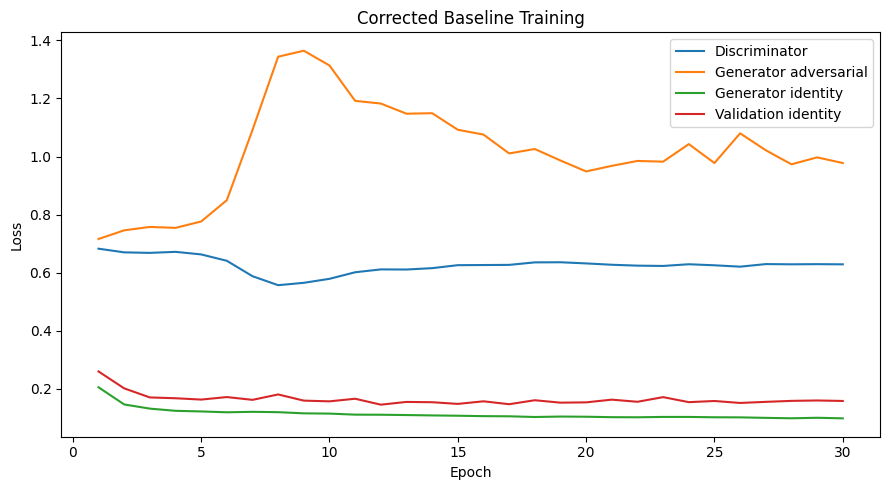


CORRECTED BASELINE SUMMARY
Best epoch: 12
Best validation identity loss: 0.144810
Overall MAE: 0.154457
Overall RMSE: 0.269570

Baseline files saved successfully.


In [ ]:
# ============================================================
# STEP 20K–20M: SAVE + EVALUATE CORRECTED BASELINE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Save models
# ------------------------------------------------------------

corrected_baseline_generator.save(
    os.path.join(
        MODEL_DIR,
        "corrected_baseline_generator.keras"
    )
)

corrected_baseline_discriminator.save(
    os.path.join(
        MODEL_DIR,
        "corrected_baseline_discriminator.keras"
    )
)

# Save history
np.save(
    os.path.join(
        RESULTS_DIR,
        "corrected_baseline_training_history.npy"
    ),
    corrected_baseline_history
)

# ------------------------------------------------------------
# 2. Generate validation samples
# ------------------------------------------------------------

corrected_baseline_val_generated = (
    corrected_baseline_generator.predict(
        X_val_input.astype(np.float32),
        batch_size=BATCH_SIZE,
        verbose=1
    )
)

print("\nGenerated validation data:")
print(
    corrected_baseline_val_generated.shape
)

print(
    "NaN:",
    np.isnan(corrected_baseline_val_generated).any()
)

print(
    "Inf:",
    np.isinf(corrected_baseline_val_generated).any()
)

# ------------------------------------------------------------
# 3. MAE / RMSE
# ------------------------------------------------------------

feature_names = [
    "SoC",
    "Battery Voltage",
    "Motor Torque",
    "Longitudinal Acceleration"
]

baseline_metrics = []

for i, feature in enumerate(feature_names):

    y_true = Y_val[:, :, i].reshape(-1)
    y_pred = corrected_baseline_val_generated[:, :, i].reshape(-1)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    baseline_metrics.append({
        "Feature": feature,
        "MAE": mae,
        "RMSE": rmse
    })

# Overall
y_true_all = Y_val.reshape(-1)
y_pred_all = corrected_baseline_val_generated.reshape(-1)

overall_mae = mean_absolute_error(
    y_true_all,
    y_pred_all
)

overall_rmse = np.sqrt(
    mean_squared_error(
        y_true_all,
        y_pred_all
    )
)

baseline_metrics.append({
    "Feature": "Overall",
    "MAE": overall_mae,
    "RMSE": overall_rmse
})

baseline_metrics_df = pd.DataFrame(
    baseline_metrics
)

print("\nCorrected baseline metrics:")
display(baseline_metrics_df)

baseline_metrics_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "corrected_baseline_metrics.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# 4. Training curves
# ------------------------------------------------------------

epochs_axis = np.arange(
    1,
    len(corrected_baseline_history["d_loss"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_axis,
    corrected_baseline_history["d_loss"],
    label="Discriminator"
)

plt.plot(
    epochs_axis,
    corrected_baseline_history["g_adv_loss"],
    label="Generator adversarial"
)

plt.plot(
    epochs_axis,
    corrected_baseline_history["g_identity_loss"],
    label="Generator identity"
)

plt.plot(
    epochs_axis,
    corrected_baseline_history["val_identity_loss"],
    label="Validation identity"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Corrected Baseline Training")

plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "corrected_baseline_training_curves.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5. Best epoch summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CORRECTED BASELINE SUMMARY")
print("=" * 60)

print(
    "Best epoch:",
    best_epoch
)

print(
    "Best validation identity loss:",
    f"{best_val_identity:.6f}"
)

print(
    "Overall MAE:",
    f"{overall_mae:.6f}"
)

print(
    "Overall RMSE:",
    f"{overall_rmse:.6f}"
)

print("\nBaseline files saved successfully.")

In [ ]:
# ============================================================
# STEP 21 - FIXED PHYSICAL-UNIT CONVERSION + PHYSICS LOSSES
# ============================================================

# ------------------------------------------------------------
# Feature indices in the ORIGINAL 14-feature scaler
# ------------------------------------------------------------

CURRENT_INPUT_INDEX = 0
VELOCITY_INPUT_INDEX = 2

SOC_OUTPUT_INDEX = 10
ACC_OUTPUT_INDEX = 13

DT = 0.1
BATTERY_CAPACITY_AH = 60.0

# ------------------------------------------------------------
# Check scaler
# ------------------------------------------------------------

print("Number of scaler features:", len(scaler.scale_))
print("Expected:", 14)

assert len(scaler.scale_) == 14
assert len(scaler.min_) == 14

# ------------------------------------------------------------
# Input/output feature indices
# ------------------------------------------------------------

# Our 10 input features correspond to original indices:
INPUT_ORIGINAL_INDICES = [
    0,   # Battery Current
    1,   # Battery Temperature
    2,   # Velocity
    3,   # Elevation
    4,   # Throttle
    5,   # Requested Heating Power
    6,   # AirCon Power
    7,   # Ambient Temperature
    8,   # Heating Power CAN
    9    # Heater Signal
]

# Our 4 output features correspond to:
OUTPUT_ORIGINAL_INDICES = [
    10,  # SoC
    11,  # Battery Voltage
    12,  # Motor Torque
    13   # Longitudinal Acceleration
]

# ------------------------------------------------------------
# NumPy inverse scaling
# ------------------------------------------------------------

def inverse_transform_input_features(X_scaled):

    X_scaled = np.asarray(X_scaled)

    scale = scaler.scale_[
        INPUT_ORIGINAL_INDICES
    ]

    offset = scaler.min_[
        INPUT_ORIGINAL_INDICES
    ]

    return (
        X_scaled - offset
    ) / scale


def inverse_transform_output_features(Y_scaled):

    Y_scaled = np.asarray(Y_scaled)

    scale = scaler.scale_[
        OUTPUT_ORIGINAL_INDICES
    ]

    offset = scaler.min_[
        OUTPUT_ORIGINAL_INDICES
    ]

    return (
        Y_scaled - offset
    ) / scale


# ------------------------------------------------------------
# Convert training data to physical units
# ------------------------------------------------------------

X_train_physical = inverse_transform_input_features(
    X_train_input
)

Y_train_physical = inverse_transform_output_features(
    Y_train
)

print("\nPhysical training input shape:",
      X_train_physical.shape)

print("Physical training output shape:",
      Y_train_physical.shape)

# ------------------------------------------------------------
# Verify selected physical ranges
# ------------------------------------------------------------

print("\nSelected physical ranges:")

print(
    "Battery Current:",
    X_train_physical[:, :, 0].min(),
    "to",
    X_train_physical[:, :, 0].max(),
    "A"
)

print(
    "Velocity:",
    X_train_physical[:, :, 2].min(),
    "to",
    X_train_physical[:, :, 2].max(),
    "km/h"
)

print(
    "SOC:",
    Y_train_physical[:, :, 0].min(),
    "to",
    Y_train_physical[:, :, 0].max(),
    "%"
)

print(
    "Acceleration:",
    Y_train_physical[:, :, 3].min(),
    "to",
    Y_train_physical[:, :, 3].max(),
    "m/s²"
)


# ============================================================
# TensorFlow inverse scaling helper
# ============================================================

def scaler_tf_inverse_feature(
    scaled_values,
    original_feature_index
):
    """
    Inverse MinMax scaling for ONE feature from
    the original 14-feature scaler.

    Works inside TensorFlow gradient calculations.
    """

    scale_value = tf.constant(
        scaler.scale_[original_feature_index],
        dtype=tf.float32
    )

    min_value = tf.constant(
        scaler.min_[original_feature_index],
        dtype=tf.float32
    )

    return (
        scaled_values - min_value
    ) / scale_value


# ============================================================
# SOC-current relationship
# ============================================================

soc_train = Y_train_physical[:, :, 0]

current_train = X_train_physical[:, :, 0]

soc_change = (
    soc_train[:, 1:]
    - soc_train[:, :-1]
)

current_for_change = (
    current_train[:, :-1]
)

soc_change_flat = soc_change.reshape(-1)
current_flat = current_for_change.reshape(-1)

valid = (
    np.isfinite(soc_change_flat)
    &
    np.isfinite(current_flat)
)

soc_change_flat = soc_change_flat[valid]
current_flat = current_flat[valid]

soc_current_corr = np.corrcoef(
    current_flat,
    soc_change_flat
)[0, 1]

print(
    "\nSOC-current correlation:",
    float(soc_current_corr)
)

if soc_current_corr < 0:

    CURRENT_SIGN = -1.0

    print(
        "Detected: increasing current is associated "
        "with decreasing SOC."
    )

else:

    CURRENT_SIGN = 1.0

    print(
        "Detected: increasing current is associated "
        "with increasing SOC."
    )


# ============================================================
# PHYSICS LOSS 1: SOC-CURRENT
# ============================================================

def soc_current_physics_loss(
    generated_soc_scaled,
    conditioning_current_scaled
):

    generated_soc_physical = (
        scaler_tf_inverse_feature(
            generated_soc_scaled,
            SOC_OUTPUT_INDEX
        )
    )

    current_physical = (
        scaler_tf_inverse_feature(
            conditioning_current_scaled,
            CURRENT_INPUT_INDEX
        )
    )

    # Generated SOC change
    delta_soc = (
        generated_soc_physical[:, 1:]
        -
        generated_soc_physical[:, :-1]
    )

    # Expected SOC change from current
    expected_delta_soc = (
        CURRENT_SIGN
        * current_physical[:, :-1]
        * DT
        /
        (BATTERY_CAPACITY_AH * 3600.0)
        * 100.0
    )

    residual = (
        delta_soc
        -
        expected_delta_soc
    )

    return tf.reduce_mean(
        tf.square(residual)
    )


# ============================================================
# PHYSICS LOSS 2: VELOCITY-ACCELERATION
# ============================================================

def velocity_acceleration_physics_loss(
    generated_acceleration_scaled,
    conditioning_velocity_scaled
):

    velocity_physical = (
        scaler_tf_inverse_feature(
            conditioning_velocity_scaled,
            VELOCITY_INPUT_INDEX
        )
    )

    acceleration_physical = (
        scaler_tf_inverse_feature(
            generated_acceleration_scaled,
            ACC_OUTPUT_INDEX
        )
    )

    # km/h → m/s
    velocity_ms = (
        velocity_physical
        * (1000.0 / 3600.0)
    )

    # Finite-difference acceleration
    expected_acceleration = (
        velocity_ms[:, 1:]
        -
        velocity_ms[:, :-1]
    ) / DT

    generated_acceleration = (
        acceleration_physical[:, 1:]
    )

    residual = (
        generated_acceleration
        -
        expected_acceleration
    )

    return tf.reduce_mean(
        tf.square(residual)
    )


# ============================================================
# PHYSICS LOSS 3: RANGE / PLAUSIBILITY
# ============================================================

def range_plausibility_loss(
    generated_output
):

    generated_soc_physical = (
        scaler_tf_inverse_feature(
            generated_output[:, :, SOC_OUTPUT_INDEX - 10],
            SOC_OUTPUT_INDEX
        )
    )

    lower_violation = tf.nn.relu(
        -generated_soc_physical
    )

    upper_violation = tf.nn.relu(
        generated_soc_physical - 100.0
    )

    return tf.reduce_mean(
        tf.square(lower_violation)
        +
        tf.square(upper_violation)
    )


print("\nPhysics-informed loss functions created successfully.")

Number of scaler features: 14
Expected: 14

Physical training input shape: (2879, 256, 10)
Physical training output shape: (2879, 256, 4)

Selected physical ranges:
Battery Current: -398.07254 to 140.347 A
Velocity: 0.0 to 152.187 km/h
SOC: 15.399998 to 88.5 %
Acceleration: -6.017 to 4.178 m/s²

SOC-current correlation: 0.542463722022344
Detected: increasing current is associated with increasing SOC.

Physics-informed loss functions created successfully.


In [ ]:
# ============================================================
# STEP 21B: TEST PHYSICS LOSSES
# ============================================================

# ------------------------------------------------------------
# Take a small batch
# ------------------------------------------------------------

physics_X = tf.convert_to_tensor(
    X_train_input[:8],
    dtype=tf.float32
)

physics_Y = tf.convert_to_tensor(
    Y_train[:8],
    dtype=tf.float32
)

# ------------------------------------------------------------
# Generate synthetic output
# ------------------------------------------------------------

physics_fake_Y = corrected_baseline_generator(
    physics_X,
    training=False
)

# ------------------------------------------------------------
# Extract required signals
# ------------------------------------------------------------

# Battery current is input feature 0
physics_current = physics_X[:, :, 0]

# Velocity is input feature 2
physics_velocity = physics_X[:, :, 2]

# Generated SOC is output feature 0
physics_generated_soc = physics_fake_Y[:, :, 0]

# Generated acceleration is output feature 3
physics_generated_acc = physics_fake_Y[:, :, 3]

# ------------------------------------------------------------
# Calculate physics losses
# ------------------------------------------------------------

test_soc_physics = soc_current_physics_loss(
    physics_generated_soc,
    physics_current
)

test_acc_physics = velocity_acceleration_physics_loss(
    physics_generated_acc,
    physics_velocity
)

test_range_loss = range_plausibility_loss(
    physics_fake_Y
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("Physics-loss test completed.\n")

print(
    "SOC-current physics loss:",
    float(test_soc_physics)
)

print(
    "Velocity-acceleration physics loss:",
    float(test_acc_physics)
)

print(
    "Range/plausibility loss:",
    float(test_range_loss)
)

# ------------------------------------------------------------
# NaN / Inf checks
# ------------------------------------------------------------

physics_losses = {
    "SOC-current": test_soc_physics,
    "Velocity-acceleration": test_acc_physics,
    "Range": test_range_loss
}

print("\nNaN / Inf checks:")

for name, value in physics_losses.items():

    invalid = (
        tf.math.is_nan(value)
        |
        tf.math.is_inf(value)
    )

    print(
        f"{name}:",
        bool(invalid)
    )

Physics-loss test completed.

SOC-current physics loss: 1.237877368927002
Velocity-acceleration physics loss: 0.060931310057640076
Range/plausibility loss: 0.0

NaN / Inf checks:
SOC-current: False
Velocity-acceleration: False
Range: False


In [ ]:
# ============================================================
# STEP 21C: RECORD PHYSICS-LOSS SANITY CHECK
# ============================================================

physics_sanity_check = pd.DataFrame({
    "Physics_Loss": [
        "SOC-current",
        "Velocity-acceleration",
        "Range-plausibility"
    ],
    "Value": [
        float(test_soc_physics),
        float(test_acc_physics),
        float(test_range_loss)
    ]
})

display(physics_sanity_check)

physics_sanity_check.to_csv(
    os.path.join(
        RESULTS_DIR,
        "physics_loss_sanity_check.csv"
    ),
    index=False
)

print("Physics sanity-check results saved.")

,Physics_Loss,Value
0,SOC-current,1.237877
1,Velocity-acceleration,0.060931
2,Range-plausibility,0.000000


Physics sanity-check results saved.


In [ ]:
# ============================================================
# STEP 22A
# RE-PI-CycleEV CONDITIONAL GENERATOR + DISCRIMINATOR
# ============================================================

from tensorflow.keras import layers, Model

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

WINDOW_SIZE = 256
N_INPUT_FEATURES = 10
N_OUTPUT_FEATURES = 4
N_EVENT_FEATURES = 5

# ============================================================
# 1. CONDITIONAL GENERATOR
# ============================================================

repi_input = layers.Input(
    shape=(WINDOW_SIZE, N_INPUT_FEATURES),
    name="repi_input_sequence"
)

repi_condition = layers.Input(
    shape=(N_EVENT_FEATURES,),
    name="repi_event_condition"
)

# Broadcast event condition across time
condition_sequence = layers.RepeatVector(
    WINDOW_SIZE
)(repi_condition)

# Combine physical inputs + event condition
repi_combined = layers.Concatenate(
    axis=-1,
    name="conditional_input"
)([
    repi_input,
    condition_sequence
])

# ------------------------------------------------------------
# Feature extraction
# ------------------------------------------------------------

x = layers.Conv1D(
    64,
    kernel_size=5,
    padding="same",
    activation="relu"
)(repi_combined)

x = layers.BatchNormalization()(x)

x = layers.Conv1D(
    128,
    kernel_size=5,
    padding="same",
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Bidirectional(
    layers.LSTM(
        64,
        return_sequences=True
    )
)(x)

x = layers.Dropout(0.2)(x)

# ------------------------------------------------------------
# Generated target sequence
# ------------------------------------------------------------

repi_output = layers.TimeDistributed(
    layers.Dense(
        N_OUTPUT_FEATURES,
        activation="tanh"
    ),
    name="generated_sequence"
)(x)

repi_generator = Model(
    [
        repi_input,
        repi_condition
    ],
    repi_output,
    name="RE_PI_CycleEV_Generator"
)


# ============================================================
# 2. CONDITIONAL DISCRIMINATOR
# ============================================================

disc_input = layers.Input(
    shape=(WINDOW_SIZE, N_INPUT_FEATURES),
    name="repi_disc_input"
)

disc_target = layers.Input(
    shape=(WINDOW_SIZE, N_OUTPUT_FEATURES),
    name="repi_disc_target"
)

disc_condition = layers.Input(
    shape=(N_EVENT_FEATURES,),
    name="repi_disc_condition"
)

# Broadcast event condition
disc_condition_sequence = layers.RepeatVector(
    WINDOW_SIZE
)(disc_condition)

# Combine everything
disc_combined = layers.Concatenate(
    axis=-1,
    name="repi_disc_combined"
)([
    disc_input,
    disc_target,
    disc_condition_sequence
])

# ------------------------------------------------------------
# Temporal discriminator
# ------------------------------------------------------------

d = layers.Conv1D(
    64,
    kernel_size=5,
    strides=2,
    padding="same"
)(disc_combined)

d = layers.LeakyReLU(
    negative_slope=0.2
)(d)

d = layers.Dropout(0.3)(d)

d = layers.Conv1D(
    128,
    kernel_size=5,
    strides=2,
    padding="same"
)(d)

d = layers.LeakyReLU(
    negative_slope=0.2
)(d)

d = layers.Dropout(0.3)(d)

d = layers.Conv1D(
    256,
    kernel_size=5,
    strides=2,
    padding="same"
)(d)

d = layers.LeakyReLU(
    negative_slope=0.2
)(d)

d = layers.GlobalAveragePooling1D()(d)

# ------------------------------------------------------------
# Real / fake output
# ------------------------------------------------------------

real_fake_output = layers.Dense(
    1,
    activation="sigmoid",
    name="real_fake"
)(d)

# ------------------------------------------------------------
# Event classification output
# ------------------------------------------------------------

event_output = layers.Dense(
    N_EVENT_FEATURES,
    activation="sigmoid",
    name="event_classifier"
)(d)

# ------------------------------------------------------------
# Create discriminator
# ------------------------------------------------------------

repi_discriminator = Model(
    [
        disc_input,
        disc_target,
        disc_condition
    ],
    [
        real_fake_output,
        event_output
    ],
    name="RE_PI_CycleEV_Discriminator"
)


# ============================================================
# 3. DISPLAY MODELS
# ============================================================

print("=" * 70)
print("RE-PI-CycleEV GENERATOR")
print("=" * 70)

repi_generator.summary()

print("\n" + "=" * 70)
print("RE-PI-CycleEV DISCRIMINATOR")
print("=" * 70)

repi_discriminator.summary()

RE-PI-CycleEV GENERATOR


Model: "RE_PI_CycleEV_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ repi_event_conditi… │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repi_input_sequence │ (None, 256, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 256, 5)    │          0 │ repi_event_condi… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conditional_input   │ (None, 256, 15)   │          0 │ repi_input_seque… │
│ (Concatenate)       │                   │            │ repeat_vector_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, 256, 64)   │      4,864 │ conditional_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 64)   │        256 │ conv1d_36[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 256, 128)  │     41,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 128)  │        512 │ conv1d_37[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 256, 128)  │     98,816 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256, 128)  │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generated_sequence  │ (None, 256, 4)    │        516 │ dropout_4[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 146,052 (570.52 KB)

 Trainable params: 145,668 (569.02 KB)

...

Model: "RE_PI_CycleEV_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ repi_disc_condition │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repi_disc_input     │ (None, 256, 10)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repi_disc_target    │ (None, 256, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 256, 5)    │          0 │ repi_disc_condit… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repi_disc_combined  │ (None, 256, 19)   │          0 │ repi_disc_input[… │
│ (Concatenate)       │                   │            │ repi_disc_target… │
│                     │                   │            │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 128, 64)   │      6,144 │ repi_disc_combin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_6       │ (None, 128, 64)   │          0 │ conv1d_38[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128, 64)   │          0 │ leaky_re_lu_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 64, 128)   │     41,088 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_7       │ (None, 64, 128)   │          0 │ conv1d_39[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64, 128)   │          0 │ leaky_re_lu_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 32, 256)   │    164,096 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_8       │ (None, 32, 256)   │          0 │ conv1d_40[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ leaky_re_lu_8[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ real_fake (Dense)   │ (None, 1)         │        257 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ event_classifier    │ (None, 5)         │      1,285 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 212,870 (831.52 KB)

 Trainable params: 212,870 (831.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# STEP 22B
# RE-PI-CycleEV: RARITY-AWARE SAMPLING + LOSSES + OPTIMIZERS
# ============================================================

# ============================================================
# 1. EVENT FREQUENCY / RARITY WEIGHTS
# ============================================================

event_names = [
    "Low_SOC",
    "High_Current",
    "Aggressive_Accel_Braking",
    "Heating_Stress",
    "Stop_and_Go"
]

# Number of positive windows for each event
event_counts = np.sum(
    C_train,
    axis=0
).astype(np.int64)

total_windows = len(C_train)

event_frequencies = (
    event_counts / total_windows
)

print("=" * 70)
print("TRAINING EVENT FREQUENCIES")
print("=" * 70)

for name, count, freq in zip(
    event_names,
    event_counts,
    event_frequencies
):
    print(
        f"{name:30s} "
        f"count={count:4d} "
        f"frequency={freq:.4f}"
    )


# ============================================================
# 2. RARITY-AWARE WINDOW WEIGHTS
# ============================================================

# Inverse-frequency event weights
inverse_frequency = (
    total_windows /
    np.maximum(event_counts, 1)
)

# Normalize event weights around 1
inverse_frequency = (
    inverse_frequency /
    np.mean(inverse_frequency)
)

# Cap extreme weights to prevent unstable training
MAX_EVENT_WEIGHT = 4.0

inverse_frequency = np.minimum(
    inverse_frequency,
    MAX_EVENT_WEIGHT
)

print("\nCapped inverse-frequency weights:")

for name, weight in zip(
    event_names,
    inverse_frequency
):
    print(
        f"{name:30s} {weight:.4f}"
    )


# ------------------------------------------------------------
# Window-level sampling weight
# ------------------------------------------------------------

# Start with a small base probability
window_weights = np.ones(
    total_windows,
    dtype=np.float64
)

# Add contribution from every active rare event
for j in range(N_EVENT_FEATURES):

    active = C_train[:, j].astype(bool)

    window_weights[active] += (
        inverse_frequency[j] - 1.0
    )

# Give multi-stress windows additional influence
multi_stress_mask = (
    np.sum(C_train, axis=1) >= 2
)

window_weights[multi_stress_mask] *= 1.25

# Prevent zero/negative values
window_weights = np.maximum(
    window_weights,
    0.01
)

# Normalize to probability
sampling_probabilities = (
    window_weights /
    window_weights.sum()
)

print("\nSampling probability check:")
print(
    "Minimum:",
    sampling_probabilities.min()
)
print(
    "Maximum:",
    sampling_probabilities.max()
)
print(
    "Sum:",
    sampling_probabilities.sum()
)


# ============================================================
# 3. EVENT-CONSISTENCY LOSS
# ============================================================

event_bce = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)


def event_consistency_loss(
    requested_condition,
    predicted_event
):
    """
    Multi-label binary cross-entropy between
    requested event code and predicted events.
    """

    return event_bce(
        requested_condition,
        predicted_event
    )


# ============================================================
# 4. ADVERSARIAL LOSS
# ============================================================

repi_bce = tf.keras.losses.BinaryCrossentropy(
    from_logits=False
)


def repi_discriminator_loss(
    real_prediction,
    fake_prediction
):

    real_labels = tf.ones_like(
        real_prediction
    )

    fake_labels = tf.zeros_like(
        fake_prediction
    )

    real_loss = repi_bce(
        real_labels,
        real_prediction
    )

    fake_loss = repi_bce(
        fake_labels,
        fake_prediction
    )

    return 0.5 * (
        real_loss +
        fake_loss
    )


def repi_generator_adversarial_loss(
    fake_prediction
):

    real_labels = tf.ones_like(
        fake_prediction
    )

    return repi_bce(
        real_labels,
        fake_prediction
    )


# ============================================================
# 5. IDENTITY / RECONSTRUCTION LOSS
# ============================================================

def repi_identity_loss(
    real_target,
    generated_target
):

    return tf.reduce_mean(
        tf.abs(
            real_target -
            generated_target
        )
    )


# ============================================================
# 6. LOSS WEIGHTS
# ============================================================

LAMBDA_REPI_IDENTITY = 10.0

LAMBDA_REPI_SOC = 0.10

LAMBDA_REPI_ACCEL = 0.10

LAMBDA_REPI_RANGE = 0.10

LAMBDA_REPI_EVENT = 2.0


print("\n" + "=" * 70)
print("RE-PI-CycleEV LOSS WEIGHTS")
print("=" * 70)

print(
    "Identity:",
    LAMBDA_REPI_IDENTITY
)

print(
    "SOC-current physics:",
    LAMBDA_REPI_SOC
)

print(
    "Velocity-acceleration physics:",
    LAMBDA_REPI_ACCEL
)

print(
    "Range/plausibility:",
    LAMBDA_REPI_RANGE
)

print(
    "Event consistency:",
    LAMBDA_REPI_EVENT
)


# ============================================================
# 7. OPTIMIZERS
# ============================================================

repi_generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5,
    beta_2=0.999
)

repi_discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=2e-4,
    beta_1=0.5,
    beta_2=0.999
)


# ============================================================
# 8. SAVE EVENT STATISTICS
# ============================================================

event_statistics_df = pd.DataFrame({
    "Event": event_names,
    "Count": event_counts,
    "Frequency": event_frequencies,
    "Inverse_Frequency_Weight": inverse_frequency
})

display(event_statistics_df)

event_statistics_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "event_statistics_training.csv"
    ),
    index=False
)

print(
    "\nRE-PI-CycleEV training setup created successfully."
)

TRAINING EVENT FREQUENCIES
Low_SOC                        count= 288 frequency=0.1000
High_Current                   count= 144 frequency=0.0500
Aggressive_Accel_Braking       count= 144 frequency=0.0500
Heating_Stress                 count= 144 frequency=0.0500
Stop_and_Go                    count= 304 frequency=0.1056

Capped inverse-frequency weights:
Low_SOC                        0.6291
High_Current                   1.2583
Aggressive_Accel_Braking       1.2583
Heating_Stress                 1.2583
Stop_and_Go                    0.5960

Sampling probability check:
Minimum: 0.00010046473805887935
Maximum: 0.0007918985235229319
Sum: 1.0

RE-PI-CycleEV LOSS WEIGHTS
Identity: 10.0
SOC-current physics: 0.1
Velocity-acceleration physics: 0.1
Range/plausibility: 0.1
Event consistency: 2.0


,Event,Count,Frequency,Inverse_Frequency_Weight
0,Low_SOC,288,0.100035,0.629139
1,High_Current,144,0.050017,1.258278
2,Aggressive_Accel_Braking,144,0.050017,1.258278
3,Heating_Stress,144,0.050017,1.258278
4,Stop_and_Go,304,0.105592,0.596026



RE-PI-CycleEV training setup created successfully.


In [ ]:
# ============================================================
# STEP 22C
# COMPLETE RE-PI-CycleEV TRAINING STEP
# ============================================================

@tf.function
def repi_train_step(
    input_sequence,
    real_target,
    event_condition
):

    # ========================================================
    # 1. TRAIN DISCRIMINATOR
    # ========================================================

    with tf.GradientTape() as disc_tape:

        # Generate synthetic target
        fake_target = repi_generator(
            [
                input_sequence,
                event_condition
            ],
            training=True
        )

        # Real sample prediction
        real_prediction, real_event_prediction = (
            repi_discriminator(
                [
                    input_sequence,
                    real_target,
                    event_condition
                ],
                training=True
            )
        )

        # Fake sample prediction
        fake_prediction, fake_event_prediction = (
            repi_discriminator(
                [
                    input_sequence,
                    fake_target,
                    event_condition
                ],
                training=True
            )
        )

        # ----------------------------------------------------
        # Adversarial discriminator loss
        # ----------------------------------------------------

        d_adv_loss = repi_discriminator_loss(
            real_prediction,
            fake_prediction
        )

        # ----------------------------------------------------
        # Event classification on REAL data
        # ----------------------------------------------------

        d_real_event_loss = event_consistency_loss(
            event_condition,
            real_event_prediction
        )

        # ----------------------------------------------------
        # Event classification on FAKE data
        # ----------------------------------------------------

        d_fake_event_loss = event_consistency_loss(
            event_condition,
            fake_event_prediction
        )

        # Combined discriminator loss
        d_total_loss = (
            d_adv_loss
            +
            LAMBDA_REPI_EVENT
            * 0.5
            * (
                d_real_event_loss
                +
                d_fake_event_loss
            )
        )

    # --------------------------------------------------------
    # Apply discriminator gradients
    # --------------------------------------------------------

    disc_gradients = disc_tape.gradient(
        d_total_loss,
        repi_discriminator.trainable_variables
    )

    repi_discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            repi_discriminator.trainable_variables
        )
    )


    # ========================================================
    # 2. TRAIN GENERATOR
    # ========================================================

    with tf.GradientTape() as gen_tape:

        # Generate synthetic target
        fake_target = repi_generator(
            [
                input_sequence,
                event_condition
            ],
            training=True
        )

        # Discriminator predictions
        fake_prediction, fake_event_prediction = (
            repi_discriminator(
                [
                    input_sequence,
                    fake_target,
                    event_condition
                ],
                training=True
            )
        )

        # ----------------------------------------------------
        # Adversarial generator loss
        # ----------------------------------------------------

        g_adv_loss = repi_generator_adversarial_loss(
            fake_prediction
        )

        # ----------------------------------------------------
        # Identity / reconstruction loss
        # ----------------------------------------------------

        g_identity_loss = repi_identity_loss(
            real_target,
            fake_target
        )

        # ----------------------------------------------------
        # SOC-current physics
        # ----------------------------------------------------

        g_soc_physics_loss = (
            soc_current_physics_loss(
                fake_target[:, :, SOC_OUTPUT_INDEX - 10],
                input_sequence[:, :, CURRENT_INPUT_INDEX]
            )
        )

        # ----------------------------------------------------
        # Velocity-acceleration physics
        # ----------------------------------------------------

        g_acc_physics_loss = (
            velocity_acceleration_physics_loss(
                fake_target[:, :, ACC_OUTPUT_INDEX - 10],
                input_sequence[:, :, VELOCITY_INPUT_INDEX]
            )
        )

        # ----------------------------------------------------
        # Range / plausibility
        # ----------------------------------------------------

        g_range_loss = (
            range_plausibility_loss(
                fake_target
            )
        )

        # ----------------------------------------------------
        # Event consistency
        # ----------------------------------------------------

        g_event_loss = event_consistency_loss(
            event_condition,
            fake_event_prediction
        )

        # ----------------------------------------------------
        # TOTAL GENERATOR LOSS
        # ----------------------------------------------------

        g_total_loss = (

            g_adv_loss

            +

            LAMBDA_REPI_IDENTITY
            * g_identity_loss

            +

            LAMBDA_REPI_SOC
            * g_soc_physics_loss

            +

            LAMBDA_REPI_ACCEL
            * g_acc_physics_loss

            +

            LAMBDA_REPI_RANGE
            * g_range_loss

            +

            LAMBDA_REPI_EVENT
            * g_event_loss
        )

    # --------------------------------------------------------
    # Apply generator gradients
    # --------------------------------------------------------

    gen_gradients = gen_tape.gradient(
        g_total_loss,
        repi_generator.trainable_variables
    )

    repi_generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            repi_generator.trainable_variables
        )
    )


    # ========================================================
    # RETURN ALL DIAGNOSTICS
    # ========================================================

    return {

        "d_adv": d_adv_loss,

        "d_event": (
            0.5
            * (
                d_real_event_loss
                +
                d_fake_event_loss
            )
        ),

        "d_total": d_total_loss,

        "g_adv": g_adv_loss,

        "g_identity": g_identity_loss,

        "g_soc_physics": g_soc_physics_loss,

        "g_acc_physics": g_acc_physics_loss,

        "g_range": g_range_loss,

        "g_event": g_event_loss,

        "g_total": g_total_loss
    }


print(
    "Complete RE-PI-CycleEV training step created successfully."
)

Complete RE-PI-CycleEV training step created successfully.


In [ ]:
# ============================================================
# STEP 22D: SINGLE RE-PI TRAINING-STEP TEST
# ============================================================

# ------------------------------------------------------------
# Small test batch
# ------------------------------------------------------------

repi_X_test = tf.convert_to_tensor(
    X_train_input[:8],
    dtype=tf.float32
)

repi_Y_test = tf.convert_to_tensor(
    Y_train[:8],
    dtype=tf.float32
)

repi_C_test = tf.convert_to_tensor(
    C_train[:8],
    dtype=tf.float32
)

# ------------------------------------------------------------
# Run one complete RE-PI training step
# ------------------------------------------------------------

repi_test_losses = repi_train_step(
    repi_X_test,
    repi_Y_test,
    repi_C_test
)

# ------------------------------------------------------------
# Display losses
# ------------------------------------------------------------

print("RE-PI single training step completed.\n")

for name, value in repi_test_losses.items():

    print(
        f"{name:20s}: {float(value):.6f}"
    )

# ------------------------------------------------------------
# NaN / Inf check
# ------------------------------------------------------------

print("\nNaN / Inf checks:")

for name, value in repi_test_losses.items():

    invalid = (
        tf.math.is_nan(value)
        |
        tf.math.is_inf(value)
    )

    print(
        f"{name:20s}: {bool(invalid)}"
    )

RE-PI single training step completed.

d_adv               : 0.692532
d_event             : 0.685351
d_total             : 2.063233
g_adv               : 0.593481
g_identity          : 0.578412
g_soc_physics       : 121.459160
g_acc_physics       : 4.518507
g_range             : 0.000000
g_event             : 0.653794
g_total             : 20.282951

NaN / Inf checks:
d_adv               : False
d_event             : False
d_total             : False
g_adv               : False
g_identity          : False
g_soc_physics       : False
g_acc_physics       : False
g_range             : False
g_event             : False
g_total             : False


In [ ]:
# ============================================================
# STEP 22E: PHYSICS LOSS CONTRIBUTION CHECK
# ============================================================

print("=" * 65)
print("RE-PI-CycleEV LOSS CONTRIBUTIONS")
print("=" * 65)

loss_values = {
    "Adversarial": float(repi_test_losses["g_adv"]),
    "Identity": float(
        LAMBDA_REPI_IDENTITY *
        repi_test_losses["g_identity"]
    ),
    "SOC-current physics": float(
        LAMBDA_REPI_SOC *
        repi_test_losses["g_soc_physics"]
    ),
    "Velocity-acceleration physics": float(
        LAMBDA_REPI_ACCEL *
        repi_test_losses["g_acc_physics"]
    ),
    "Range/plausibility": float(
        LAMBDA_REPI_RANGE *
        repi_test_losses["g_range"]
    ),
    "Event consistency": float(
        LAMBDA_REPI_EVENT *
        repi_test_losses["g_event"]
    )
}

for name, value in loss_values.items():
    print(f"{name:35s}: {value:.6f}")

print("=" * 65)

print(
    "\nTotal generator loss:",
    float(repi_test_losses["g_total"])
)

RE-PI-CycleEV LOSS CONTRIBUTIONS
Adversarial                        : 0.593481
Identity                           : 5.784117
SOC-current physics                : 12.145916
Velocity-acceleration physics      : 0.451851
Range/plausibility                 : 0.000000
Event consistency                  : 1.307588

Total generator loss: 20.28295135498047


In [ ]:
# ============================================================
# STEP 22F: BALANCE RE-PI PHYSICS LOSS WEIGHTS
# ============================================================

LAMBDA_REPI_IDENTITY = 10.0

# Reduce dominance of the initially large SOC residual
LAMBDA_REPI_SOC = 0.02

# Keep acceleration physics active
LAMBDA_REPI_ACCEL = 0.10

# Keep plausibility constraint active
LAMBDA_REPI_RANGE = 0.10

# Event control remains important
LAMBDA_REPI_EVENT = 2.0

print("=" * 65)
print("UPDATED RE-PI-CycleEV LOSS WEIGHTS")
print("=" * 65)

print(f"Identity:                         {LAMBDA_REPI_IDENTITY}")
print(f"SOC-current physics:              {LAMBDA_REPI_SOC}")
print(f"Velocity-acceleration physics:    {LAMBDA_REPI_ACCEL}")
print(f"Range/plausibility:               {LAMBDA_REPI_RANGE}")
print(f"Event consistency:                {LAMBDA_REPI_EVENT}")
print("=" * 65)

UPDATED RE-PI-CycleEV LOSS WEIGHTS
Identity:                         10.0
SOC-current physics:              0.02
Velocity-acceleration physics:    0.1
Range/plausibility:               0.1
Event consistency:                2.0


In [ ]:
# ============================================================
# STEP 22H
# FIX MODEL PATH + START RE-PI-CycleEV TRAINING
# ============================================================

# ------------------------------------------------------------
# Make sure result/model directories exist
# ------------------------------------------------------------

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

MODELS_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)


# ------------------------------------------------------------
# Model paths
# ------------------------------------------------------------

BEST_GENERATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_best_generator.keras"
)

BEST_DISCRIMINATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_best_discriminator.keras"
)

FINAL_GENERATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_final_generator.keras"
)

FINAL_DISCRIMINATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_final_discriminator.keras"
)


# ============================================================
# BEST MODEL TRACKING
# ============================================================

best_val_total = np.inf
best_epoch = None


# ============================================================
# TRAINING LOOP
# ============================================================

steps_per_epoch = int(
    np.ceil(N_TRAIN / BATCH_SIZE)
)

print("=" * 70)
print("STARTING RE-PI-CycleEV TRAINING")
print("=" * 70)

training_start = time.time()


for epoch in range(1, REPI_EPOCHS + 1):

    epoch_start = time.time()

    epoch_losses = {
        "d_adv": [],
        "d_event": [],
        "d_total": [],

        "g_adv": [],
        "g_identity": [],
        "g_soc_physics": [],
        "g_acc_physics": [],
        "g_range": [],
        "g_event": [],
        "g_total": []
    }


    # --------------------------------------------------------
    # TRAINING BATCHES
    # --------------------------------------------------------

    for step in range(steps_per_epoch):

        batch_X, batch_Y, batch_C = sample_training_batch(
            BATCH_SIZE
        )

        batch_X = tf.convert_to_tensor(
            batch_X,
            dtype=tf.float32
        )

        batch_Y = tf.convert_to_tensor(
            batch_Y,
            dtype=tf.float32
        )

        batch_C = tf.convert_to_tensor(
            batch_C,
            dtype=tf.float32
        )

        batch_losses = repi_train_step(
            batch_X,
            batch_Y,
            batch_C
        )

        for key in epoch_losses:

            epoch_losses[key].append(
                float(batch_losses[key])
            )


    # --------------------------------------------------------
    # MEAN TRAINING LOSSES
    # --------------------------------------------------------

    epoch_mean_losses = {
        key: np.mean(values)
        for key, values in epoch_losses.items()
    }


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    (
        val_identity,
        val_event,
        val_soc,
        val_acc,
        val_range,
        val_total
    ) = evaluate_repi_validation()


    # --------------------------------------------------------
    # STORE HISTORY
    # --------------------------------------------------------

    history["epoch"].append(epoch)

    for key in [
        "d_adv",
        "d_event",
        "d_total",
        "g_adv",
        "g_identity",
        "g_soc_physics",
        "g_acc_physics",
        "g_range",
        "g_event",
        "g_total"
    ]:

        history[key].append(
            epoch_mean_losses[key]
        )


    history["val_identity"].append(
        val_identity
    )

    history["val_event"].append(
        val_event
    )

    history["val_soc_physics"].append(
        val_soc
    )

    history["val_acc_physics"].append(
        val_acc
    )

    history["val_range"].append(
        val_range
    )

    history["val_total"].append(
        val_total
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_total < best_val_total:

        best_val_total = val_total
        best_epoch = epoch

        repi_generator.save(
            BEST_GENERATOR_PATH,
            overwrite=True
        )

        repi_discriminator.save(
            BEST_DISCRIMINATOR_PATH,
            overwrite=True
        )

        best_marker = " <-- BEST"

    else:

        best_marker = ""


    # --------------------------------------------------------
    # PRINT EPOCH
    # --------------------------------------------------------

    elapsed = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{REPI_EPOCHS} | "
        f"D={epoch_mean_losses['d_total']:.4f} | "
        f"G={epoch_mean_losses['g_total']:.4f} | "
        f"ID={epoch_mean_losses['g_identity']:.4f} | "
        f"SOC={epoch_mean_losses['g_soc_physics']:.4f} | "
        f"ACC={epoch_mean_losses['g_acc_physics']:.4f} | "
        f"EVENT={epoch_mean_losses['g_event']:.4f} | "
        f"Val={val_total:.4f} | "
        f"{elapsed:.1f}s"
        f"{best_marker}"
    )


# ============================================================
# SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_path = os.path.join(
    RESULTS_DIR,
    "RE_PI_CycleEV_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)


# ============================================================
# SAVE FINAL MODELS
# ============================================================

repi_generator.save(
    FINAL_GENERATOR_PATH,
    overwrite=True
)

repi_discriminator.save(
    FINAL_DISCRIMINATOR_PATH,
    overwrite=True
)


# ============================================================
# FINAL SUMMARY
# ============================================================

total_training_time = (
    time.time() - training_start
)

print("\n" + "=" * 70)
print("RE-PI-CycleEV TRAINING COMPLETED")
print("=" * 70)

print(f"Best epoch      : {best_epoch}")
print(f"Best validation : {best_val_total:.6f}")
print(
    f"Training time   : "
    f"{total_training_time / 60:.2f} minutes"
)

print(f"\nHistory:\n{history_path}")
print(f"\nBest generator:\n{BEST_GENERATOR_PATH}")
print(f"\nBest discriminator:\n{BEST_DISCRIMINATOR_PATH}")

print("=" * 70)

STARTING RE-PI-CycleEV TRAINING


NameError: name 'evaluate_repi_validation' is not defined

In [ ]:
# ============================================================
# STEP 22I
# RESTORE RE-PI VALIDATION FUNCTION
# ============================================================

def evaluate_repi_validation():

    val_identity_values = []
    val_event_values = []
    val_soc_values = []
    val_acc_values = []
    val_range_values = []
    val_total_values = []

    for batch_X, batch_Y, batch_C in val_dataset:

        # ----------------------------------------------------
        # Generate validation sequence
        # ----------------------------------------------------

        generated_Y = repi_generator(
            [
                batch_X,
                batch_C
            ],
            training=False
        )

        # ----------------------------------------------------
        # Event prediction
        # ----------------------------------------------------

        _, predicted_events = repi_discriminator(
            [
                batch_X,
                generated_Y,
                batch_C
            ],
            training=False
        )

        # ----------------------------------------------------
        # Identity loss
        # ----------------------------------------------------

        identity_loss = repi_identity_loss(
            batch_Y,
            generated_Y
        )

        # ----------------------------------------------------
        # Event consistency
        # ----------------------------------------------------

        event_loss = event_consistency_loss(
            batch_C,
            predicted_events
        )

        # ----------------------------------------------------
        # SOC-current physics
        # ----------------------------------------------------

        soc_loss = soc_current_physics_loss(
            generated_Y[:, :, SOC_OUTPUT_INDEX - 10],
            batch_X[:, :, CURRENT_INPUT_INDEX]
        )

        # ----------------------------------------------------
        # Velocity-acceleration physics
        # ----------------------------------------------------

        acc_loss = velocity_acceleration_physics_loss(
            generated_Y[:, :, ACC_OUTPUT_INDEX - 10],
            batch_X[:, :, VELOCITY_INPUT_INDEX]
        )

        # ----------------------------------------------------
        # Range/plausibility
        # ----------------------------------------------------

        range_loss = range_plausibility_loss(
            generated_Y
        )

        # ----------------------------------------------------
        # Total validation objective
        # ----------------------------------------------------

        total_loss = (

            LAMBDA_REPI_IDENTITY
            * identity_loss

            +

            LAMBDA_REPI_SOC
            * soc_loss

            +

            LAMBDA_REPI_ACCEL
            * acc_loss

            +

            LAMBDA_REPI_RANGE
            * range_loss

            +

            LAMBDA_REPI_EVENT
            * event_loss
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        val_identity_values.append(
            float(identity_loss)
        )

        val_event_values.append(
            float(event_loss)
        )

        val_soc_values.append(
            float(soc_loss)
        )

        val_acc_values.append(
            float(acc_loss)
        )

        val_range_values.append(
            float(range_loss)
        )

        val_total_values.append(
            float(total_loss)
        )

    return (
        np.mean(val_identity_values),
        np.mean(val_event_values),
        np.mean(val_soc_values),
        np.mean(val_acc_values),
        np.mean(val_range_values),
        np.mean(val_total_values)
    )


print(
    "RE-PI validation function restored successfully."
)

RE-PI validation function restored successfully.


In [ ]:
# ============================================================
# VALIDATION FUNCTION CHECK
# ============================================================

(
    test_val_identity,
    test_val_event,
    test_val_soc,
    test_val_acc,
    test_val_range,
    test_val_total
) = evaluate_repi_validation()

print("=" * 65)
print("VALIDATION FUNCTION CHECK")
print("=" * 65)

print(f"Identity loss             : {test_val_identity:.6f}")
print(f"Event loss                : {test_val_event:.6f}")
print(f"SOC physics loss          : {test_val_soc:.6f}")
print(f"Acceleration physics loss : {test_val_acc:.6f}")
print(f"Range loss                : {test_val_range:.6f}")
print(f"Total validation loss     : {test_val_total:.6f}")

print("=" * 65)

VALIDATION FUNCTION CHECK
Identity loss             : 0.170938
Event loss                : 0.033800
SOC physics loss          : 0.143440
Acceleration physics loss : 0.671465
Range loss                : 0.000000
Total validation loss     : 1.847000


In [ ]:
# ============================================================
# STEP 22J
# SELF-CONTAINED RE-PI-CycleEV TRAINING
# ============================================================

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

# ============================================================
# CONFIGURATION
# ============================================================

BATCH_SIZE = 32
REPI_EPOCHS = 30

N_TRAIN = len(X_train_input)
N_VAL = len(X_val_input)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

MODELS_DIR = os.path.join(
    PROJECT_DIR,
    "models"
)

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("=" * 70)
print("RE-PI-CycleEV FINAL TRAINING")
print("=" * 70)

print(f"Training windows  : {N_TRAIN}")
print(f"Validation windows: {N_VAL}")
print(f"Batch size        : {BATCH_SIZE}")
print(f"Epochs            : {REPI_EPOCHS}")


# ============================================================
# MODEL PATHS
# ============================================================

BEST_GENERATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_best_generator.keras"
)

BEST_DISCRIMINATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_best_discriminator.keras"
)

FINAL_GENERATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_final_generator.keras"
)

FINAL_DISCRIMINATOR_PATH = os.path.join(
    MODELS_DIR,
    "RE_PI_CycleEV_final_discriminator.keras"
)


# ============================================================
# RARITY-AWARE BATCH SAMPLER
# ============================================================

def sample_training_batch(batch_size):

    indices = np.random.choice(
        N_TRAIN,
        size=batch_size,
        replace=True,
        p=sampling_probabilities
    )

    batch_X = X_train_input[indices].astype(np.float32)
    batch_Y = Y_train[indices].astype(np.float32)
    batch_C = C_train[indices].astype(np.float32)

    return batch_X, batch_Y, batch_C


# ============================================================
# VALIDATION DATASET
# ============================================================

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_val_input.astype(np.float32),
        Y_val.astype(np.float32),
        C_val.astype(np.float32)
    )
).batch(
    BATCH_SIZE
).prefetch(
    tf.data.AUTOTUNE
)


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def evaluate_repi_validation():

    val_identity_values = []
    val_event_values = []
    val_soc_values = []
    val_acc_values = []
    val_range_values = []
    val_total_values = []

    for batch_X, batch_Y, batch_C in val_dataset:

        generated_Y = repi_generator(
            [
                batch_X,
                batch_C
            ],
            training=False
        )

        _, predicted_events = repi_discriminator(
            [
                batch_X,
                generated_Y,
                batch_C
            ],
            training=False
        )

        identity_loss = repi_identity_loss(
            batch_Y,
            generated_Y
        )

        event_loss = event_consistency_loss(
            batch_C,
            predicted_events
        )

        soc_loss = soc_current_physics_loss(
            generated_Y[:, :, SOC_OUTPUT_INDEX - 10],
            batch_X[:, :, CURRENT_INPUT_INDEX]
        )

        acc_loss = velocity_acceleration_physics_loss(
            generated_Y[:, :, ACC_OUTPUT_INDEX - 10],
            batch_X[:, :, VELOCITY_INPUT_INDEX]
        )

        range_loss = range_plausibility_loss(
            generated_Y
        )

        total_loss = (
            LAMBDA_REPI_IDENTITY * identity_loss
            +
            LAMBDA_REPI_SOC * soc_loss
            +
            LAMBDA_REPI_ACCEL * acc_loss
            +
            LAMBDA_REPI_RANGE * range_loss
            +
            LAMBDA_REPI_EVENT * event_loss
        )

        val_identity_values.append(
            float(identity_loss)
        )

        val_event_values.append(
            float(event_loss)
        )

        val_soc_values.append(
            float(soc_loss)
        )

        val_acc_values.append(
            float(acc_loss)
        )

        val_range_values.append(
            float(range_loss)
        )

        val_total_values.append(
            float(total_loss)
        )

    return (
        np.mean(val_identity_values),
        np.mean(val_event_values),
        np.mean(val_soc_values),
        np.mean(val_acc_values),
        np.mean(val_range_values),
        np.mean(val_total_values)
    )


# ============================================================
# TRAINING HISTORY
# ============================================================

history = {
    "epoch": [],

    "d_adv": [],
    "d_event": [],
    "d_total": [],

    "g_adv": [],
    "g_identity": [],
    "g_soc_physics": [],
    "g_acc_physics": [],
    "g_range": [],
    "g_event": [],
    "g_total": [],

    "val_identity": [],
    "val_event": [],
    "val_soc_physics": [],
    "val_acc_physics": [],
    "val_range": [],
    "val_total": []
}


# ============================================================
# BEST MODEL TRACKING
# ============================================================

best_val_total = np.inf
best_epoch = None

steps_per_epoch = int(
    np.ceil(N_TRAIN / BATCH_SIZE)
)

print("\nSteps per epoch:", steps_per_epoch)

print("\n" + "=" * 70)
print("STARTING 30-EPOCH TRAINING")
print("=" * 70)


# ============================================================
# TRAINING START
# ============================================================

training_start = time.time()


for epoch in range(1, REPI_EPOCHS + 1):

    epoch_start = time.time()

    epoch_losses = {
        "d_adv": [],
        "d_event": [],
        "d_total": [],

        "g_adv": [],
        "g_identity": [],
        "g_soc_physics": [],
        "g_acc_physics": [],
        "g_range": [],
        "g_event": [],
        "g_total": []
    }


    # ========================================================
    # TRAINING BATCHES
    # ========================================================

    for step in range(steps_per_epoch):

        batch_X, batch_Y, batch_C = sample_training_batch(
            BATCH_SIZE
        )

        batch_X = tf.convert_to_tensor(
            batch_X,
            dtype=tf.float32
        )

        batch_Y = tf.convert_to_tensor(
            batch_Y,
            dtype=tf.float32
        )

        batch_C = tf.convert_to_tensor(
            batch_C,
            dtype=tf.float32
        )

        batch_losses = repi_train_step(
            batch_X,
            batch_Y,
            batch_C
        )

        for key in epoch_losses:

            epoch_losses[key].append(
                float(batch_losses[key])
            )


    # ========================================================
    # MEAN TRAINING LOSSES
    # ========================================================

    epoch_mean_losses = {
        key: np.mean(values)
        for key, values in epoch_losses.items()
    }


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_identity,
        val_event,
        val_soc,
        val_acc,
        val_range,
        val_total
    ) = evaluate_repi_validation()


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["epoch"].append(epoch)

    for key in [
        "d_adv",
        "d_event",
        "d_total",
        "g_adv",
        "g_identity",
        "g_soc_physics",
        "g_acc_physics",
        "g_range",
        "g_event",
        "g_total"
    ]:

        history[key].append(
            epoch_mean_losses[key]
        )

    history["val_identity"].append(
        val_identity
    )

    history["val_event"].append(
        val_event
    )

    history["val_soc_physics"].append(
        val_soc
    )

    history["val_acc_physics"].append(
        val_acc
    )

    history["val_range"].append(
        val_range
    )

    history["val_total"].append(
        val_total
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_total < best_val_total:

        best_val_total = val_total
        best_epoch = epoch

        repi_generator.save(
            BEST_GENERATOR_PATH,
            overwrite=True
        )

        repi_discriminator.save(
            BEST_DISCRIMINATOR_PATH,
            overwrite=True
        )

        best_marker = " <-- BEST"

    else:

        best_marker = ""


    # ========================================================
    # EPOCH OUTPUT
    # ========================================================

    elapsed = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d}/{REPI_EPOCHS} | "
        f"D={epoch_mean_losses['d_total']:.4f} | "
        f"G={epoch_mean_losses['g_total']:.4f} | "
        f"ID={epoch_mean_losses['g_identity']:.4f} | "
        f"SOC={epoch_mean_losses['g_soc_physics']:.4f} | "
        f"ACC={epoch_mean_losses['g_acc_physics']:.4f} | "
        f"EVENT={epoch_mean_losses['g_event']:.4f} | "
        f"Val={val_total:.4f} | "
        f"{elapsed:.1f}s"
        f"{best_marker}"
    )


# ============================================================
# SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_path = os.path.join(
    RESULTS_DIR,
    "RE_PI_CycleEV_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)


# ============================================================
# SAVE FINAL MODELS
# ============================================================

repi_generator.save(
    FINAL_GENERATOR_PATH,
    overwrite=True
)

repi_discriminator.save(
    FINAL_DISCRIMINATOR_PATH,
    overwrite=True
)


# ============================================================
# FINAL SUMMARY
# ============================================================

total_training_time = (
    time.time() - training_start
)

print("\n" + "=" * 70)
print("RE-PI-CycleEV TRAINING COMPLETED")
print("=" * 70)

print(
    f"Best epoch      : {best_epoch}"
)

print(
    f"Best validation : {best_val_total:.6f}"
)

print(
    f"Training time   : "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"\nHistory saved to:\n{history_path}"
)

print(
    f"\nBest generator:\n{BEST_GENERATOR_PATH}"
)

print(
    f"\nBest discriminator:\n{BEST_DISCRIMINATOR_PATH}"
)

print(
    f"\nFinal generator:\n{FINAL_GENERATOR_PATH}"
)

print("=" * 70)

RE-PI-CycleEV FINAL TRAINING
Training windows  : 2879
Validation windows: 723
Batch size        : 32
Epochs            : 30

Steps per epoch: 90

STARTING 30-EPOCH TRAINING
Epoch 01/30 | D=0.6984 | G=3.4804 | ID=0.1982 | SOC=26.1514 | ACC=1.3087 | EVENT=0.0169 | Val=1.6188 | 19.7s <-- BEST
Epoch 02/30 | D=0.6999 | G=2.9187 | ID=0.1657 | SOC=21.5085 | ACC=0.8855 | EVENT=0.0045 | Val=1.5014 | 16.3s <-- BEST
Epoch 03/30 | D=0.7051 | G=2.4941 | ID=0.1437 | SOC=14.4090 | ACC=0.5938 | EVENT=0.0025 | Val=1.4062 | 16.2s <-- BEST
Epoch 04/30 | D=0.6962 | G=2.2956 | ID=0.1343 | SOC=9.9657 | ACC=0.4564 | EVENT=0.0013 | Val=1.3924 | 16.7s <-- BEST
Epoch 05/30 | D=0.6868 | G=2.1687 | ID=0.1266 | SOC=7.5656 | ACC=0.3735 | EVENT=0.0010 | Val=1.4226 | 16.4s
Epoch 06/30 | D=0.6827 | G=2.0441 | ID=0.1169 | SOC=5.8910 | ACC=0.3116 | EVENT=0.0008 | Val=1.4700 | 17.1s
Epoch 07/30 | D=0.6764 | G=2.0287 | ID=0.1153 | SOC=5.2118 | ACC=0.2610 | EVENT=0.0007 | Val=1.3336 | 17.6s <-- BEST
Epoch 08/30 | D=0.6779 

In [ ]:
# ============================================================
# STEP 23
# LOAD BEST RE-PI MODEL + GENERATE SYNTHETIC SEQUENCES
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

print("=" * 70)
print("STEP 23: RE-PI-CycleEV GENERATION")
print("=" * 70)


# ============================================================
# 1. BEST MODEL PATH
# ============================================================

BEST_GENERATOR_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "RE_PI_CycleEV_best_generator.keras"
)

print("\nLoading best generator:")
print(BEST_GENERATOR_PATH)


# ============================================================
# 2. LOAD BEST GENERATOR
# ============================================================

best_repi_generator = tf.keras.models.load_model(
    BEST_GENERATOR_PATH,
    compile=False
)

print("\nBest generator loaded successfully.")


# ============================================================
# 3. GENERATE VALIDATION SEQUENCES
# ============================================================

X_val_tensor = tf.convert_to_tensor(
    X_val_input.astype(np.float32)
)

C_val_tensor = tf.convert_to_tensor(
    C_val.astype(np.float32)
)

Y_val_generated = best_repi_generator(
    [
        X_val_tensor,
        C_val_tensor
    ],
    training=False
).numpy()


# ============================================================
# 4. GENERATE TEST SEQUENCES
# ============================================================

X_test_tensor = tf.convert_to_tensor(
    X_test_input.astype(np.float32)
)

C_test_tensor = tf.convert_to_tensor(
    C_test.astype(np.float32)
)

Y_test_generated = best_repi_generator(
    [
        X_test_tensor,
        C_test_tensor
    ],
    training=False
).numpy()


# ============================================================
# 5. BASIC SHAPE CHECK
# ============================================================

print("\n" + "=" * 70)
print("GENERATED DATA SHAPES")
print("=" * 70)

print(
    "Validation real:",
    Y_val.shape
)

print(
    "Validation generated:",
    Y_val_generated.shape
)

print(
    "Test real:",
    Y_test.shape
)

print(
    "Test generated:",
    Y_test_generated.shape
)


# ============================================================
# 6. NaN / INF CHECK
# ============================================================

print("\n" + "=" * 70)
print("NUMERICAL VALIDITY CHECK")
print("=" * 70)

print(
    "Validation NaN:",
    np.isnan(Y_val_generated).sum()
)

print(
    "Validation Inf:",
    np.isinf(Y_val_generated).sum()
)

print(
    "Test NaN:",
    np.isnan(Y_test_generated).sum()
)

print(
    "Test Inf:",
    np.isinf(Y_test_generated).sum()
)


# ============================================================
# 7. SCALED RANGE CHECK
# ============================================================

print("\n" + "=" * 70)
print("GENERATED SCALED RANGE")
print("=" * 70)

for i, feature in enumerate(
    [
        "SoC [%]",
        "Battery Voltage [V]",
        "Motor Torque [Nm]",
        "Longitudinal Acceleration [m/s^2]"
    ]
):

    print(
        f"{feature:35s} "
        f"min={Y_test_generated[:,:,i].min():.4f} "
        f"max={Y_test_generated[:,:,i].max():.4f}"
    )


# ============================================================
# 8. INVERSE TRANSFORM TO PHYSICAL UNITS
# ============================================================

Y_val_generated_physical = (
    inverse_transform_output_features(
        Y_val_generated
    )
)

Y_test_generated_physical = (
    inverse_transform_output_features(
        Y_test_generated
    )
)

Y_val_real_physical = (
    inverse_transform_output_features(
        Y_val
    )
)

Y_test_real_physical = (
    inverse_transform_output_features(
        Y_test
    )
)


# ============================================================
# 9. PHYSICAL RANGE CHECK
# ============================================================

print("\n" + "=" * 70)
print("TEST GENERATED PHYSICAL RANGES")
print("=" * 70)

physical_feature_names = [
    "SoC [%]",
    "Battery Voltage [V]",
    "Motor Torque [Nm]",
    "Longitudinal Acceleration [m/s^2]"
]

for i, feature in enumerate(
    physical_feature_names
):

    values = Y_test_generated_physical[:, :, i]

    print(
        f"{feature:35s} "
        f"min={values.min():.4f} "
        f"max={values.max():.4f} "
        f"mean={values.mean():.4f} "
        f"std={values.std():.4f}"
    )


# ============================================================
# 10. SAVE GENERATED ARRAYS
# ============================================================

VAL_GENERATED_PATH = os.path.join(
    RESULTS_DIR,
    "RE_PI_CycleEV_validation_generated.npy"
)

TEST_GENERATED_PATH = os.path.join(
    RESULTS_DIR,
    "RE_PI_CycleEV_test_generated.npy"
)

VAL_GENERATED_PHYSICAL_PATH = os.path.join(
    RESULTS_DIR,
    "RE_PI_CycleEV_validation_generated_physical.npy"
)

TEST_GENERATED_PHYSICAL_PATH = os.path.join(
    RESULTS_DIR,
    "RE_PI_CycleEV_test_generated_physical.npy"
)

np.save(
    VAL_GENERATED_PATH,
    Y_val_generated
)

np.save(
    TEST_GENERATED_PATH,
    Y_test_generated
)

np.save(
    VAL_GENERATED_PHYSICAL_PATH,
    Y_val_generated_physical
)

np.save(
    TEST_GENERATED_PHYSICAL_PATH,
    Y_test_generated_physical
)


# ============================================================
# 11. SAVE CONDITION ARRAYS
# ============================================================

np.save(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_validation_conditions.npy"
    ),
    C_val
)

np.save(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_test_conditions.npy"
    ),
    C_test
)


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 70)
print("STEP 23 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "\nGenerated validation data saved to:"
)

print(
    VAL_GENERATED_PHYSICAL_PATH
)

print(
    "\nGenerated test data saved to:"
)

print(
    TEST_GENERATED_PHYSICAL_PATH
)

print("=" * 70)

STEP 23: RE-PI-CycleEV GENERATION

Loading best generator:
/content/drive/MyDrive/RE_PI_CycleEV/models/RE_PI_CycleEV_best_generator.keras

Best generator loaded successfully.

GENERATED DATA SHAPES
Validation real: (723, 256, 4)
Validation generated: (723, 256, 4)
Test real: (520, 256, 4)
Test generated: (520, 256, 4)

NUMERICAL VALIDITY CHECK
Validation NaN: 0
Validation Inf: 0
Test NaN: 0
Test Inf: 0

GENERATED SCALED RANGE
SoC [%]                             min=-0.7417 max=0.9346
Battery Voltage [V]                 min=-0.6355 max=0.9509
Motor Torque [Nm]                   min=-0.9327 max=0.6747
Longitudinal Acceleration [m/s^2]   min=-0.2788 max=0.7891

TEST GENERATED PHYSICAL RANGES
SoC [%]                             min=24.8404 max=86.1086 mean=66.8969 std=14.7127
Battery Voltage [V]                 min=330.1052 max=392.3122 mean=377.7818 std=10.3977
Motor Torque [Nm]                   min=-73.5138 max=194.3970 mean=9.5985 std=31.9890
Longitudinal Acceleration [m/s^2]   min=-2.

In [ ]:
# ============================================================
# STEP 24
# COMPLETE RE-PI-CycleEV TEST EVALUATION
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from scipy.stats import pearsonr

print("=" * 75)
print("STEP 24: RE-PI-CycleEV QUANTITATIVE TEST EVALUATION")
print("=" * 75)


# ============================================================
# FEATURE NAMES
# ============================================================

evaluation_feature_names = [
    "SoC [%]",
    "Battery Voltage [V]",
    "Motor Torque [Nm]",
    "Longitudinal Acceleration [m/s^2]"
]


# ============================================================
# 1. BASIC MAE / RMSE
# ============================================================

mae_results = []
rmse_results = []

for i, feature in enumerate(evaluation_feature_names):

    real_values = Y_test[:, :, i].reshape(-1)
    generated_values = Y_test_generated[:, :, i].reshape(-1)

    mae = mean_absolute_error(
        real_values,
        generated_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            real_values,
            generated_values
        )
    )

    mae_results.append(mae)
    rmse_results.append(rmse)


# Overall values across all four outputs

overall_real = Y_test.reshape(-1)
overall_generated = Y_test_generated.reshape(-1)

overall_mae = mean_absolute_error(
    overall_real,
    overall_generated
)

overall_rmse = np.sqrt(
    mean_squared_error(
        overall_real,
        overall_generated
    )
)


metrics_df = pd.DataFrame({
    "Feature": evaluation_feature_names,
    "MAE_scaled": mae_results,
    "RMSE_scaled": rmse_results
})

metrics_df.loc[len(metrics_df)] = [
    "Overall",
    overall_mae,
    overall_rmse
]


print("\n" + "=" * 75)
print("MAE / RMSE")
print("=" * 75)

display(metrics_df)


# ============================================================
# 2. PHYSICAL-UNIT MAE / RMSE
# ============================================================

physical_mae_results = []
physical_rmse_results = []

for i, feature in enumerate(evaluation_feature_names):

    real_values = (
        Y_test_real_physical[:, :, i]
        .reshape(-1)
    )

    generated_values = (
        Y_test_generated_physical[:, :, i]
        .reshape(-1)
    )

    mae = mean_absolute_error(
        real_values,
        generated_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            real_values,
            generated_values
        )
    )

    physical_mae_results.append(mae)
    physical_rmse_results.append(rmse)


overall_real_physical = (
    Y_test_real_physical.reshape(-1)
)

overall_generated_physical = (
    Y_test_generated_physical.reshape(-1)
)

overall_physical_mae = mean_absolute_error(
    overall_real_physical,
    overall_generated_physical
)

overall_physical_rmse = np.sqrt(
    mean_squared_error(
        overall_real_physical,
        overall_generated_physical
    )
)


physical_metrics_df = pd.DataFrame({
    "Feature": evaluation_feature_names,
    "MAE_physical": physical_mae_results,
    "RMSE_physical": physical_rmse_results
})

physical_metrics_df.loc[len(physical_metrics_df)] = [
    "Overall",
    overall_physical_mae,
    overall_physical_rmse
]


print("\n" + "=" * 75)
print("MAE / RMSE IN PHYSICAL UNITS")
print("=" * 75)

display(physical_metrics_df)


physical_metrics_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_test_metrics_physical.csv"
    ),
    index=False
)


# ============================================================
# 3. DISTRIBUTION STATISTICS
# ============================================================

distribution_rows = []

for i, feature in enumerate(evaluation_feature_names):

    real_values = (
        Y_test_real_physical[:, :, i]
        .reshape(-1)
    )

    generated_values = (
        Y_test_generated_physical[:, :, i]
        .reshape(-1)
    )

    distribution_rows.append({
        "Feature": feature,

        "Real_Mean": np.mean(real_values),
        "Generated_Mean": np.mean(generated_values),

        "Real_STD": np.std(real_values),
        "Generated_STD": np.std(generated_values),

        "Real_Min": np.min(real_values),
        "Generated_Min": np.min(generated_values),

        "Real_Max": np.max(real_values),
        "Generated_Max": np.max(generated_values),

        "Real_Median": np.median(real_values),
        "Generated_Median": np.median(generated_values)
    })


distribution_df = pd.DataFrame(
    distribution_rows
)

print("\n" + "=" * 75)
print("DISTRIBUTION STATISTICS")
print("=" * 75)

display(distribution_df)


distribution_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_distribution_statistics.csv"
    ),
    index=False
)


# ============================================================
# 4. PEARSON CORRELATION
# ============================================================

correlation_rows = []

for i, feature in enumerate(evaluation_feature_names):

    correlations = []

    for sample_idx in range(
        len(Y_test_real_physical)
    ):

        real_sequence = (
            Y_test_real_physical[
                sample_idx, :, i
            ]
        )

        generated_sequence = (
            Y_test_generated_physical[
                sample_idx, :, i
            ]
        )

        if (
            np.std(real_sequence) > 0
            and
            np.std(generated_sequence) > 0
        ):

            r, _ = pearsonr(
                real_sequence,
                generated_sequence
            )

            correlations.append(r)

    correlation_rows.append({
        "Feature": feature,
        "Mean_Pearson_r": np.mean(correlations),
        "Median_Pearson_r": np.median(correlations),
        "STD_Pearson_r": np.std(correlations)
    })


correlation_df = pd.DataFrame(
    correlation_rows
)

print("\n" + "=" * 75)
print("SEQUENCE CORRELATION")
print("=" * 75)

display(correlation_df)


correlation_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_sequence_correlation.csv"
    ),
    index=False
)


# ============================================================
# 5. DTW
# ============================================================

print("\n" + "=" * 75)
print("CALCULATING DTW")
print("=" * 75)

try:

    from dtaidistance import dtw

    dtw_rows = []

    for i, feature in enumerate(
        evaluation_feature_names
    ):

        dtw_values = []

        for sample_idx in range(
            len(Y_test_real_physical)
        ):

            real_sequence = np.asarray(
                Y_test_real_physical[
                    sample_idx, :, i
                ],
                dtype=np.double
            )

            generated_sequence = np.asarray(
                Y_test_generated_physical[
                    sample_idx, :, i
                ],
                dtype=np.double
            )

            distance = dtw.distance(
                real_sequence,
                generated_sequence
            )

            dtw_values.append(
                distance
            )

        dtw_rows.append({
            "Feature": feature,
            "Mean_DTW": np.mean(dtw_values),
            "Median_DTW": np.median(dtw_values),
            "STD_DTW": np.std(dtw_values)
        })


    dtw_df = pd.DataFrame(
        dtw_rows
    )

    print("\nDTW results:")

    display(dtw_df)

    dtw_df.to_csv(
        os.path.join(
            RESULTS_DIR,
            "RE_PI_CycleEV_test_dtw.csv"
        ),
        index=False
    )

except Exception as e:

    print(
        "DTW calculation failed:",
        repr(e)
    )


# ============================================================
# 6. PHYSICS RESIDUALS
# ============================================================

# ------------------------------------------------------------
# SOC-current physics residual
# ------------------------------------------------------------

test_soc_physics_loss = (
    soc_current_physics_loss(
        tf.convert_to_tensor(
            Y_test_generated[
                :, :, SOC_OUTPUT_INDEX - 10
            ],
            dtype=tf.float32
        ),
        tf.convert_to_tensor(
            X_test_input[
                :, :, CURRENT_INPUT_INDEX
            ],
            dtype=tf.float32
        )
    )
)


# ------------------------------------------------------------
# Velocity-acceleration physics residual
# ------------------------------------------------------------

test_acc_physics_loss = (
    velocity_acceleration_physics_loss(
        tf.convert_to_tensor(
            Y_test_generated[
                :, :, ACC_OUTPUT_INDEX - 10
            ],
            dtype=tf.float32
        ),
        tf.convert_to_tensor(
            X_test_input[
                :, :, VELOCITY_INPUT_INDEX
            ],
            dtype=tf.float32
        )
    )
)


print("\n" + "=" * 75)
print("PHYSICS RESIDUALS")
print("=" * 75)

print(
    f"SOC-current MSE residual       : "
    f"{float(test_soc_physics_loss):.6f}"
)

print(
    f"Velocity-acceleration MSE       : "
    f"{float(test_acc_physics_loss):.6f}"
)


physics_results_df = pd.DataFrame({
    "Physics_Constraint": [
        "SOC-current",
        "Velocity-acceleration"
    ],
    "MSE_Residual": [
        float(test_soc_physics_loss),
        float(test_acc_physics_loss)
    ]
})

physics_results_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_physics_residuals.csv"
    ),
    index=False
)


# ============================================================
# 7. DIRECT RARE-EVENT DETECTION
# ============================================================

# Important:
# Our generator outputs four features:
# SOC, voltage, torque, acceleration.
#
# Therefore:
# - Low_SOC can be measured directly from generated SOC.
# - Aggressive acceleration/braking can be measured directly
#   from generated acceleration.
#
# Current, heating and stop-and-go remain conditioning/input
# variables and cannot be independently reconstructed from
# the four generated output channels.


# ------------------------------------------------------------
# Low SOC
# ------------------------------------------------------------

generated_soc_min = np.min(
    Y_test_generated_physical[:, :, 0],
    axis=1
)

real_soc_min = np.min(
    Y_test_real_physical[:, :, 0],
    axis=1
)

generated_low_soc = (
    generated_soc_min <= SOC_THRESHOLD
)

real_low_soc = (
    real_soc_min <= SOC_THRESHOLD
)


# ------------------------------------------------------------
# Aggressive acceleration/braking
# ------------------------------------------------------------

generated_acc_max_abs = np.max(
    np.abs(
        Y_test_generated_physical[:, :, 3]
    ),
    axis=1
)

real_acc_max_abs = np.max(
    np.abs(
        Y_test_real_physical[:, :, 3]
    ),
    axis=1
)

generated_aggressive = (
    generated_acc_max_abs
    >= ACCEL_THRESHOLD
)

real_aggressive = (
    real_acc_max_abs
    >= ACCEL_THRESHOLD
)


# ------------------------------------------------------------
# Direct event hit rates
# ------------------------------------------------------------

low_soc_hit_rate = (
    np.mean(
        generated_low_soc[
            real_low_soc
        ]
    )
    if np.sum(real_low_soc) > 0
    else np.nan
)

aggressive_hit_rate = (
    np.mean(
        generated_aggressive[
            real_aggressive
        ]
    )
    if np.sum(real_aggressive) > 0
    else np.nan
)


direct_event_df = pd.DataFrame({
    "Event": [
        "Low_SOC",
        "Aggressive_Accel_Braking"
    ],

    "Real_Event_Count": [
        int(np.sum(real_low_soc)),
        int(np.sum(real_aggressive))
    ],

    "Generated_Event_Count": [
        int(np.sum(generated_low_soc)),
        int(np.sum(generated_aggressive))
    ],

    "Real_Event_Frequency": [
        np.mean(real_low_soc),
        np.mean(real_aggressive)
    ],

    "Generated_Event_Frequency": [
        np.mean(generated_low_soc),
        np.mean(generated_aggressive)
    ],

    "Event_Hit_Rate": [
        low_soc_hit_rate,
        aggressive_hit_rate
    ]
})


print("\n" + "=" * 75)
print("DIRECT RARE-EVENT COVERAGE")
print("=" * 75)

display(direct_event_df)


direct_event_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_direct_event_coverage.csv"
    ),
    index=False
)


# ============================================================
# 8. EVENT CLASSIFIER PRECISION / RECALL / F1
# ============================================================

# Use the trained discriminator's event classifier.

test_event_predictions = []

for start in range(
    0,
    len(X_test_input),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(X_test_input)
    )

    batch_X = tf.convert_to_tensor(
        X_test_input[start:end].astype(np.float32)
    )

    batch_C = tf.convert_to_tensor(
        C_test[start:end].astype(np.float32)
    )

    batch_generated = tf.convert_to_tensor(
        Y_test_generated[start:end].astype(np.float32)
    )

    _, batch_event_prediction = (
        best_repi_discriminator(
            [
                batch_X,
                batch_generated,
                batch_C
            ],
            training=False
        )
    )

    test_event_predictions.append(
        batch_event_prediction.numpy()
    )


test_event_predictions = np.concatenate(
    test_event_predictions,
    axis=0
)

test_event_pred_binary = (
    test_event_predictions >= 0.5
).astype(int)

test_event_true_binary = (
    C_test >= 0.5
).astype(int)


event_metric_rows = []

for j, event in enumerate(event_names):

    precision = precision_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    recall = recall_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    f1 = f1_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    event_metric_rows.append({
        "Event": event,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "True_Count": int(
            np.sum(test_event_true_binary[:, j])
        ),
        "Predicted_Count": int(
            np.sum(test_event_pred_binary[:, j])
        )
    })


event_metrics_df = pd.DataFrame(
    event_metric_rows
)


print("\n" + "=" * 75)
print("EVENT CONTROL METRICS")
print("=" * 75)

display(event_metrics_df)


event_metrics_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_event_precision_recall_f1.csv"
    ),
    index=False
)


# ============================================================
# 9. TEST EVENT FREQUENCY DISTRIBUTION
# ============================================================

test_event_frequency_df = pd.DataFrame({
    "Event": event_names,

    "Real_Frequency": np.mean(
        C_test,
        axis=0
    ),

    "Discriminator_Predicted_Frequency": np.mean(
        test_event_pred_binary,
        axis=0
    )
})


print("\n" + "=" * 75)
print("TEST EVENT FREQUENCY DISTRIBUTION")
print("=" * 75)

display(test_event_frequency_df)


test_event_frequency_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_test_event_frequency.csv"
    ),
    index=False
)


# ============================================================
# 10. SAVE SUMMARY
# ============================================================

summary_df = pd.DataFrame({
    "Metric": [
        "Overall_scaled_MAE",
        "Overall_scaled_RMSE",
        "Overall_physical_MAE",
        "Overall_physical_RMSE",
        "SOC_current_physics_MSE",
        "Velocity_acceleration_physics_MSE"
    ],

    "Value": [
        overall_mae,
        overall_rmse,
        overall_physical_mae,
        overall_physical_rmse,
        float(test_soc_physics_loss),
        float(test_acc_physics_loss)
    ]
})


summary_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_test_summary.csv"
    ),
    index=False
)


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 75)
print("STEP 24 COMPLETED")
print("=" * 75)

print(
    "\nAll evaluation tables have been saved in:"
)

print(
    RESULTS_DIR
)

print("=" * 75)

STEP 24: RE-PI-CycleEV QUANTITATIVE TEST EVALUATION

MAE / RMSE


,Feature,MAE_scaled,RMSE_scaled
0,SoC [%],0.282297,0.370679
1,Battery Voltage [V],0.140760,0.184018
2,Motor Torque [Nm],0.041324,0.061762
3,Longitudinal Acceleration [m/s^2],0.028226,0.042045
4,Overall,0.123152,0.210266



MAE / RMSE IN PHYSICAL UNITS


,Feature,MAE_physical,RMSE_physical
0,SoC [%],10.317949,13.548301
1,Battery Voltage [V],5.519685,7.215979
2,Motor Torque [Nm],6.887894,10.294536
3,Longitudinal Acceleration [m/s^2],0.143880,0.214323
4,Overall,5.717352,9.241891



DISTRIBUTION STATISTICS


...

,Feature,Mean_Pearson_r,Median_Pearson_r,STD_Pearson_r
0,SoC [%],NaN,NaN,NaN
1,Battery Voltage [V],0.802543,0.917128,0.298474
2,Motor Torque [Nm],0.958596,0.983855,0.105827
3,Longitudinal Acceleration [m/s^2],0.919680,0.973299,0.200927



CALCULATING DTW

DTW results:


,Feature,Mean_DTW,Median_DTW,STD_DTW
0,SoC [%],168.845357,139.645027,135.742910
1,Battery Voltage [V],75.533970,52.728502,70.691227
2,Motor Torque [Nm],91.119177,67.234297,65.256739
3,Longitudinal Acceleration [m/s^2],1.842044,1.485233,1.339067



PHYSICS RESIDUALS
SOC-current MSE residual       : 0.052099
Velocity-acceleration MSE       : 0.048586


NameError: name 'ACCEL_THRESHOLD' is not defined

In [ ]:
# ============================================================
# STEP 24B
# FINISH RARE-EVENT AND EVENT-CONTROL EVALUATION
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("=" * 75)
print("STEP 24B: RARE-EVENT AND EVENT-CONTROL EVALUATION")
print("=" * 75)


# ============================================================
# TRAINING-DERIVED THRESHOLDS
# ============================================================

SOC_THRESHOLD = 45.3800
ACCEL_THRESHOLD = 2.7512


# ============================================================
# 1. DIRECT LOW-SOC EVENT
# ============================================================

real_soc_min = np.min(
    Y_test_real_physical[:, :, 0],
    axis=1
)

generated_soc_min = np.min(
    Y_test_generated_physical[:, :, 0],
    axis=1
)

real_low_soc = (
    real_soc_min <= SOC_THRESHOLD
)

generated_low_soc = (
    generated_soc_min <= SOC_THRESHOLD
)


# ============================================================
# 2. DIRECT AGGRESSIVE ACCELERATION/BRAKING EVENT
# ============================================================

real_acc_max_abs = np.max(
    np.abs(
        Y_test_real_physical[:, :, 3]
    ),
    axis=1
)

generated_acc_max_abs = np.max(
    np.abs(
        Y_test_generated_physical[:, :, 3]
    ),
    axis=1
)

real_aggressive = (
    real_acc_max_abs >= ACCEL_THRESHOLD
)

generated_aggressive = (
    generated_acc_max_abs >= ACCEL_THRESHOLD
)


# ============================================================
# 3. EVENT HIT RATES
# ============================================================

low_soc_hit_rate = (
    np.mean(
        generated_low_soc[real_low_soc]
    )
    if np.sum(real_low_soc) > 0
    else np.nan
)

aggressive_hit_rate = (
    np.mean(
        generated_aggressive[real_aggressive]
    )
    if np.sum(real_aggressive) > 0
    else np.nan
)


# ============================================================
# 4. DIRECT EVENT METRICS
# ============================================================

direct_event_df = pd.DataFrame({

    "Event": [
        "Low_SOC",
        "Aggressive_Accel_Braking"
    ],

    "Real_Event_Count": [
        int(np.sum(real_low_soc)),
        int(np.sum(real_aggressive))
    ],

    "Generated_Event_Count": [
        int(np.sum(generated_low_soc)),
        int(np.sum(generated_aggressive))
    ],

    "Real_Frequency": [
        np.mean(real_low_soc),
        np.mean(real_aggressive)
    ],

    "Generated_Frequency": [
        np.mean(generated_low_soc),
        np.mean(generated_aggressive)
    ],

    "Event_Hit_Rate": [
        low_soc_hit_rate,
        aggressive_hit_rate
    ]
})


print("\n" + "=" * 75)
print("DIRECT RARE-EVENT COVERAGE")
print("=" * 75)

display(direct_event_df)


direct_event_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_direct_event_coverage.csv"
    ),
    index=False
)


# ============================================================
# 5. DISCRIMINATOR EVENT PREDICTIONS
# ============================================================

test_event_predictions = []

for start in range(
    0,
    len(X_test_input),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(X_test_input)
    )

    batch_X = tf.convert_to_tensor(
        X_test_input[start:end].astype(np.float32)
    )

    batch_C = tf.convert_to_tensor(
        C_test[start:end].astype(np.float32)
    )

    batch_generated = tf.convert_to_tensor(
        Y_test_generated[start:end].astype(np.float32)
    )

    _, batch_event_prediction = (
        best_repi_discriminator(
            [
                batch_X,
                batch_generated,
                batch_C
            ],
            training=False
        )
    )

    test_event_predictions.append(
        batch_event_prediction.numpy()
    )


test_event_predictions = np.concatenate(
    test_event_predictions,
    axis=0
)


# ============================================================
# 6. BINARY EVENT PREDICTIONS
# ============================================================

test_event_pred_binary = (
    test_event_predictions >= 0.5
).astype(int)

test_event_true_binary = (
    C_test >= 0.5
).astype(int)


# ============================================================
# 7. PRECISION / RECALL / F1
# ============================================================

event_metric_rows = []

for j, event in enumerate(event_names):

    precision = precision_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    recall = recall_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    f1 = f1_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    event_metric_rows.append({

        "Event": event,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "True_Count": int(
            np.sum(
                test_event_true_binary[:, j]
            )
        ),

        "Predicted_Count": int(
            np.sum(
                test_event_pred_binary[:, j]
            )
        )
    })


event_metrics_df = pd.DataFrame(
    event_metric_rows
)


print("\n" + "=" * 75)
print("EVENT CONTROL PRECISION / RECALL / F1")
print("=" * 75)

display(event_metrics_df)


event_metrics_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_event_precision_recall_f1.csv"
    ),
    index=False
)


# ============================================================
# 8. TEST EVENT FREQUENCY DISTRIBUTION
# ============================================================

test_event_frequency_df = pd.DataFrame({

    "Event": event_names,

    "Real_Frequency": np.mean(
        C_test,
        axis=0
    ),

    "Predicted_Frequency": np.mean(
        test_event_pred_binary,
        axis=0
    )
})


print("\n" + "=" * 75)
print("TEST EVENT FREQUENCY DISTRIBUTION")
print("=" * 75)

display(test_event_frequency_df)


test_event_frequency_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_test_event_frequency.csv"
    ),
    index=False
)


# ============================================================
# 9. SAVE EVENT SUMMARY
# ============================================================

event_summary_df = pd.DataFrame({

    "Metric": [
        "SOC threshold",
        "Acceleration threshold",
        "Low SOC real frequency",
        "Low SOC generated frequency",
        "Low SOC hit rate",
        "Aggressive real frequency",
        "Aggressive generated frequency",
        "Aggressive hit rate"
    ],

    "Value": [
        SOC_THRESHOLD,
        ACCEL_THRESHOLD,
        np.mean(real_low_soc),
        np.mean(generated_low_soc),
        low_soc_hit_rate,
        np.mean(real_aggressive),
        np.mean(generated_aggressive),
        aggressive_hit_rate
    ]
})


event_summary_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_rare_event_summary.csv"
    ),
    index=False
)


print("\n" + "=" * 75)
print("STEP 24B COMPLETED")
print("=" * 75)

STEP 24B: RARE-EVENT AND EVENT-CONTROL EVALUATION

DIRECT RARE-EVENT COVERAGE


,Event,Real_Event_Count,Generated_Event_Count,Real_Frequency,Generated_Frequency,Event_Hit_Rate
0,Low_SOC,72,73,0.138462,0.140385,1.00
1,Aggressive_Accel_Braking,12,4,0.023077,0.007692,0.25


NameError: name 'best_repi_discriminator' is not defined

In [ ]:
# ============================================================
# STEP 24C
# LOAD BEST DISCRIMINATOR + FINISH EVENT METRICS
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

print("=" * 75)
print("STEP 24C: EVENT CONTROL EVALUATION")
print("=" * 75)


# ============================================================
# 1. LOAD BEST DISCRIMINATOR
# ============================================================

BEST_DISCRIMINATOR_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "RE_PI_CycleEV_best_discriminator.keras"
)

best_repi_discriminator = tf.keras.models.load_model(
    BEST_DISCRIMINATOR_PATH,
    compile=False
)

print("\nBest discriminator loaded successfully.")


# ============================================================
# 2. PREDICT EVENTS ON GENERATED TEST DATA
# ============================================================

test_event_predictions = []

for start in range(
    0,
    len(X_test_input),
    BATCH_SIZE
):

    end = min(
        start + BATCH_SIZE,
        len(X_test_input)
    )

    batch_X = tf.convert_to_tensor(
        X_test_input[start:end].astype(np.float32)
    )

    batch_C = tf.convert_to_tensor(
        C_test[start:end].astype(np.float32)
    )

    batch_generated = tf.convert_to_tensor(
        Y_test_generated[start:end].astype(np.float32)
    )

    _, batch_event_prediction = (
        best_repi_discriminator(
            [
                batch_X,
                batch_generated,
                batch_C
            ],
            training=False
        )
    )

    test_event_predictions.append(
        batch_event_prediction.numpy()
    )


test_event_predictions = np.concatenate(
    test_event_predictions,
    axis=0
)


# ============================================================
# 3. BINARY PREDICTIONS
# ============================================================

test_event_pred_binary = (
    test_event_predictions >= 0.5
).astype(int)

test_event_true_binary = (
    C_test >= 0.5
).astype(int)


# ============================================================
# 4. PRECISION / RECALL / F1
# ============================================================

event_metric_rows = []

for j, event in enumerate(event_names):

    precision = precision_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    recall = recall_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    f1 = f1_score(
        test_event_true_binary[:, j],
        test_event_pred_binary[:, j],
        zero_division=0
    )

    event_metric_rows.append({

        "Event": event,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "True_Count": int(
            np.sum(
                test_event_true_binary[:, j]
            )
        ),

        "Predicted_Count": int(
            np.sum(
                test_event_pred_binary[:, j]
            )
        )
    })


event_metrics_df = pd.DataFrame(
    event_metric_rows
)


# ============================================================
# 5. DISPLAY
# ============================================================

print("\n" + "=" * 75)
print("EVENT CONTROL PRECISION / RECALL / F1")
print("=" * 75)

display(event_metrics_df)


# ============================================================
# 6. SAVE
# ============================================================

event_metrics_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_event_precision_recall_f1.csv"
    ),
    index=False
)


# ============================================================
# 7. EVENT FREQUENCY COMPARISON
# ============================================================

test_event_frequency_df = pd.DataFrame({

    "Event": event_names,

    "Real_Frequency": np.mean(
        C_test,
        axis=0
    ),

    "Predicted_Frequency": np.mean(
        test_event_pred_binary,
        axis=0
    )
})


print("\n" + "=" * 75)
print("TEST EVENT FREQUENCY DISTRIBUTION")
print("=" * 75)

display(test_event_frequency_df)


test_event_frequency_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_test_event_frequency.csv"
    ),
    index=False
)


# ============================================================
# 8. EVENT SUMMARY
# ============================================================

event_summary_df = pd.DataFrame({

    "Metric": [
        "SOC threshold",
        "Acceleration threshold",
        "Low SOC real frequency",
        "Low SOC generated frequency",
        "Low SOC hit rate",
        "Aggressive real frequency",
        "Aggressive generated frequency",
        "Aggressive hit rate"
    ],

    "Value": [
        SOC_THRESHOLD,
        ACCEL_THRESHOLD,
        np.mean(real_low_soc),
        np.mean(generated_low_soc),
        low_soc_hit_rate,
        np.mean(real_aggressive),
        np.mean(generated_aggressive),
        aggressive_hit_rate
    ]
})

event_summary_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_rare_event_summary.csv"
    ),
    index=False
)


print("\n" + "=" * 75)
print("STEP 24C COMPLETED")
print("=" * 75)

STEP 24C: EVENT CONTROL EVALUATION

Best discriminator loaded successfully.

EVENT CONTROL PRECISION / RECALL / F1


,Event,Precision,Recall,F1,True_Count,Predicted_Count
0,Low_SOC,1.0,1.0,1.0,72,72
1,High_Current,1.0,1.0,1.0,19,19
2,Aggressive_Accel_Braking,1.0,1.0,1.0,12,12
3,Heating_Stress,1.0,1.0,1.0,81,81
4,Stop_and_Go,1.0,1.0,1.0,72,72



TEST EVENT FREQUENCY DISTRIBUTION


,Event,Real_Frequency,Predicted_Frequency
0,Low_SOC,0.138462,0.138462
1,High_Current,0.036538,0.036538
2,Aggressive_Accel_Braking,0.023077,0.023077
3,Heating_Stress,0.155769,0.155769
4,Stop_and_Go,0.138462,0.138462



STEP 24C COMPLETED


STEP 25: VISUAL AND REPRESENTATION EVALUATION

Figure directory:
/content/drive/MyDrive/RE_PI_CycleEV/results/figures

Real test scaled shape:
(520, 256, 4)

Generated test scaled shape:
(520, 256, 4)

Real test physical shape:
(520, 256, 4)

Generated test physical shape:
(520, 256, 4)

Physical ranges:
SoC [%]: Real [33.600, 86.200] | Generated [24.840, 86.109]
Battery Voltage [V]: Real [309.192, 394.060] | Generated [330.105, 392.312]
Motor Torque [Nm]: Real [-84.503, 198.181] | Generated [-73.514, 194.397]
Longitudinal Acceleration [m/s²]: Real [-3.382, 3.303] | Generated [-2.341, 3.103]


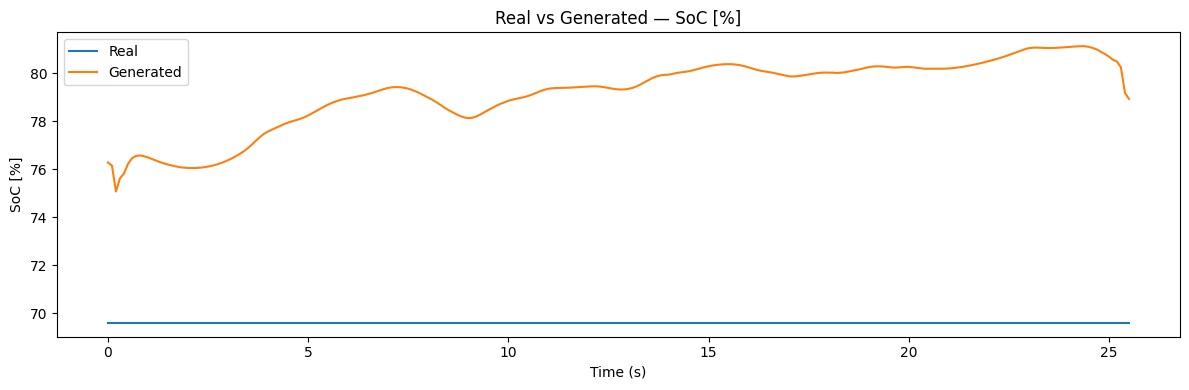

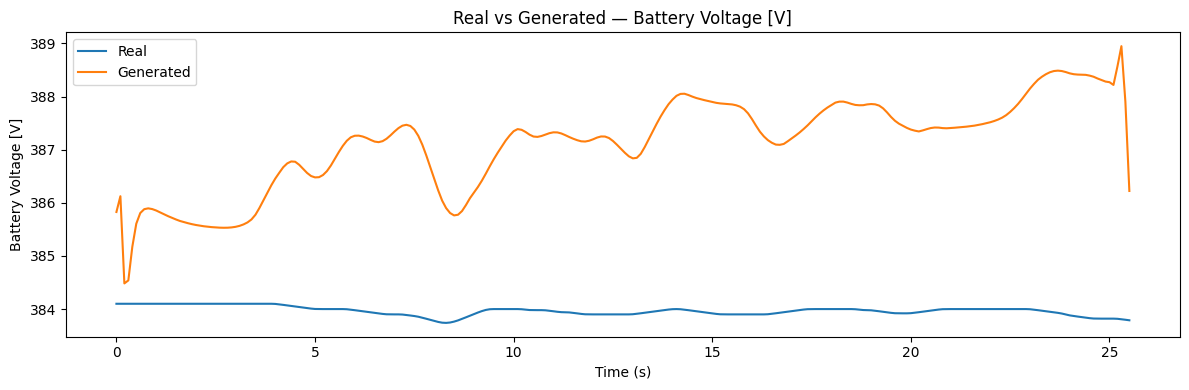

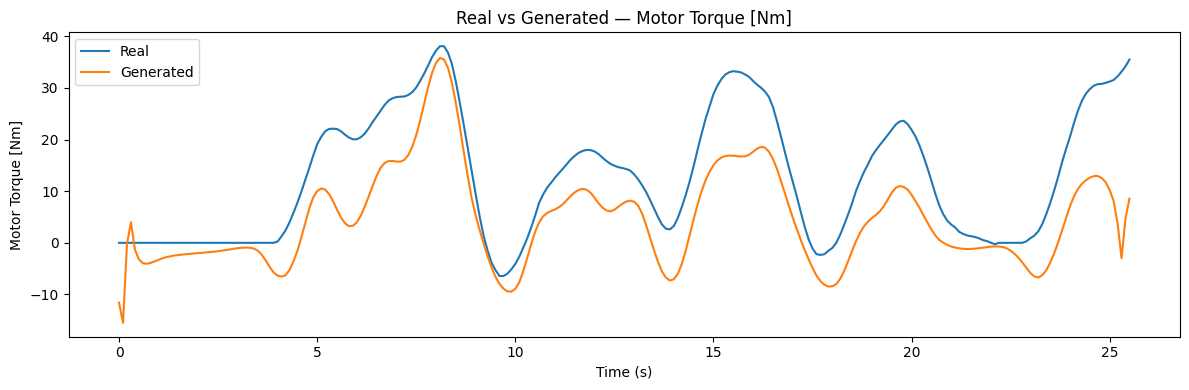

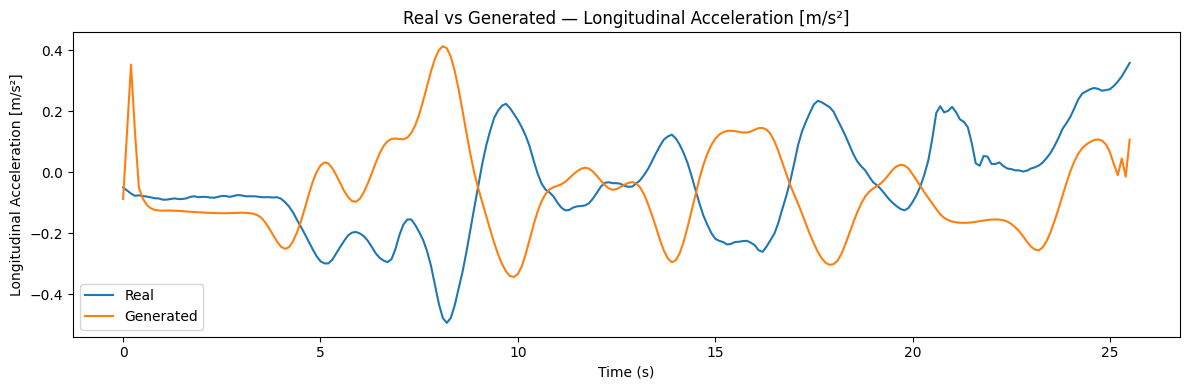

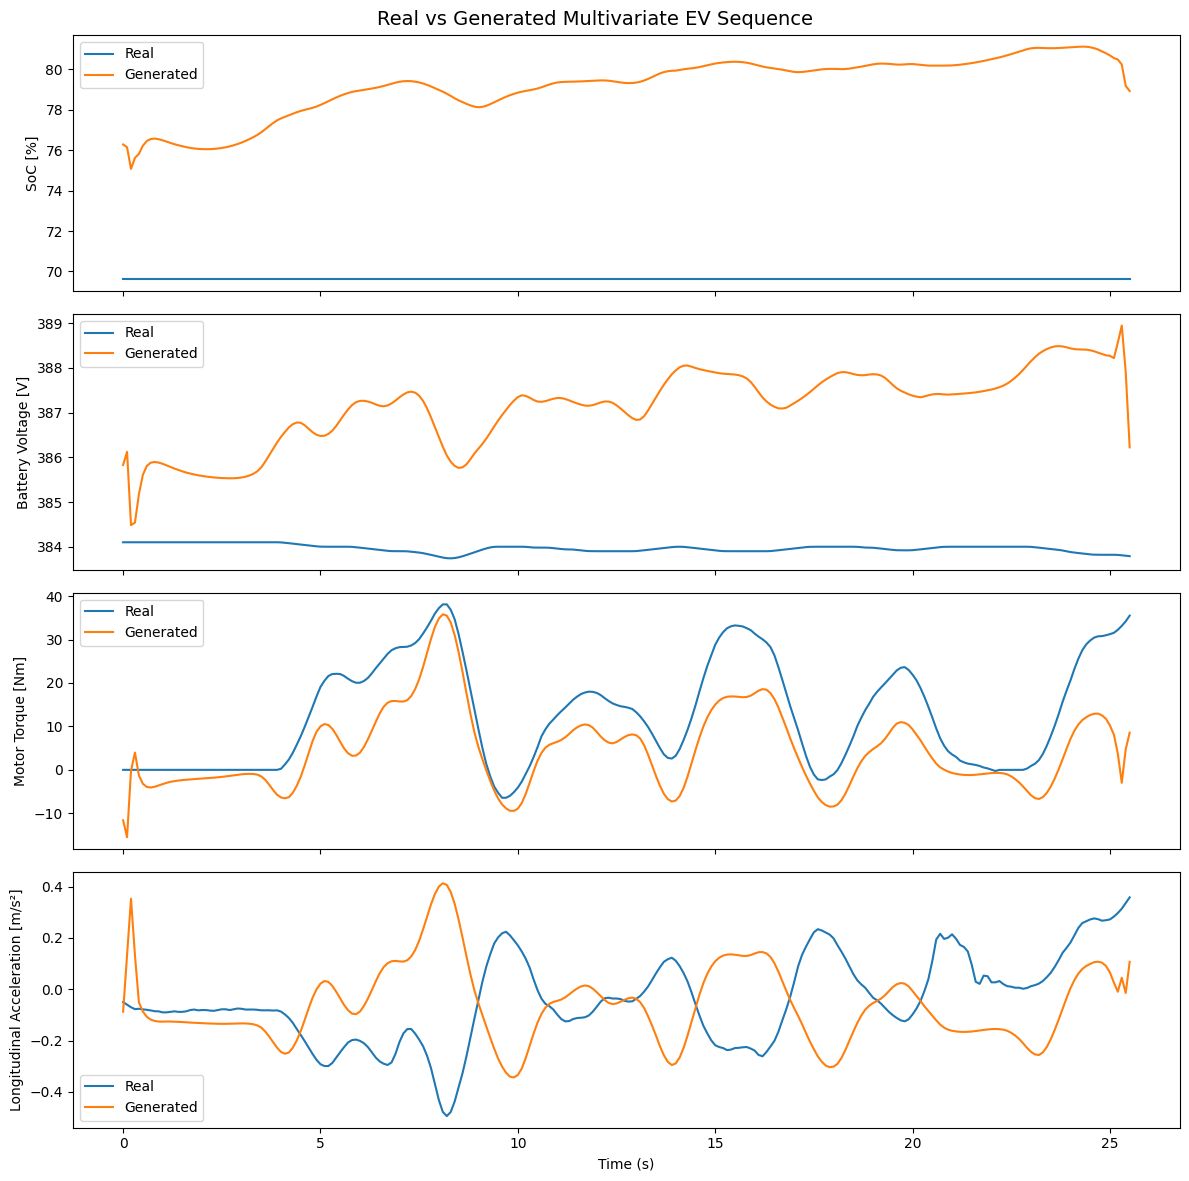

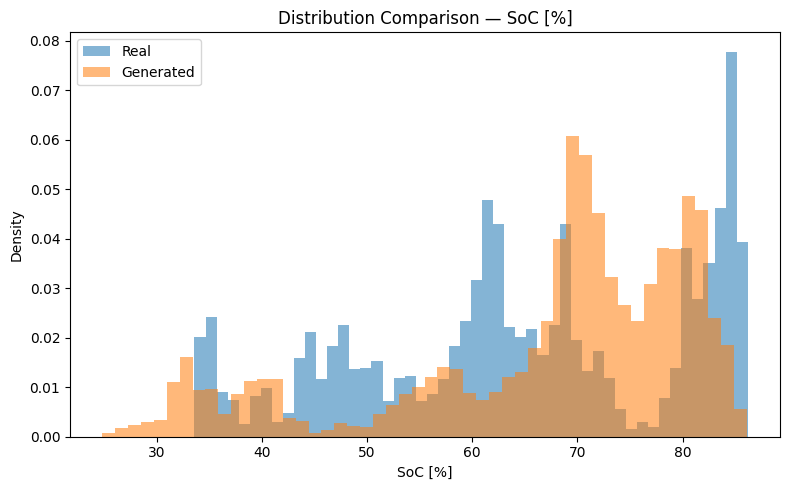

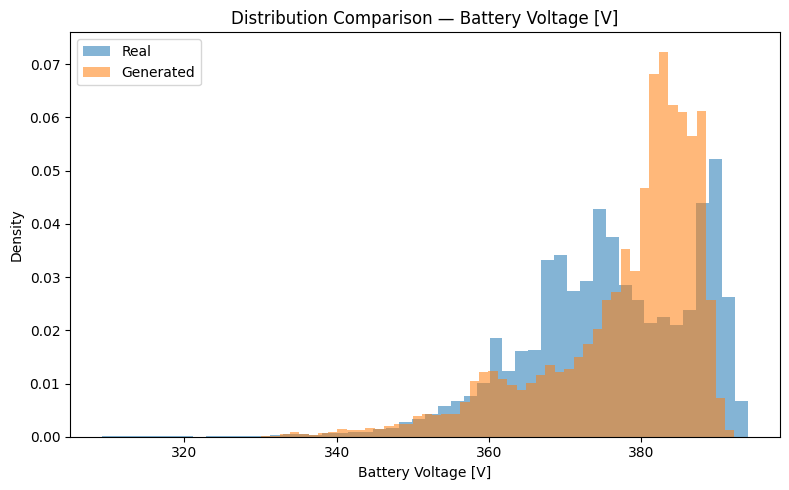

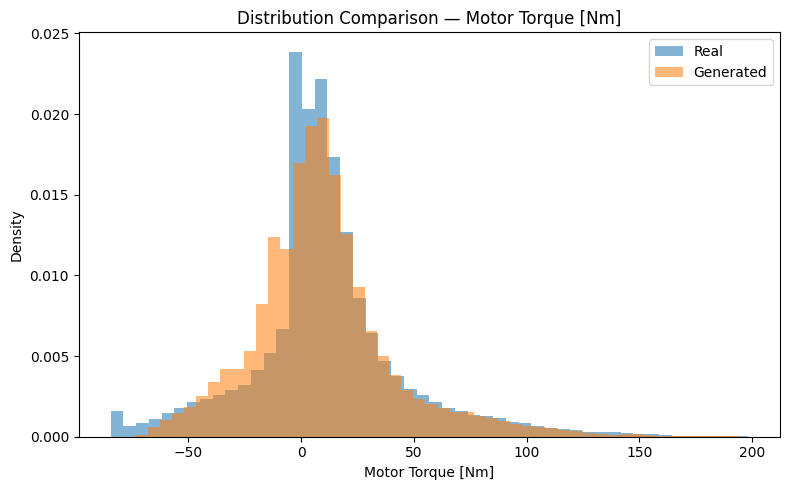

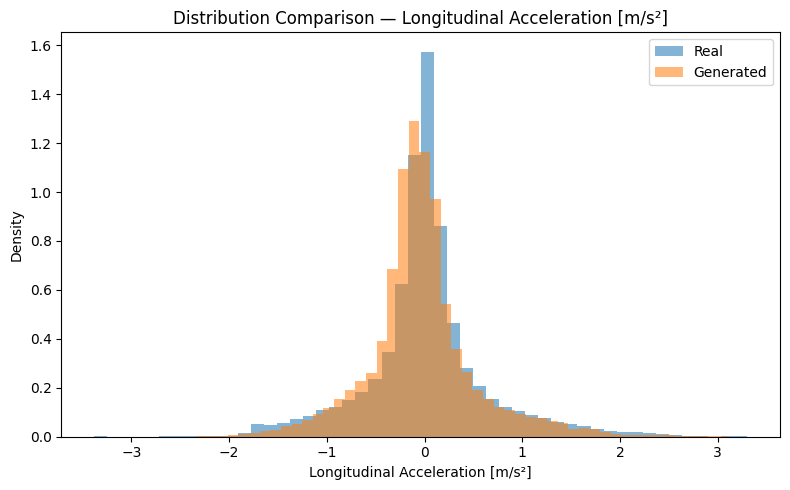

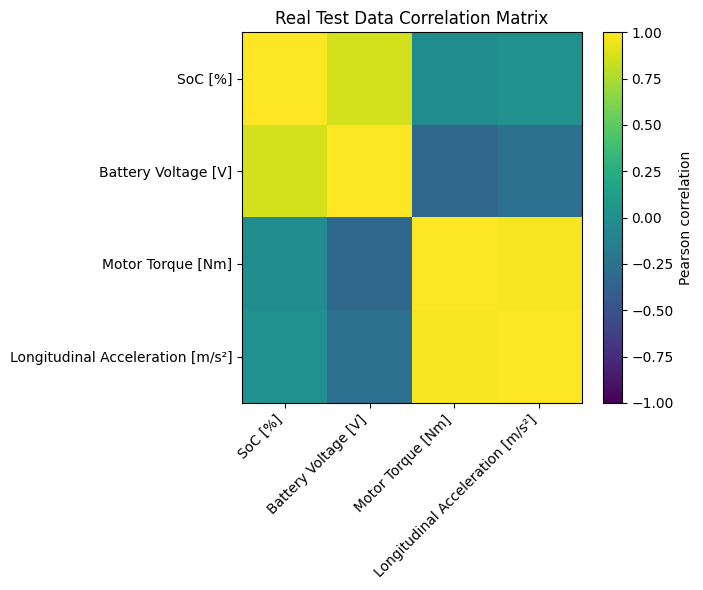

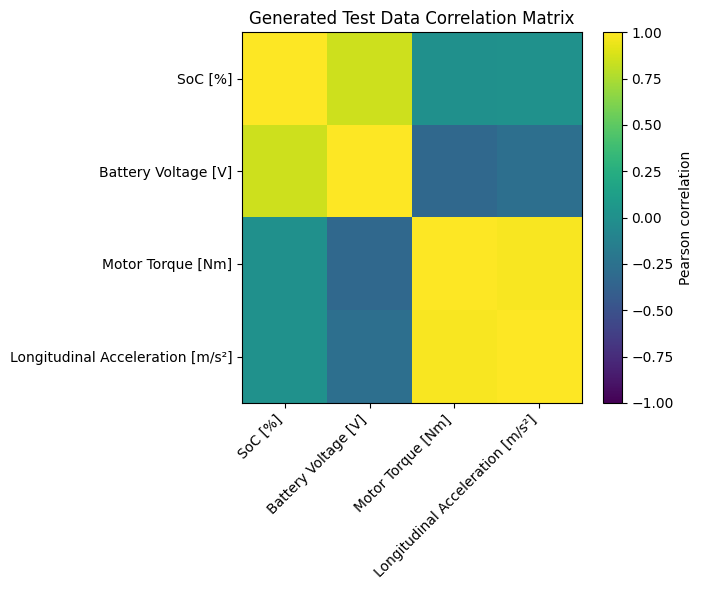

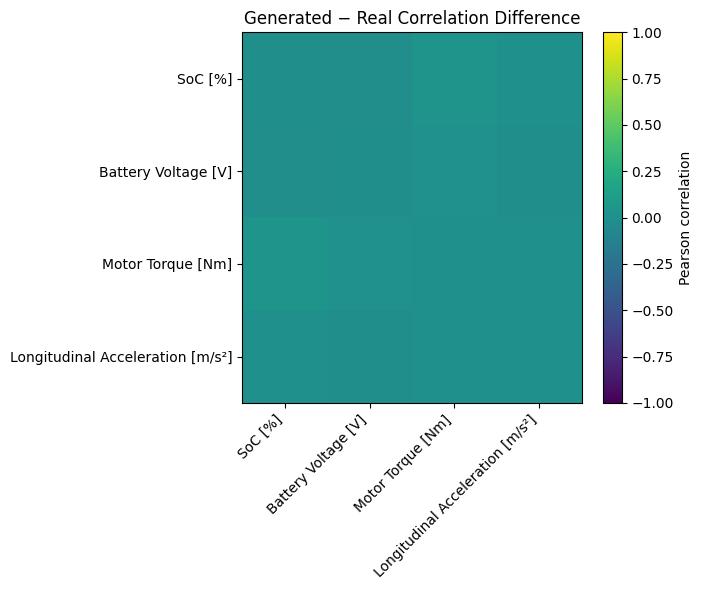

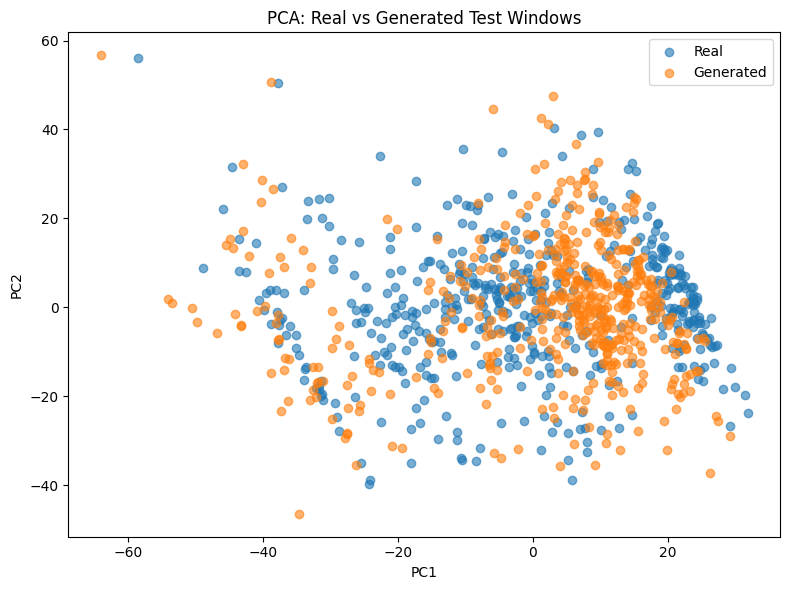


PCA explained variance ratio:
[0.59096086 0.39160073]
Total: 0.9825616


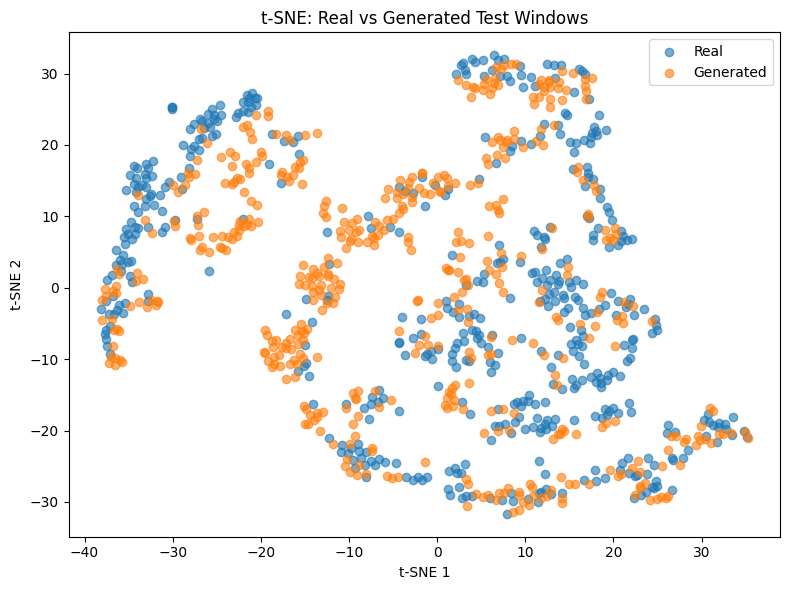


STEP 25 COMPLETED

All Step 25 figures and CSV files have been saved.


In [ ]:
# ============================================================
# STEP 25: VISUAL AND REPRESENTATION EVALUATION
# CORRECTED VERSION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print("=" * 75)
print("STEP 25: VISUAL AND REPRESENTATION EVALUATION")
print("=" * 75)


# ============================================================
# 1. FIGURE DIRECTORY
# ============================================================

FIGURES_DIR = os.path.join(
    RESULTS_DIR,
    "figures"
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)

print("\nFigure directory:")
print(FIGURES_DIR)


# ============================================================
# 2. FEATURE NAMES
# ============================================================

feature_names = [
    "SoC [%]",
    "Battery Voltage [V]",
    "Motor Torque [Nm]",
    "Longitudinal Acceleration [m/s²]"
]


# ============================================================
# 3. GET TEST ARRAYS
# ============================================================

real_test_scaled = np.asarray(
    Y_test_scaled
    if "Y_test_scaled" in globals()
    else Y_test
)

generated_test_scaled = np.asarray(
    Y_test_generated
)


print("\nReal test scaled shape:")
print(real_test_scaled.shape)

print("\nGenerated test scaled shape:")
print(generated_test_scaled.shape)


# ============================================================
# 4. INVERSE TRANSFORM OUTPUT FEATURES
# ============================================================

# The scaler was fitted on all 14 features.
# Output feature positions in the original 14-feature array:
# 10 = SoC
# 11 = Voltage
# 12 = Torque
# 13 = Acceleration

OUTPUT_ORIGINAL_INDICES = [
    10,
    11,
    12,
    13
]


def inverse_output_features(
    scaled_output
):

    scaled_output = np.asarray(
        scaled_output
    )

    n_samples = scaled_output.shape[0]
    n_steps = scaled_output.shape[1]

    flat = scaled_output.reshape(
        -1,
        scaled_output.shape[-1]
    )

    dummy = np.zeros(
        (
            flat.shape[0],
            14
        ),
        dtype=np.float32
    )

    dummy[
        :,
        OUTPUT_ORIGINAL_INDICES
    ] = flat

    inverse = scaler.inverse_transform(
        dummy
    )

    physical = inverse[
        :,
        OUTPUT_ORIGINAL_INDICES
    ]

    return physical.reshape(
        n_samples,
        n_steps,
        4
    )


real_test_physical = inverse_output_features(
    real_test_scaled
)

generated_test_physical = inverse_output_features(
    generated_test_scaled
)


print("\nReal test physical shape:")
print(real_test_physical.shape)

print("\nGenerated test physical shape:")
print(generated_test_physical.shape)


# ============================================================
# 5. SANITY CHECK
# ============================================================

print("\nPhysical ranges:")

for i, name in enumerate(feature_names):

    print(
        f"{name}: "
        f"Real [{real_test_physical[:,:,i].min():.3f}, "
        f"{real_test_physical[:,:,i].max():.3f}] | "
        f"Generated [{generated_test_physical[:,:,i].min():.3f}, "
        f"{generated_test_physical[:,:,i].max():.3f}]"
    )


# ============================================================
# 6. TIME AXIS
# ============================================================

sample_idx = 0

time_axis = (
    np.arange(
        real_test_physical.shape[1]
    ) * DT
)


# ============================================================
# 7. REAL VS GENERATED TRAJECTORIES
# ============================================================

for feature_idx, feature_name in enumerate(
    feature_names
):

    plt.figure(
        figsize=(12, 4)
    )

    plt.plot(
        time_axis,
        real_test_physical[
            sample_idx,
            :,
            feature_idx
        ],
        label="Real"
    )

    plt.plot(
        time_axis,
        generated_test_physical[
            sample_idx,
            :,
            feature_idx
        ],
        label="Generated"
    )

    plt.xlabel(
        "Time (s)"
    )

    plt.ylabel(
        feature_name
    )

    plt.title(
        f"Real vs Generated — {feature_name}"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            f"step25_real_vs_generated_{feature_idx}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 8. MULTI-SIGNAL FIGURE
# ============================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, 12),
    sharex=True
)

for feature_idx, feature_name in enumerate(
    feature_names
):

    axes[feature_idx].plot(
        time_axis,
        real_test_physical[
            sample_idx,
            :,
            feature_idx
        ],
        label="Real"
    )

    axes[feature_idx].plot(
        time_axis,
        generated_test_physical[
            sample_idx,
            :,
            feature_idx
        ],
        label="Generated"
    )

    axes[feature_idx].set_ylabel(
        feature_name
    )

    axes[feature_idx].legend()


axes[-1].set_xlabel(
    "Time (s)"
)

fig.suptitle(
    "Real vs Generated Multivariate EV Sequence",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "step25_real_vs_generated_multisignal.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. FEATURE DISTRIBUTIONS
# ============================================================

for feature_idx, feature_name in enumerate(
    feature_names
):

    real_values = real_test_physical[
        :,
        :,
        feature_idx
    ].flatten()

    generated_values = generated_test_physical[
        :,
        :,
        feature_idx
    ].flatten()

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(
        real_values,
        bins=50,
        alpha=0.55,
        density=True,
        label="Real"
    )

    plt.hist(
        generated_values,
        bins=50,
        alpha=0.55,
        density=True,
        label="Generated"
    )

    plt.xlabel(
        feature_name
    )

    plt.ylabel(
        "Density"
    )

    plt.title(
        f"Distribution Comparison — {feature_name}"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            f"step25_distribution_{feature_idx}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 10. CORRELATION MATRICES
# ============================================================

real_flat = real_test_physical.reshape(
    -1,
    4
)

generated_flat = generated_test_physical.reshape(
    -1,
    4
)

real_corr = np.corrcoef(
    real_flat,
    rowvar=False
)

generated_corr = np.corrcoef(
    generated_flat,
    rowvar=False
)


def plot_corr(
    matrix,
    title,
    filename
):

    plt.figure(
        figsize=(7, 6)
    )

    plt.imshow(
        matrix,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    plt.colorbar(
        label="Pearson correlation"
    )

    plt.xticks(
        range(4),
        feature_names,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(4),
        feature_names
    )

    plt.title(
        title
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURES_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


plot_corr(
    real_corr,
    "Real Test Data Correlation Matrix",
    "step25_real_correlation_matrix.png"
)

plot_corr(
    generated_corr,
    "Generated Test Data Correlation Matrix",
    "step25_generated_correlation_matrix.png"
)


# ============================================================
# 11. CORRELATION DIFFERENCE
# ============================================================

plot_corr(
    generated_corr - real_corr,
    "Generated − Real Correlation Difference",
    "step25_correlation_difference.png"
)


# ============================================================
# 12. PCA
# ============================================================

rng = np.random.default_rng(
    SEED
)

n_samples = min(
    500,
    len(real_test_physical)
)

indices = rng.choice(
    len(real_test_physical),
    size=n_samples,
    replace=False
)


# Temporal mean representation
real_features = np.mean(
    real_test_physical[
        indices
    ],
    axis=1
)

generated_features = np.mean(
    generated_test_physical[
        indices
    ],
    axis=1
)

combined = np.vstack([
    real_features,
    generated_features
])


pca = PCA(
    n_components=2,
    random_state=SEED
)

pca_result = pca.fit_transform(
    combined
)


plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    pca_result[:n_samples, 0],
    pca_result[:n_samples, 1],
    alpha=0.6,
    label="Real"
)

plt.scatter(
    pca_result[n_samples:, 0],
    pca_result[n_samples:, 1],
    alpha=0.6,
    label="Generated"
)

plt.xlabel(
    "PC1"
)

plt.ylabel(
    "PC2"
)

plt.title(
    "PCA: Real vs Generated Test Windows"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "step25_PCA_real_vs_generated.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nPCA explained variance ratio:"
)

print(
    pca.explained_variance_ratio_
)

print(
    "Total:",
    np.sum(
        pca.explained_variance_ratio_
    )
)


# ============================================================
# 13. t-SNE
# ============================================================

tsne_input = StandardScaler().fit_transform(
    combined
)

perplexity = min(
    30,
    max(
        5,
        len(tsne_input) // 10
    )
)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=SEED,
    init="pca",
    learning_rate="auto"
)

tsne_result = tsne.fit_transform(
    tsne_input
)


plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    tsne_result[:n_samples, 0],
    tsne_result[:n_samples, 1],
    alpha=0.6,
    label="Real"
)

plt.scatter(
    tsne_result[n_samples:, 0],
    tsne_result[n_samples:, 1],
    alpha=0.6,
    label="Generated"
)

plt.xlabel(
    "t-SNE 1"
)

plt.ylabel(
    "t-SNE 2"
)

plt.title(
    "t-SNE: Real vs Generated Test Windows"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_DIR,
        "step25_tSNE_real_vs_generated.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. SAVE REPRESENTATION DATA
# ============================================================

pca_df = pd.DataFrame({

    "PC1": pca_result[:, 0],

    "PC2": pca_result[:, 1],

    "Type": (
        ["Real"] * n_samples
        +
        ["Generated"] * n_samples
    )
})

pca_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_PCA_coordinates.csv"
    ),
    index=False
)


tsne_df = pd.DataFrame({

    "tSNE1": tsne_result[:, 0],

    "tSNE2": tsne_result[:, 1],

    "Type": (
        ["Real"] * n_samples
        +
        ["Generated"] * n_samples
    )
})

tsne_df.to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_tSNE_coordinates.csv"
    ),
    index=False
)


# ============================================================
# 15. SAVE CORRELATION MATRICES
# ============================================================

pd.DataFrame(
    real_corr,
    index=feature_names,
    columns=feature_names
).to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_real_correlation_matrix.csv"
    )
)

pd.DataFrame(
    generated_corr,
    index=feature_names,
    columns=feature_names
).to_csv(
    os.path.join(
        RESULTS_DIR,
        "RE_PI_CycleEV_generated_correlation_matrix.csv"
    )
)


print("\n" + "=" * 75)
print("STEP 25 COMPLETED")
print("=" * 75)
print("\nAll Step 25 figures and CSV files have been saved.")

STEP 26: PI-CycleEV BASELINE vs RE-PI-CycleEV

Full test input shape:
(520, 256, 14)

Baseline input shape after selecting 10 inputs:
(520, 256, 10)

Real test output shape:
(520, 256, 4)

RE-PI-CycleEV generated shape:
(520, 256, 4)

Baseline generator input:
(None, 256, 10)

Baseline generator output:
(None, 256, 4)

Input feature check: PASSED

Generating PI-CycleEV baseline test sequences...

Baseline generated shape:
(520, 256, 4)

Shape check: PASSED

NaN / Inf check:
Baseline NaN: 0
Baseline Inf: 0
RE-PI NaN: 0
RE-PI Inf: 0

Physical conversion completed.

E1 — PI-CycleEV BASELINE TEST METRICS


,Feature,MAE,RMSE
0,SoC [%],13.731561,16.527681
1,Battery Voltage [V],7.225536,8.774252
2,Motor Torque [Nm],6.088808,8.697895
3,Longitudinal Acceleration [m/s²],0.151522,0.209647
4,Overall,6.799357,8.552369



E4 — FULL RE-PI-CycleEV TEST METRICS


,Feature,MAE,RMSE
0,SoC [%],10.317949,13.548301
1,Battery Voltage [V],5.519685,7.215979
2,Motor Torque [Nm],6.887894,10.294536
3,Longitudinal Acceleration [m/s²],0.143880,0.214323
4,Overall,5.717352,7.818285



E1 vs E4 — BASELINE COMPARISON


,Feature,PI-CycleEV_MAE,RE-PI-CycleEV_MAE,PI-CycleEV_RMSE,RE-PI-CycleEV_RMSE,MAE_difference_RE_minus_PI,RMSE_difference_RE_minus_PI
0,SoC [%],13.731561,10.317949,16.527681,13.548301,-3.413611,-2.979380
1,Battery Voltage [V],7.225536,5.519685,8.774252,7.215979,-1.705851,-1.558274
2,Motor Torque [Nm],6.088808,6.887894,8.697895,10.294536,0.799086,1.596641
3,Longitudinal Acceleration [m/s²],0.151522,0.143880,0.209647,0.214323,-0.007642,0.004676



Comparison saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/E1_vs_E4_baseline_comparison.csv

PHYSICAL RANGE COMPARISON


,Feature,Real_Min,Real_Max,PI_CycleEV_Min,PI_CycleEV_Max,RE_PI_CycleEV_Min,RE_PI_CycleEV_Max
0,SoC [%],33.599998,86.199997,22.981001,86.587601,24.840401,86.108597
1,Battery Voltage [V],309.191986,394.059998,325.567902,392.147095,330.105194,392.312195
2,Motor Torque [Nm],-84.502998,198.181000,-75.928001,197.719894,-73.513802,194.397003
3,Longitudinal Acceleration [m/s²],-3.382000,3.303000,-2.120300,3.338800,-2.340800,3.103100


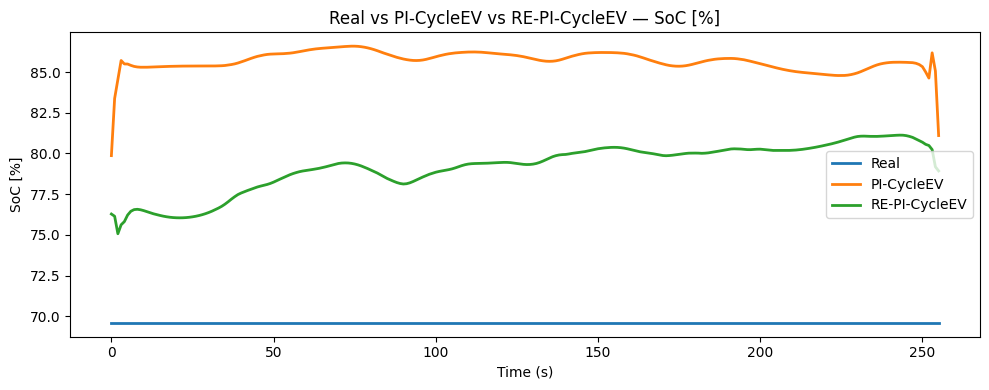

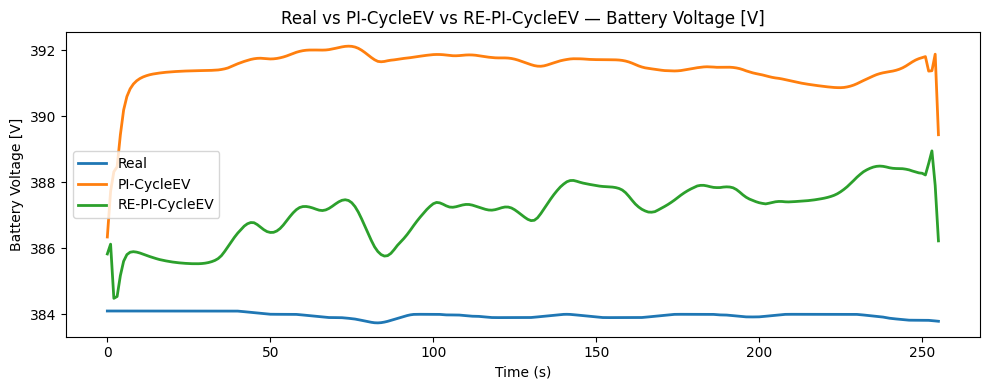

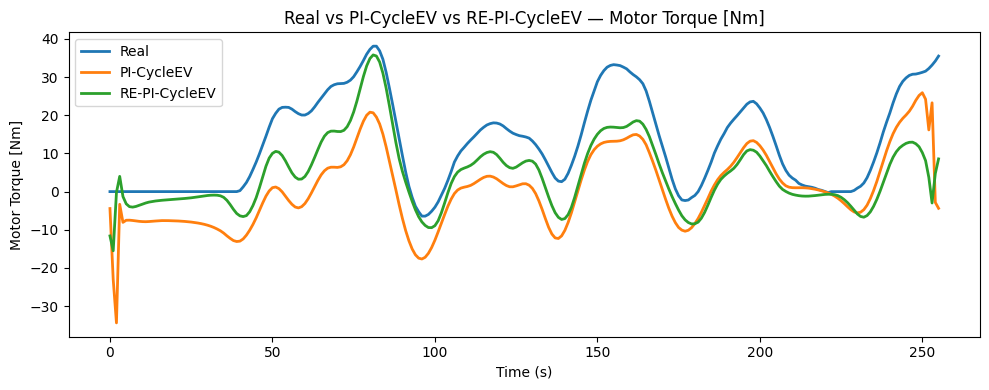

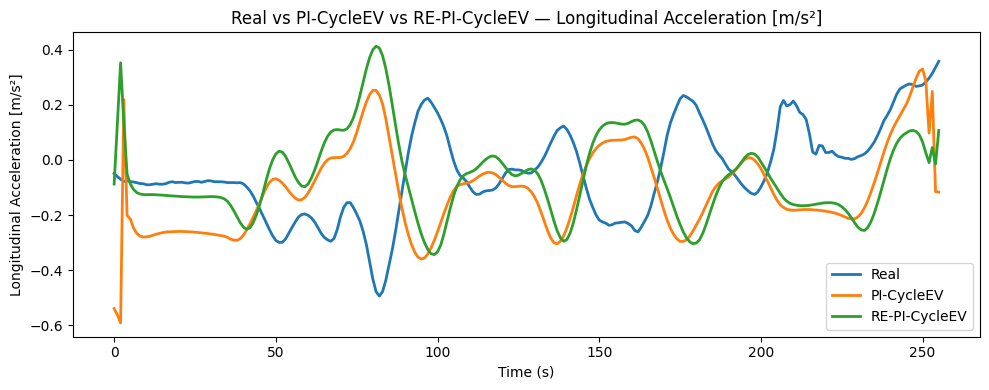



STEP 26 COMPLETED

E1 = PI-CycleEV baseline
E4 = Full RE-PI-CycleEV

Comparison:
/content/drive/MyDrive/RE_PI_CycleEV/results/E1_vs_E4_baseline_comparison.csv

Physical ranges:
/content/drive/MyDrive/RE_PI_CycleEV/results/E1_E4_physical_ranges.csv

Baseline generated scaled data:
/content/drive/MyDrive/RE_PI_CycleEV/results/generated_samples/PI_CycleEV_baseline_test_scaled.npy

Baseline generated physical data:
/content/drive/MyDrive/RE_PI_CycleEV/results/generated_samples/PI_CycleEV_baseline_test_physical.npy

Step 26 is complete.


In [ ]:
# ============================================================
# STEP 26: PI-CycleEV BASELINE vs RE-PI-CycleEV COMPARISON
# E1 = Corrected PI-CycleEV baseline
# E4 = Full RE-PI-CycleEV
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("=" * 75)
print("STEP 26: PI-CycleEV BASELINE vs RE-PI-CycleEV")
print("=" * 75)


# ------------------------------------------------------------
# 26.1 PREPARE TEST DATA
# ------------------------------------------------------------

# The corrected PI-CycleEV baseline was trained using
# ONLY the 10 input features.
#
# Full window has 14 features:
# columns 0-9  = inputs
# columns 10-13 = outputs

if "X_test_scaled" in globals():
    X_test_full = np.asarray(X_test_scaled)
elif "X_test" in globals():
    X_test_full = np.asarray(X_test)
else:
    raise NameError("Could not find X_test_scaled or X_test.")


# Select only the 10 input features
X_test_for_baseline = X_test_full[:, :, :10]


# Real test outputs
if "Y_test_scaled" in globals():
    Y_test_for_comparison = np.asarray(Y_test_scaled)
elif "Y_test" in globals():
    Y_test_for_comparison = np.asarray(Y_test)
else:
    raise NameError("Could not find Y_test_scaled or Y_test.")


# Full RE-PI-CycleEV generated test data
RE_test_scaled = np.asarray(Y_test_generated)


print("\nFull test input shape:")
print(X_test_full.shape)

print("\nBaseline input shape after selecting 10 inputs:")
print(X_test_for_baseline.shape)

print("\nReal test output shape:")
print(Y_test_for_comparison.shape)

print("\nRE-PI-CycleEV generated shape:")
print(RE_test_scaled.shape)


# ------------------------------------------------------------
# 26.2 VERIFY BASELINE MODEL INPUT
# ------------------------------------------------------------

print("\nBaseline generator input:")
print(corrected_baseline_generator.input_shape)

print("\nBaseline generator output:")
print(corrected_baseline_generator.output_shape)


assert X_test_for_baseline.shape[2] == 10, \
    "Baseline input must contain exactly 10 features."

print("\nInput feature check: PASSED")


# ------------------------------------------------------------
# 26.3 GENERATE PI-CYCLEEV BASELINE TEST DATA
# ------------------------------------------------------------

print("\nGenerating PI-CycleEV baseline test sequences...")

baseline_test_scaled = corrected_baseline_generator.predict(
    X_test_for_baseline,
    verbose=0
)

baseline_test_scaled = np.asarray(
    baseline_test_scaled
)

print("\nBaseline generated shape:")
print(baseline_test_scaled.shape)


# ------------------------------------------------------------
# 26.4 SANITY CHECK
# ------------------------------------------------------------

assert baseline_test_scaled.shape == Y_test_for_comparison.shape
assert RE_test_scaled.shape == Y_test_for_comparison.shape

print("\nShape check: PASSED")


print("\nNaN / Inf check:")

print(
    "Baseline NaN:",
    np.isnan(baseline_test_scaled).sum()
)

print(
    "Baseline Inf:",
    np.isinf(baseline_test_scaled).sum()
)

print(
    "RE-PI NaN:",
    np.isnan(RE_test_scaled).sum()
)

print(
    "RE-PI Inf:",
    np.isinf(RE_test_scaled).sum()
)


# ------------------------------------------------------------
# 26.5 INVERSE TRANSFORM OUTPUTS
# ------------------------------------------------------------

OUTPUT_INDICES = [10, 11, 12, 13]

def inverse_output_features(scaled_output):

    flat = scaled_output.reshape(-1, 4)

    dummy = np.zeros(
        (flat.shape[0], 14),
        dtype=np.float32
    )

    dummy[:, OUTPUT_INDICES] = flat

    physical = scaler.inverse_transform(dummy)

    output_physical = physical[:, OUTPUT_INDICES]

    return output_physical.reshape(
        scaled_output.shape
    )


Y_test_physical_26 = inverse_output_features(
    Y_test_for_comparison
)

baseline_test_physical = inverse_output_features(
    baseline_test_scaled
)

RE_test_physical = inverse_output_features(
    RE_test_scaled
)

print("\nPhysical conversion completed.")


# ------------------------------------------------------------
# 26.6 FEATURE NAMES
# ------------------------------------------------------------

OUTPUT_NAMES = [
    "SoC [%]",
    "Battery Voltage [V]",
    "Motor Torque [Nm]",
    "Longitudinal Acceleration [m/s²]"
]


# ------------------------------------------------------------
# 26.7 METRIC FUNCTION
# ------------------------------------------------------------

def calculate_metrics(real_data, generated_data):

    rows = []

    for i, feature in enumerate(OUTPUT_NAMES):

        real_flat = real_data[:, :, i].reshape(-1)
        gen_flat = generated_data[:, :, i].reshape(-1)

        mae = mean_absolute_error(
            real_flat,
            gen_flat
        )

        rmse = np.sqrt(
            mean_squared_error(
                real_flat,
                gen_flat
            )
        )

        rows.append({
            "Feature": feature,
            "MAE": mae,
            "RMSE": rmse
        })

    overall_mae = np.mean([
        row["MAE"] for row in rows
    ])

    overall_rmse = np.mean([
        row["RMSE"] for row in rows
    ])

    rows.append({
        "Feature": "Overall",
        "MAE": overall_mae,
        "RMSE": overall_rmse
    })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 26.8 E1 — PI-CycleEV BASELINE
# ------------------------------------------------------------

baseline_metrics_test = calculate_metrics(
    Y_test_physical_26,
    baseline_test_physical
)

print("\n" + "=" * 75)
print("E1 — PI-CycleEV BASELINE TEST METRICS")
print("=" * 75)

display(
    baseline_metrics_test.round(6)
)


# ------------------------------------------------------------
# 26.9 E4 — FULL RE-PI-CycleEV
# ------------------------------------------------------------

repi_metrics_test = calculate_metrics(
    Y_test_physical_26,
    RE_test_physical
)

print("\n" + "=" * 75)
print("E4 — FULL RE-PI-CycleEV TEST METRICS")
print("=" * 75)

display(
    repi_metrics_test.round(6)
)


# ------------------------------------------------------------
# 26.10 E1 vs E4 COMPARISON
# ------------------------------------------------------------

comparison_rows = []

for i, feature in enumerate(OUTPUT_NAMES):

    baseline_mae = baseline_metrics_test.iloc[i]["MAE"]
    baseline_rmse = baseline_metrics_test.iloc[i]["RMSE"]

    repi_mae = repi_metrics_test.iloc[i]["MAE"]
    repi_rmse = repi_metrics_test.iloc[i]["RMSE"]

    comparison_rows.append({

        "Feature": feature,

        "PI-CycleEV_MAE":
            baseline_mae,

        "RE-PI-CycleEV_MAE":
            repi_mae,

        "PI-CycleEV_RMSE":
            baseline_rmse,

        "RE-PI-CycleEV_RMSE":
            repi_rmse,

        "MAE_difference_RE_minus_PI":
            repi_mae - baseline_mae,

        "RMSE_difference_RE_minus_PI":
            repi_rmse - baseline_rmse
    })


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 75)
print("E1 vs E4 — BASELINE COMPARISON")
print("=" * 75)

display(
    comparison_df.round(6)
)


# ------------------------------------------------------------
# 26.11 SAVE COMPARISON
# ------------------------------------------------------------

RESULTS_DIR = (
    "/content/drive/MyDrive/RE_PI_CycleEV/results"
)

FIG_DIR = (
    "/content/drive/MyDrive/RE_PI_CycleEV/results/figures"
)

GENERATED_DIR = (
    "/content/drive/MyDrive/RE_PI_CycleEV/results/generated_samples"
)

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(GENERATED_DIR, exist_ok=True)


comparison_path = os.path.join(
    RESULTS_DIR,
    "E1_vs_E4_baseline_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("\nComparison saved:")
print(comparison_path)


# ------------------------------------------------------------
# 26.12 PHYSICAL RANGE COMPARISON
# ------------------------------------------------------------

range_rows = []

for i, feature in enumerate(OUTPUT_NAMES):

    range_rows.append({

        "Feature": feature,

        "Real_Min":
            np.min(Y_test_physical_26[:, :, i]),

        "Real_Max":
            np.max(Y_test_physical_26[:, :, i]),

        "PI_CycleEV_Min":
            np.min(baseline_test_physical[:, :, i]),

        "PI_CycleEV_Max":
            np.max(baseline_test_physical[:, :, i]),

        "RE_PI_CycleEV_Min":
            np.min(RE_test_physical[:, :, i]),

        "RE_PI_CycleEV_Max":
            np.max(RE_test_physical[:, :, i])
    })


range_comparison_df = pd.DataFrame(
    range_rows
)

print("\n" + "=" * 75)
print("PHYSICAL RANGE COMPARISON")
print("=" * 75)

display(
    range_comparison_df.round(4)
)


range_path = os.path.join(
    RESULTS_DIR,
    "E1_E4_physical_ranges.csv"
)

range_comparison_df.to_csv(
    range_path,
    index=False
)


# ------------------------------------------------------------
# 26.13 REAL vs PI vs RE TRAJECTORIES
# ------------------------------------------------------------

sample_idx = 0

time_axis = np.arange(
    Y_test_physical_26.shape[1]
)

for i, feature in enumerate(OUTPUT_NAMES):

    plt.figure(figsize=(10, 4))

    plt.plot(
        time_axis,
        Y_test_physical_26[sample_idx, :, i],
        label="Real",
        linewidth=2
    )

    plt.plot(
        time_axis,
        baseline_test_physical[sample_idx, :, i],
        label="PI-CycleEV",
        linewidth=2
    )

    plt.plot(
        time_axis,
        RE_test_physical[sample_idx, :, i],
        label="RE-PI-CycleEV",
        linewidth=2
    )

    plt.xlabel("Time (s)")
    plt.ylabel(feature)

    plt.title(
        f"Real vs PI-CycleEV vs RE-PI-CycleEV — {feature}"
    )

    plt.legend()
    plt.tight_layout()

    safe_name = (
        feature
        .replace(" ", "_")
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_")
        .replace("²", "2")
    )

    save_path = os.path.join(
        FIG_DIR,
        f"E1_E4_comparison_{safe_name}.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# 26.14 SAVE BASELINE GENERATED DATA
# ------------------------------------------------------------

baseline_generated_path = os.path.join(
    GENERATED_DIR,
    "PI_CycleEV_baseline_test_scaled.npy"
)

baseline_generated_physical_path = os.path.join(
    GENERATED_DIR,
    "PI_CycleEV_baseline_test_physical.npy"
)

np.save(
    baseline_generated_path,
    baseline_test_scaled
)

np.save(
    baseline_generated_physical_path,
    baseline_test_physical
)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n")
print("=" * 75)
print("STEP 26 COMPLETED")
print("=" * 75)

print("\nE1 = PI-CycleEV baseline")
print("E4 = Full RE-PI-CycleEV")

print("\nComparison:")
print(comparison_path)

print("\nPhysical ranges:")
print(range_path)

print("\nBaseline generated scaled data:")
print(baseline_generated_path)

print("\nBaseline generated physical data:")
print(baseline_generated_physical_path)

print("\nStep 26 is complete.")

In [ ]:
# ================================================================
# STEP 27E: E2 ABLATION
# RE-PI-CycleEV WITHOUT RARITY-AWARE SAMPLING
# Event consistency = ON
# Physics losses = ON
# ================================================================

import numpy as np
import tensorflow as tf
import pandas as pd
import os
import time

print("="*75)
print("STEP 27E: E2 - WITHOUT RARITY-AWARE SAMPLING")
print("="*75)

# ------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------

E2_SEED = 42

np.random.seed(E2_SEED)
tf.random.set_seed(E2_SEED)

# ------------------------------------------------
# 2. Uniform sampling probabilities
# ------------------------------------------------

e2_sampling_probabilities = np.ones(
    N_TRAIN,
    dtype=np.float64
) / N_TRAIN

print("Sampling strategy: UNIFORM")
print("N_TRAIN:", N_TRAIN)
print("Probability per sample:", e2_sampling_probabilities[0])
print("Probability sum:", e2_sampling_probabilities.sum())

# ------------------------------------------------
# 3. E2 batch sampler
# ------------------------------------------------

def e2_sample_training_batch(batch_size):

    indices = np.random.choice(
        N_TRAIN,
        size=batch_size,
        replace=True,
        p=e2_sampling_probabilities
    )

    batch_X = X_train_input[indices].astype(np.float32)
    batch_Y = Y_train[indices].astype(np.float32)
    batch_C = C_train[indices].astype(np.float32)

    return batch_X, batch_Y, batch_C

# ------------------------------------------------
# 4. Build NEW E2 generator
# ------------------------------------------------

def build_repi_generator_e2(
    sequence_length=256,
    n_inputs=10,
    n_conditions=5,
    n_outputs=4
):

    inp = tf.keras.Input(
        shape=(sequence_length, n_inputs),
        name="e2_input_sequence"
    )

    condition = tf.keras.Input(
        shape=(n_conditions,),
        name="e2_condition"
    )

    condition_seq = tf.keras.layers.RepeatVector(
        sequence_length
    )(condition)

    x = tf.keras.layers.Concatenate(axis=-1)(
        [inp, condition_seq]
    )

    x = tf.keras.layers.Conv1D(
        64,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv1D(
        128,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            64,
            return_sequences=True
        )
    )(x)

    x = tf.keras.layers.Dropout(0.2)(x)

    out = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(
            n_outputs,
            activation="tanh"
        )
    )(x)

    return tf.keras.Model(
        [inp, condition],
        out,
        name="E2_REPI_Generator"
    )


# ------------------------------------------------
# 5. Build NEW E2 discriminator
# ------------------------------------------------

def build_repi_discriminator_e2(
    sequence_length=256,
    n_inputs=10,
    n_outputs=4,
    n_conditions=5
):

    inp = tf.keras.Input(
        shape=(sequence_length, n_inputs),
        name="e2_disc_input"
    )

    target = tf.keras.Input(
        shape=(sequence_length, n_outputs),
        name="e2_disc_target"
    )

    condition = tf.keras.Input(
        shape=(n_conditions,),
        name="e2_disc_condition"
    )

    condition_seq = tf.keras.layers.RepeatVector(
        sequence_length
    )(condition)

    x = tf.keras.layers.Concatenate(axis=-1)(
        [
            inp,
            target,
            condition_seq
        ]
    )

    x = tf.keras.layers.Conv1D(
        64,
        kernel_size=5,
        strides=2,
        padding="same"
    )(x)

    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv1D(
        128,
        kernel_size=5,
        strides=2,
        padding="same"
    )(x)

    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv1D(
        256,
        kernel_size=5,
        strides=2,
        padding="same"
    )(x)

    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    real_fake = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="e2_real_fake"
    )(x)

    event_output = tf.keras.layers.Dense(
        N_EVENT_FEATURES,
        activation="sigmoid",
        name="e2_event_output"
    )(x)

    return tf.keras.Model(
        [inp, target, condition],
        [real_fake, event_output],
        name="E2_REPI_Discriminator"
    )


e2_generator = build_repi_generator_e2()
e2_discriminator = build_repi_discriminator_e2()

print("\nE2 Generator parameters:",
      e2_generator.count_params())

print("E2 Discriminator parameters:",
      e2_discriminator.count_params())

# ------------------------------------------------
# 6. Separate optimizers
# ------------------------------------------------

e2_generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5,
    beta_2=0.999
)

e2_discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5,
    beta_2=0.999
)

# ------------------------------------------------
# 7. E2 train step
# ------------------------------------------------
# Same loss structure as E4.
# ONLY sampling is different.
# ------------------------------------------------

@tf.function
def e2_train_step(
    input_sequence,
    real_target,
    event_condition
):

    # ========================================================
    # DISCRIMINATOR
    # ========================================================

    with tf.GradientTape() as disc_tape:

        fake_target = e2_generator(
            [
                input_sequence,
                event_condition
            ],
            training=True
        )

        real_prediction, real_event_prediction = (
            e2_discriminator(
                [
                    input_sequence,
                    real_target,
                    event_condition
                ],
                training=True
            )
        )

        fake_prediction, fake_event_prediction = (
            e2_discriminator(
                [
                    input_sequence,
                    fake_target,
                    event_condition
                ],
                training=True
            )
        )

        d_adv_loss = repi_discriminator_loss(
            real_prediction,
            fake_prediction
        )

        d_real_event_loss = event_consistency_loss(
            event_condition,
            real_event_prediction
        )

        d_fake_event_loss = event_consistency_loss(
            event_condition,
            fake_event_prediction
        )

        d_total_loss = (
            d_adv_loss
            +
            LAMBDA_REPI_EVENT
            * 0.5
            * (
                d_real_event_loss
                +
                d_fake_event_loss
            )
        )

    disc_gradients = disc_tape.gradient(
        d_total_loss,
        e2_discriminator.trainable_variables
    )

    e2_discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            e2_discriminator.trainable_variables
        )
    )

    # ========================================================
    # GENERATOR
    # ========================================================

    with tf.GradientTape() as gen_tape:

        fake_target = e2_generator(
            [
                input_sequence,
                event_condition
            ],
            training=True
        )

        fake_prediction, fake_event_prediction = (
            e2_discriminator(
                [
                    input_sequence,
                    fake_target,
                    event_condition
                ],
                training=True
            )
        )

        g_adv_loss = repi_generator_adversarial_loss(
            fake_prediction
        )

        g_identity_loss = repi_identity_loss(
            real_target,
            fake_target
        )

        g_soc_physics_loss = (
            soc_current_physics_loss(
                fake_target[:, :, SOC_OUTPUT_INDEX - 10],
                input_sequence[:, :, CURRENT_INPUT_INDEX]
            )
        )

        g_acc_physics_loss = (
            velocity_acceleration_physics_loss(
                fake_target[:, :, ACC_OUTPUT_INDEX - 10],
                input_sequence[:, :, VELOCITY_INPUT_INDEX]
            )
        )

        g_range_loss = range_plausibility_loss(
            fake_target
        )

        g_event_loss = event_consistency_loss(
            event_condition,
            fake_event_prediction
        )

        g_total_loss = (
            g_adv_loss
            +
            LAMBDA_REPI_IDENTITY * g_identity_loss
            +
            LAMBDA_REPI_SOC * g_soc_physics_loss
            +
            LAMBDA_REPI_ACCEL * g_acc_physics_loss
            +
            LAMBDA_REPI_RANGE * g_range_loss
            +
            LAMBDA_REPI_EVENT * g_event_loss
        )

    gen_gradients = gen_tape.gradient(
        g_total_loss,
        e2_generator.trainable_variables
    )

    e2_generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            e2_generator.trainable_variables
        )
    )

    return {
        "d_adv": d_adv_loss,
        "d_event": 0.5 * (
            d_real_event_loss +
            d_fake_event_loss
        ),
        "d_total": d_total_loss,
        "g_adv": g_adv_loss,
        "g_identity": g_identity_loss,
        "g_soc_physics": g_soc_physics_loss,
        "g_acc_physics": g_acc_physics_loss,
        "g_range": g_range_loss,
        "g_event": g_event_loss,
        "g_total": g_total_loss
    }

# ------------------------------------------------
# 8. Training configuration
# ------------------------------------------------

E2_EPOCHS = REPI_EPOCHS
E2_STEPS_PER_EPOCH = 90
E2_BATCH_SIZE = 32

e2_history = []

# ------------------------------------------------
# 9. Training
# ------------------------------------------------

print("\nStarting E2 training...")
print("Epochs:", E2_EPOCHS)
print("Steps/epoch:", E2_STEPS_PER_EPOCH)
print("Batch size:", E2_BATCH_SIZE)

e2_start_time = time.time()

for epoch in range(1, E2_EPOCHS + 1):

    epoch_metrics = {
        "d_adv": [],
        "d_event": [],
        "d_total": [],
        "g_adv": [],
        "g_identity": [],
        "g_soc_physics": [],
        "g_acc_physics": [],
        "g_range": [],
        "g_event": [],
        "g_total": []
    }

    for step in range(E2_STEPS_PER_EPOCH):

        batch_X, batch_Y, batch_C = (
            e2_sample_training_batch(
                E2_BATCH_SIZE
            )
        )

        batch_X = tf.convert_to_tensor(
            batch_X,
            dtype=tf.float32
        )

        batch_Y = tf.convert_to_tensor(
            batch_Y,
            dtype=tf.float32
        )

        batch_C = tf.convert_to_tensor(
            batch_C,
            dtype=tf.float32
        )

        metrics = e2_train_step(
            batch_X,
            batch_Y,
            batch_C
        )

        for key in epoch_metrics:
            epoch_metrics[key].append(
                float(metrics[key].numpy())
            )

    epoch_result = {
        key: np.mean(values)
        for key, values in epoch_metrics.items()
    }

    epoch_result["epoch"] = epoch

    e2_history.append(epoch_result)

    if (
        epoch == 1
        or epoch % 5 == 0
        or epoch == E2_EPOCHS
    ):
        print(
            f"Epoch {epoch:02d}/{E2_EPOCHS} | "
            f"D={epoch_result['d_total']:.4f} | "
            f"G={epoch_result['g_total']:.4f} | "
            f"Identity={epoch_result['g_identity']:.4f} | "
            f"SOC={epoch_result['g_soc_physics']:.4f} | "
            f"Event={epoch_result['g_event']:.4f}"
        )

e2_elapsed = time.time() - e2_start_time

print("\nE2 training completed.")
print(f"Training time: {e2_elapsed/60:.2f} minutes")

# ------------------------------------------------
# 10. Save E2 history
# ------------------------------------------------

e2_history_df = pd.DataFrame(e2_history)

e2_history_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/E2_training_history.csv"
)

e2_history_df.to_csv(
    e2_history_path,
    index=False
)

# ------------------------------------------------
# 11. Save E2 models
# ------------------------------------------------

e2_generator_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "models/E2_REPI_without_rarity_generator.keras"
)

e2_discriminator_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "models/E2_REPI_without_rarity_discriminator.keras"
)

e2_generator.save(e2_generator_path)
e2_discriminator.save(e2_discriminator_path)

print("\nSaved:")
print(e2_history_path)
print(e2_generator_path)
print(e2_discriminator_path)

print("\n" + "="*75)
print("E2 COMPLETE")
print("="*75)

STEP 27E: E2 - WITHOUT RARITY-AWARE SAMPLING
Sampling strategy: UNIFORM
N_TRAIN: 2879
Probability per sample: 0.0003473428273706148
Probability sum: 1.0

E2 Generator parameters: 146052
E2 Discriminator parameters: 212870

Starting E2 training...
Epochs: 30
Steps/epoch: 90
Batch size: 32
Epoch 01/30 | D=1.2269 | G=6.2064 | Identity=0.3448 | SOC=61.3500 | Event=0.2705
Epoch 05/30 | D=0.6843 | G=3.0307 | Identity=0.1746 | SOC=21.3862 | Event=0.0060
Epoch 10/30 | D=0.6821 | G=2.2309 | Identity=0.1280 | SOC=9.2255 | Event=0.0012
Epoch 15/30 | D=0.6812 | G=2.0218 | Identity=0.1148 | SOC=5.6291 | Event=0.0008
Epoch 20/30 | D=0.6796 | G=1.9055 | Identity=0.1064 | SOC=4.3591 | Event=0.0005
Epoch 25/30 | D=0.6793 | G=1.8315 | Identity=0.1013 | SOC=3.7244 | Event=0.0003
Epoch 30/30 | D=0.6839 | G=1.7787 | Identity=0.0972 | SOC=3.4041 | Event=0.0003

E2 training completed.
Training time: 3.78 minutes

Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/E2_training_history.csv
/content/drive/MyDri

In [ ]:
# ================================================================
# STEP 27F: E3 ABLATION
# RE-PI-CycleEV WITHOUT EVENT CONSISTENCY
#
# Rarity-aware sampling = ON
# Event consistency      = OFF
# Physics losses         = ON
# Identity loss          = ON
# ================================================================

import numpy as np
import tensorflow as tf
import pandas as pd
import time

print("="*75)
print("STEP 27F: E3 - WITHOUT EVENT CONSISTENCY")
print("="*75)

# ------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------

E3_SEED = 42

np.random.seed(E3_SEED)
tf.random.set_seed(E3_SEED)

# ------------------------------------------------
# 2. Verify rarity-aware sampler
# ------------------------------------------------

print("Sampling strategy: RARITY-AWARE")

print("Number of training samples:", N_TRAIN)

print(
    "Sampling probability sum:",
    float(np.sum(sampling_probabilities))
)

print(
    "Minimum probability:",
    float(np.min(sampling_probabilities))
)

print(
    "Maximum probability:",
    float(np.max(sampling_probabilities))
)

# ------------------------------------------------
# 3. E3 sampler
# ------------------------------------------------

def e3_sample_training_batch(batch_size):

    indices = np.random.choice(
        N_TRAIN,
        size=batch_size,
        replace=True,
        p=sampling_probabilities
    )

    batch_X = X_train_input[indices].astype(np.float32)
    batch_Y = Y_train[indices].astype(np.float32)
    batch_C = C_train[indices].astype(np.float32)

    return batch_X, batch_Y, batch_C

# ------------------------------------------------
# 4. Build NEW E3 generator
# ------------------------------------------------

def build_repi_generator_e3(
    sequence_length=256,
    n_inputs=10,
    n_conditions=5,
    n_outputs=4
):

    inp = tf.keras.Input(
        shape=(sequence_length, n_inputs),
        name="e3_input_sequence"
    )

    condition = tf.keras.Input(
        shape=(n_conditions,),
        name="e3_condition"
    )

    condition_seq = tf.keras.layers.RepeatVector(
        sequence_length
    )(condition)

    x = tf.keras.layers.Concatenate(axis=-1)(
        [inp, condition_seq]
    )

    x = tf.keras.layers.Conv1D(
        64,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Conv1D(
        128,
        kernel_size=5,
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(
            64,
            return_sequences=True
        )
    )(x)

    x = tf.keras.layers.Dropout(0.2)(x)

    out = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(
            n_outputs,
            activation="tanh"
        )
    )(x)

    return tf.keras.Model(
        [inp, condition],
        out,
        name="E3_REPI_Generator"
    )


# ------------------------------------------------
# 5. Build NEW E3 discriminator
# ------------------------------------------------

def build_repi_discriminator_e3(
    sequence_length=256,
    n_inputs=10,
    n_outputs=4,
    n_conditions=5
):

    inp = tf.keras.Input(
        shape=(sequence_length, n_inputs),
        name="e3_disc_input"
    )

    target = tf.keras.Input(
        shape=(sequence_length, n_outputs),
        name="e3_disc_target"
    )

    condition = tf.keras.Input(
        shape=(n_conditions,),
        name="e3_disc_condition"
    )

    condition_seq = tf.keras.layers.RepeatVector(
        sequence_length
    )(condition)

    x = tf.keras.layers.Concatenate(axis=-1)(
        [
            inp,
            target,
            condition_seq
        ]
    )

    x = tf.keras.layers.Conv1D(
        64,
        kernel_size=5,
        strides=2,
        padding="same"
    )(x)

    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv1D(
        128,
        kernel_size=5,
        strides=2,
        padding="same"
    )(x)

    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv1D(
        256,
        kernel_size=5,
        strides=2,
        padding="same"
    )(x)

    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    real_fake = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="e3_real_fake"
    )(x)

    event_output = tf.keras.layers.Dense(
        N_EVENT_FEATURES,
        activation="sigmoid",
        name="e3_event_output"
    )(x)

    return tf.keras.Model(
        [inp, target, condition],
        [real_fake, event_output],
        name="E3_REPI_Discriminator"
    )


e3_generator = build_repi_generator_e3()
e3_discriminator = build_repi_discriminator_e3()

print("\nE3 Generator parameters:",
      e3_generator.count_params())

print(
    "E3 Discriminator parameters:",
    e3_discriminator.count_params()
)

# ------------------------------------------------
# 6. Separate E3 optimizers
# ------------------------------------------------

e3_generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5,
    beta_2=0.999
)

e3_discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-4,
    beta_1=0.5,
    beta_2=0.999
)

# ------------------------------------------------
# 7. E3 TRAIN STEP
#
# Event consistency is intentionally removed.
# The event output remains in the discriminator architecture
# so that architecture remains matched, but it is NOT included
# in either discriminator or generator loss.
# ------------------------------------------------

@tf.function
def e3_train_step(
    input_sequence,
    real_target,
    event_condition
):

    # ========================================================
    # DISCRIMINATOR
    # ========================================================

    with tf.GradientTape() as disc_tape:

        fake_target = e3_generator(
            [
                input_sequence,
                event_condition
            ],
            training=True
        )

        real_prediction, real_event_prediction = (
            e3_discriminator(
                [
                    input_sequence,
                    real_target,
                    event_condition
                ],
                training=True
            )
        )

        fake_prediction, fake_event_prediction = (
            e3_discriminator(
                [
                    input_sequence,
                    fake_target,
                    event_condition
                ],
                training=True
            )
        )

        # ONLY adversarial discriminator loss
        d_adv_loss = repi_discriminator_loss(
            real_prediction,
            fake_prediction
        )

        # Event losses are calculated only for diagnostics.
        # They are NOT included in d_total_loss.

        d_real_event_loss = event_consistency_loss(
            event_condition,
            real_event_prediction
        )

        d_fake_event_loss = event_consistency_loss(
            event_condition,
            fake_event_prediction
        )

        d_total_loss = d_adv_loss

    # ------------------------------------------------
    # Apply discriminator gradients
    # ------------------------------------------------

    disc_gradients = disc_tape.gradient(
        d_total_loss,
        e3_discriminator.trainable_variables
    )

    e3_discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            e3_discriminator.trainable_variables
        )
    )

    # ========================================================
    # GENERATOR
    # ========================================================

    with tf.GradientTape() as gen_tape:

        fake_target = e3_generator(
            [
                input_sequence,
                event_condition
            ],
            training=True
        )

        fake_prediction, fake_event_prediction = (
            e3_discriminator(
                [
                    input_sequence,
                    fake_target,
                    event_condition
                ],
                training=True
            )
        )

        # ------------------------------------------------
        # Adversarial
        # ------------------------------------------------

        g_adv_loss = repi_generator_adversarial_loss(
            fake_prediction
        )

        # ------------------------------------------------
        # Identity
        # ------------------------------------------------

        g_identity_loss = repi_identity_loss(
            real_target,
            fake_target
        )

        # ------------------------------------------------
        # SOC physics
        # ------------------------------------------------

        g_soc_physics_loss = (
            soc_current_physics_loss(
                fake_target[:, :, SOC_OUTPUT_INDEX - 10],
                input_sequence[:, :, CURRENT_INPUT_INDEX]
            )
        )

        # ------------------------------------------------
        # Acceleration physics
        # ------------------------------------------------

        g_acc_physics_loss = (
            velocity_acceleration_physics_loss(
                fake_target[:, :, ACC_OUTPUT_INDEX - 10],
                input_sequence[:, :, VELOCITY_INPUT_INDEX]
            )
        )

        # ------------------------------------------------
        # Range
        # ------------------------------------------------

        g_range_loss = range_plausibility_loss(
            fake_target
        )

        # ------------------------------------------------
        # Event loss is calculated for diagnostics only.
        # It is NOT included in generator loss.
        # ------------------------------------------------

        g_event_loss = event_consistency_loss(
            event_condition,
            fake_event_prediction
        )

        # ------------------------------------------------
        # E3 GENERATOR TOTAL
        #
        # No event-consistency term.
        # ------------------------------------------------

        g_total_loss = (
            g_adv_loss
            +
            LAMBDA_REPI_IDENTITY * g_identity_loss
            +
            LAMBDA_REPI_SOC * g_soc_physics_loss
            +
            LAMBDA_REPI_ACCEL * g_acc_physics_loss
            +
            LAMBDA_REPI_RANGE * g_range_loss
        )

    # ------------------------------------------------
    # Apply generator gradients
    # ------------------------------------------------

    gen_gradients = gen_tape.gradient(
        g_total_loss,
        e3_generator.trainable_variables
    )

    e3_generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            e3_generator.trainable_variables
        )
    )

    # ------------------------------------------------
    # Return diagnostics
    # ------------------------------------------------

    return {

        "d_adv": d_adv_loss,

        "d_event": 0.5 * (
            d_real_event_loss +
            d_fake_event_loss
        ),

        "d_total": d_total_loss,

        "g_adv": g_adv_loss,

        "g_identity": g_identity_loss,

        "g_soc_physics": g_soc_physics_loss,

        "g_acc_physics": g_acc_physics_loss,

        "g_range": g_range_loss,

        "g_event": g_event_loss,

        "g_total": g_total_loss
    }


# ------------------------------------------------
# 8. Training configuration
# ------------------------------------------------

E3_EPOCHS = REPI_EPOCHS
E3_STEPS_PER_EPOCH = 90
E3_BATCH_SIZE = 32

e3_history = []

# ------------------------------------------------
# 9. Train E3
# ------------------------------------------------

print("\nStarting E3 training...")
print("Epochs:", E3_EPOCHS)
print("Steps/epoch:", E3_STEPS_PER_EPOCH)
print("Batch size:", E3_BATCH_SIZE)

e3_start_time = time.time()

for epoch in range(1, E3_EPOCHS + 1):

    epoch_metrics = {
        "d_adv": [],
        "d_event": [],
        "d_total": [],
        "g_adv": [],
        "g_identity": [],
        "g_soc_physics": [],
        "g_acc_physics": [],
        "g_range": [],
        "g_event": [],
        "g_total": []
    }

    for step in range(E3_STEPS_PER_EPOCH):

        batch_X, batch_Y, batch_C = (
            e3_sample_training_batch(
                E3_BATCH_SIZE
            )
        )

        batch_X = tf.convert_to_tensor(
            batch_X,
            dtype=tf.float32
        )

        batch_Y = tf.convert_to_tensor(
            batch_Y,
            dtype=tf.float32
        )

        batch_C = tf.convert_to_tensor(
            batch_C,
            dtype=tf.float32
        )

        metrics = e3_train_step(
            batch_X,
            batch_Y,
            batch_C
        )

        for key in epoch_metrics:
            epoch_metrics[key].append(
                float(metrics[key].numpy())
            )

    epoch_result = {
        key: np.mean(values)
        for key, values in epoch_metrics.items()
    }

    epoch_result["epoch"] = epoch

    e3_history.append(epoch_result)

    if (
        epoch == 1
        or epoch % 5 == 0
        or epoch == E3_EPOCHS
    ):

        print(
            f"Epoch {epoch:02d}/{E3_EPOCHS} | "
            f"D={epoch_result['d_total']:.4f} | "
            f"G={epoch_result['g_total']:.4f} | "
            f"Identity={epoch_result['g_identity']:.4f} | "
            f"SOC={epoch_result['g_soc_physics']:.4f} | "
            f"Event diagnostic={epoch_result['g_event']:.4f}"
        )

e3_elapsed = time.time() - e3_start_time

print("\nE3 training completed.")
print(f"Training time: {e3_elapsed/60:.2f} minutes")

# ------------------------------------------------
# 10. Save history
# ------------------------------------------------

e3_history_df = pd.DataFrame(
    e3_history
)

e3_history_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/E3_training_history.csv"
)

e3_history_df.to_csv(
    e3_history_path,
    index=False
)

# ------------------------------------------------
# 11. Save models
# ------------------------------------------------

e3_generator_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "models/E3_REPI_without_event_generator.keras"
)

e3_discriminator_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "models/E3_REPI_without_event_discriminator.keras"
)

e3_generator.save(
    e3_generator_path
)

e3_discriminator.save(
    e3_discriminator_path
)

print("\nSaved:")
print(e3_history_path)
print(e3_generator_path)
print(e3_discriminator_path)

print("\n" + "="*75)
print("E3 COMPLETE")
print("="*75)

STEP 27F: E3 - WITHOUT EVENT CONSISTENCY
Sampling strategy: RARITY-AWARE
Number of training samples: 2879
Sampling probability sum: 1.0
Minimum probability: 0.00010046473805887935
Maximum probability: 0.0007918985235229319

E3 Generator parameters: 146052
E3 Discriminator parameters: 212870

Starting E3 training...
Epochs: 30
Steps/epoch: 90
Batch size: 32
Epoch 01/30 | D=0.6426 | G=5.3247 | Identity=0.3108 | SOC=57.8273 | Event diagnostic=0.7185
Epoch 05/30 | D=0.6674 | G=2.8914 | Identity=0.1613 | SOC=22.1944 | Event diagnostic=0.7063
Epoch 10/30 | D=0.6433 | G=2.2709 | Identity=0.1270 | SOC=8.2317 | Event diagnostic=0.7505
Epoch 15/30 | D=0.6187 | G=2.1350 | Identity=0.1153 | SOC=5.0596 | Event diagnostic=0.7830
Epoch 20/30 | D=0.5872 | G=2.0699 | Identity=0.1048 | SOC=3.9930 | Event diagnostic=0.8085
Epoch 25/30 | D=0.5702 | G=2.0568 | Identity=0.1013 | SOC=3.5516 | Event diagnostic=0.8145
Epoch 30/30 | D=0.5716 | G=2.0233 | Identity=0.0960 | SOC=3.4588 | Event diagnostic=0.8089

E

In [ ]:
# ================================================================
# STEP 28A: GENERATE E2 AND E3 TEST SET OUTPUTS
# ================================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import os

print("="*75)
print("STEP 28A: E2 / E3 TEST GENERATION")
print("="*75)

# ------------------------------------------------
# 1. Verify test input
# ------------------------------------------------

X_test_baseline = X_test_full[:, :, :10].astype(np.float32)

print("Test input:", X_test_baseline.shape)
print("Real target:", Y_test.shape)

# ------------------------------------------------
# 2. Generate E2
# ------------------------------------------------

print("\nGenerating E2 test outputs...")

e2_test_generated_scaled = (
    e2_generator.predict(
        [
            X_test_baseline,
            C_test.astype(np.float32)
        ],
        batch_size=32,
        verbose=1
    )
)

print(
    "E2 generated shape:",
    e2_test_generated_scaled.shape
)

# ------------------------------------------------
# 3. Generate E3
# ------------------------------------------------

print("\nGenerating E3 test outputs...")

e3_test_generated_scaled = (
    e3_generator.predict(
        [
            X_test_baseline,
            C_test.astype(np.float32)
        ],
        batch_size=32,
        verbose=1
    )
)

print(
    "E3 generated shape:",
    e3_test_generated_scaled.shape
)

# ------------------------------------------------
# 4. Convert scaled outputs to physical units
# ------------------------------------------------

# The scaler was fitted on all 14 features.
# Output features correspond to original indices 10:14.

def inverse_transform_outputs(
    scaled_output,
    scaler
):

    n_samples, seq_len, n_outputs = (
        scaled_output.shape
    )

    dummy = np.zeros(
        (
            n_samples * seq_len,
            14
        ),
        dtype=np.float32
    )

    dummy[:, :10] = 0.0

    dummy[:, 10:14] = (
        scaled_output.reshape(
            -1,
            4
        )
    )

    physical = scaler.inverse_transform(
        dummy
    )

    return physical[
        :,
        10:14
    ].reshape(
        n_samples,
        seq_len,
        4
    )


e2_test_generated_physical = (
    inverse_transform_outputs(
        e2_test_generated_scaled,
        scaler_minmax
    )
)

e3_test_generated_physical = (
    inverse_transform_outputs(
        e3_test_generated_scaled,
        scaler_minmax
    )
)

Y_test_physical = (
    inverse_transform_outputs(
        Y_test,
        scaler_minmax
    )
)

print("\nPhysical output shapes:")
print("Real:", Y_test_physical.shape)
print("E2:", e2_test_generated_physical.shape)
print("E3:", e3_test_generated_physical.shape)

# ------------------------------------------------
# 5. Sanity checks
# ------------------------------------------------

print("\nNaN / Inf checks")

print(
    "E2 NaN:",
    np.isnan(e2_test_generated_physical).sum()
)

print(
    "E2 Inf:",
    np.isinf(e2_test_generated_physical).sum()
)

print(
    "E3 NaN:",
    np.isnan(e3_test_generated_physical).sum()
)

print(
    "E3 Inf:",
    np.isinf(e3_test_generated_physical).sum()
)

# ------------------------------------------------
# 6. Save generated outputs
# ------------------------------------------------

save_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/generated_samples"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

np.save(
    os.path.join(
        save_dir,
        "E2_REPI_without_rarity_test_scaled.npy"
    ),
    e2_test_generated_scaled
)

np.save(
    os.path.join(
        save_dir,
        "E2_REPI_without_rarity_test_physical.npy"
    ),
    e2_test_generated_physical
)

np.save(
    os.path.join(
        save_dir,
        "E3_REPI_without_event_test_scaled.npy"
    ),
    e3_test_generated_scaled
)

np.save(
    os.path.join(
        save_dir,
        "E3_REPI_without_event_test_physical.npy"
    ),
    e3_test_generated_physical
)

print("\nSaved E2/E3 generated test outputs.")

print("\n" + "="*75)
print("STEP 28A COMPLETE")
print("="*75)

STEP 28A: E2 / E3 TEST GENERATION
Test input: (520, 256, 10)
Real target: (520, 256, 4)

Generating E2 test outputs...
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step
E2 generated shape: (520, 256, 4)

Generating E3 test outputs...
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 365ms/step
E3 generated shape: (520, 256, 4)


NameError: name 'scaler_minmax' is not defined

In [ ]:
# ================================================================
# STEP 28B: RECOVER SCALER + CONVERT E2/E3 TO PHYSICAL UNITS
# CORRECTED VERSION
# ================================================================

import os
import numpy as np
import joblib

print("="*75)
print("STEP 28B: SCALER RECOVERY + PHYSICAL CONVERSION")
print("="*75)

# ------------------------------------------------
# 1. Check that E2/E3 generated arrays still exist
# ------------------------------------------------

print("Checking generated arrays...")

print(
    "E2 scaled:",
    type(e2_test_generated_scaled),
    e2_test_generated_scaled.shape
)

print(
    "E3 scaled:",
    type(e3_test_generated_scaled),
    e3_test_generated_scaled.shape
)

# ------------------------------------------------
# 2. Load scaler using joblib
# ------------------------------------------------

scaler_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "scaler_minmax.pkl"
)

print("\nLoading scaler with joblib:")
print(scaler_path)

scaler_minmax = joblib.load(
    scaler_path
)

print(
    "Scaler successfully loaded:",
    type(scaler_minmax)
)

# ------------------------------------------------
# 3. Verify scaler
# ------------------------------------------------

print("\nScaler verification:")

print(
    "Feature count:",
    getattr(
        scaler_minmax,
        "n_features_in_",
        "not available"
    )
)

print(
    "Feature range:",
    getattr(
        scaler_minmax,
        "feature_range",
        "not available"
    )
)

# ------------------------------------------------
# 4. Conversion function
# ------------------------------------------------

def inverse_transform_outputs(
    scaled_output,
    scaler
):

    n_samples, seq_len, n_outputs = (
        scaled_output.shape
    )

    # The original scaler was fitted on 14 features:
    # 10 inputs + 4 outputs

    dummy = np.zeros(
        (
            n_samples * seq_len,
            14
        ),
        dtype=np.float32
    )

    # Put generated output values into
    # original output columns 10:14

    dummy[:, 10:14] = (
        scaled_output.reshape(
            -1,
            4
        )
    )

    # Inverse transform using the
    # TRAINING-FITTED scaler

    physical = scaler.inverse_transform(
        dummy
    )

    # Return only the four output variables

    return physical[
        :,
        10:14
    ].reshape(
        n_samples,
        seq_len,
        4
    )

# ------------------------------------------------
# 5. Convert REAL test target
# ------------------------------------------------

Y_test_physical = (
    inverse_transform_outputs(
        Y_test,
        scaler_minmax
    )
)

# ------------------------------------------------
# 6. Convert E2
# ------------------------------------------------

e2_test_generated_physical = (
    inverse_transform_outputs(
        e2_test_generated_scaled,
        scaler_minmax
    )
)

# ------------------------------------------------
# 7. Convert E3
# ------------------------------------------------

e3_test_generated_physical = (
    inverse_transform_outputs(
        e3_test_generated_scaled,
        scaler_minmax
    )
)

# ------------------------------------------------
# 8. Verify shapes
# ------------------------------------------------

print("\nPhysical-unit shapes:")

print(
    "Real:",
    Y_test_physical.shape
)

print(
    "E2:",
    e2_test_generated_physical.shape
)

print(
    "E3:",
    e3_test_generated_physical.shape
)

# ------------------------------------------------
# 9. NaN / Inf checks
# ------------------------------------------------

print("\nNaN / Inf checks:")

print(
    "Real NaN:",
    np.isnan(Y_test_physical).sum()
)

print(
    "Real Inf:",
    np.isinf(Y_test_physical).sum()
)

print(
    "E2 NaN:",
    np.isnan(e2_test_generated_physical).sum()
)

print(
    "E2 Inf:",
    np.isinf(e2_test_generated_physical).sum()
)

print(
    "E3 NaN:",
    np.isnan(e3_test_generated_physical).sum()
)

print(
    "E3 Inf:",
    np.isinf(e3_test_generated_physical).sum()
)

# ------------------------------------------------
# 10. Physical ranges
# ------------------------------------------------

feature_names = [
    "SoC",
    "Battery Voltage",
    "Motor Torque",
    "Longitudinal Acceleration"
]

print("\n" + "="*75)
print("PHYSICAL RANGES")
print("="*75)

for i, name in enumerate(feature_names):

    real_min = Y_test_physical[:, :, i].min()
    real_max = Y_test_physical[:, :, i].max()

    e2_min = e2_test_generated_physical[:, :, i].min()
    e2_max = e2_test_generated_physical[:, :, i].max()

    e3_min = e3_test_generated_physical[:, :, i].min()
    e3_max = e3_test_generated_physical[:, :, i].max()

    print(f"\n{name}")

    print(
        f"  Real: "
        f"{real_min:.3f} to {real_max:.3f}"
    )

    print(
        f"  E2:   "
        f"{e2_min:.3f} to {e2_max:.3f}"
    )

    print(
        f"  E3:   "
        f"{e3_min:.3f} to {e3_max:.3f}"
    )

# ------------------------------------------------
# 11. Save physical outputs
# ------------------------------------------------

save_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/generated_samples"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

np.save(
    os.path.join(
        save_dir,
        "E2_REPI_without_rarity_test_physical.npy"
    ),
    e2_test_generated_physical
)

np.save(
    os.path.join(
        save_dir,
        "E3_REPI_without_event_test_physical.npy"
    ),
    e3_test_generated_physical
)

print("\nSaved physical-unit arrays:")
print(
    os.path.join(
        save_dir,
        "E2_REPI_without_rarity_test_physical.npy"
    )
)

print(
    os.path.join(
        save_dir,
        "E3_REPI_without_event_test_physical.npy"
    )
)

print("\n" + "="*75)
print("STEP 28B COMPLETE")
print("="*75)

STEP 28B: SCALER RECOVERY + PHYSICAL CONVERSION
Checking generated arrays...
E2 scaled: <class 'numpy.ndarray'> (520, 256, 4)
E3 scaled: <class 'numpy.ndarray'> (520, 256, 4)

Loading scaler with joblib:
/content/drive/MyDrive/RE_PI_CycleEV/scaler_minmax.pkl
Scaler successfully loaded: <class 'sklearn.preprocessing._data.MinMaxScaler'>

Scaler verification:
Feature count: 14
Feature range: (-1, 1)

Physical-unit shapes:
Real: (520, 256, 4)
E2: (520, 256, 4)
E3: (520, 256, 4)

NaN / Inf checks:
Real NaN: 0
Real Inf: 0
E2 NaN: 0
E2 Inf: 0
E3 NaN: 0
E3 Inf: 0

PHYSICAL RANGES

SoC
  Real: 33.600 to 86.200
  E2:   27.619 to 86.622
  E3:   29.732 to 86.935

Battery Voltage
  Real: 309.192 to 394.060
  E2:   330.311 to 392.240
  E3:   330.262 to 393.267

Motor Torque
  Real: -84.503 to 198.181
  E2:   -69.222 to 190.838
  E3:   -71.657 to 200.412

Longitudinal Acceleration
  Real: -3.382 to 3.303
  E2:   -2.044 to 2.944
  E3:   -1.927 to 3.317

Saved physical-unit arrays:
/content/drive/MyDr

In [ ]:
# ================================================================
# STEP 28C: E2 / E3 QUANTITATIVE TEST METRICS
# ================================================================

import numpy as np
import pandas as pd
import os

print("="*75)
print("STEP 28C: E2 / E3 QUANTITATIVE TEST METRICS")
print("="*75)

# ------------------------------------------------
# 1. Verify arrays
# ------------------------------------------------

print("Real:", Y_test_physical.shape)
print("E2:", e2_test_generated_physical.shape)
print("E3:", e3_test_generated_physical.shape)

# ------------------------------------------------
# 2. Feature names
# ------------------------------------------------

feature_names = [
    "SoC",
    "Battery Voltage",
    "Motor Torque",
    "Longitudinal Acceleration"
]

# ------------------------------------------------
# 3. Metric function
# ------------------------------------------------

def calculate_physical_metrics(
    real,
    generated,
    feature_names
):

    rows = []

    feature_mae = []
    feature_rmse = []

    for i, name in enumerate(feature_names):

        real_feature = real[:, :, i].reshape(-1)
        gen_feature = generated[:, :, i].reshape(-1)

        mae = np.mean(
            np.abs(
                real_feature - gen_feature
            )
        )

        rmse = np.sqrt(
            np.mean(
                (
                    real_feature - gen_feature
                ) ** 2
            )
        )

        feature_mae.append(mae)
        feature_rmse.append(rmse)

        rows.append({
            "Feature": name,
            "MAE": mae,
            "RMSE": rmse
        })

    # Same overall convention used in Step 26:
    # mean of the four feature-level metrics

    rows.append({
        "Feature": "Overall",
        "MAE": np.mean(feature_mae),
        "RMSE": np.mean(feature_rmse)
    })

    return pd.DataFrame(rows)

# ------------------------------------------------
# 4. Calculate E2 metrics
# ------------------------------------------------

e2_metrics_df = calculate_physical_metrics(
    Y_test_physical,
    e2_test_generated_physical,
    feature_names
)

# ------------------------------------------------
# 5. Calculate E3 metrics
# ------------------------------------------------

e3_metrics_df = calculate_physical_metrics(
    Y_test_physical,
    e3_test_generated_physical,
    feature_names
)

# ------------------------------------------------
# 6. Display
# ------------------------------------------------

print("\n" + "="*75)
print("E2 RESULTS")
print("="*75)

print(
    e2_metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\n" + "="*75)
print("E3 RESULTS")
print("="*75)

print(
    e3_metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ------------------------------------------------
# 7. Save individual metric tables
# ------------------------------------------------

results_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results"
)

os.makedirs(
    results_dir,
    exist_ok=True
)

e2_metrics_path = os.path.join(
    results_dir,
    "E2_physical_metrics.csv"
)

e3_metrics_path = os.path.join(
    results_dir,
    "E3_physical_metrics.csv"
)

e2_metrics_df.to_csv(
    e2_metrics_path,
    index=False
)

e3_metrics_df.to_csv(
    e3_metrics_path,
    index=False
)

print("\nSaved:")
print(e2_metrics_path)
print(e3_metrics_path)

print("\n" + "="*75)
print("STEP 28C COMPLETE")
print("="*75)

STEP 28C: E2 / E3 QUANTITATIVE TEST METRICS
Real: (520, 256, 4)
E2: (520, 256, 4)
E3: (520, 256, 4)

E2 RESULTS
                  Feature      MAE      RMSE
                      SoC 9.479008 12.396522
          Battery Voltage 5.140765  6.674953
             Motor Torque 6.618816 10.513930
Longitudinal Acceleration 0.146265  0.225490
                  Overall 5.346213  7.452723

E3 RESULTS
                  Feature      MAE      RMSE
                      SoC 9.734993 12.515979
          Battery Voltage 5.468970  7.061312
             Motor Torque 8.690995 12.662232
Longitudinal Acceleration 0.175816  0.258520
                  Overall 6.017694  8.124511

Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/E2_physical_metrics.csv
/content/drive/MyDrive/RE_PI_CycleEV/results/E3_physical_metrics.csv

STEP 28C COMPLETE


In [ ]:
# ================================================================
# STEP 28D: E1-E4 RARE-EVENT EVALUATION
# CORRECTED E4 VARIABLE HANDLING
# ================================================================

import numpy as np
import pandas as pd
import os

print("="*75)
print("STEP 28D: RARE-EVENT EVALUATION")
print("="*75)

# ------------------------------------------------
# 1. Verify E2 / E3
# ------------------------------------------------

print("E2:", e2_test_generated_physical.shape)
print("E3:", e3_test_generated_physical.shape)

# ------------------------------------------------
# 2. Generate E4 test output if not already available
# ------------------------------------------------

print("\nPreparing E4 test output...")

# Use the best E4 generator already trained.
# This is inference only; no retraining.

X_test_for_e4 = X_test_full[:, :, :10].astype(
    np.float32
)

C_test_for_e4 = C_test.astype(
    np.float32
)

e4_test_generated_scaled = (
    best_repi_generator.predict(
        [
            X_test_for_e4,
            C_test_for_e4
        ],
        batch_size=32,
        verbose=1
    )
)

print(
    "E4 scaled output:",
    e4_test_generated_scaled.shape
)

# ------------------------------------------------
# 3. Convert E4 to physical units
# ------------------------------------------------

e4_test_generated_physical = (
    inverse_transform_outputs(
        e4_test_generated_scaled,
        scaler_minmax
    )
)

print(
    "E4 physical output:",
    e4_test_generated_physical.shape
)

# ------------------------------------------------
# 4. Real test data
# ------------------------------------------------

print(
    "Real:",
    Y_test_physical.shape
)

# ------------------------------------------------
# 5. Sanity checks
# ------------------------------------------------

print("\nNaN / Inf checks:")

print(
    "E4 NaN:",
    np.isnan(
        e4_test_generated_physical
    ).sum()
)

print(
    "E4 Inf:",
    np.isinf(
        e4_test_generated_physical
    ).sum()
)

# ------------------------------------------------
# 6. Save E4 physical output
# ------------------------------------------------

save_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/generated_samples"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

np.save(
    os.path.join(
        save_dir,
        "E4_REPI_full_test_physical.npy"
    ),
    e4_test_generated_physical
)

np.save(
    os.path.join(
        save_dir,
        "E4_REPI_full_test_scaled.npy"
    ),
    e4_test_generated_scaled
)

print("\nE4 generated outputs saved.")

# ------------------------------------------------
# 7. Event thresholds
# ------------------------------------------------

LOW_SOC_THRESHOLD = 45.3800

AGGRESSIVE_ACCEL_THRESHOLD = 2.7512

print("\n" + "="*75)
print("EVENT THRESHOLDS")
print("="*75)

print(
    f"Low SOC <= {LOW_SOC_THRESHOLD:.4f}%"
)

print(
    f" |Acceleration| >= "
    f"{AGGRESSIVE_ACCEL_THRESHOLD:.4f} m/s²"
)

# ------------------------------------------------
# 8. Direct event detection
# ------------------------------------------------

def detect_direct_events(data):

    soc = data[:, :, 0]

    accel = data[:, :, 3]

    low_soc = (
        np.min(
            soc,
            axis=1
        )
        <= LOW_SOC_THRESHOLD
    )

    aggressive = (
        np.max(
            np.abs(accel),
            axis=1
        )
        >= AGGRESSIVE_ACCEL_THRESHOLD
    )

    return {
        "Low_SOC": low_soc,
        "Aggressive_Accel_Braking": aggressive
    }

# ------------------------------------------------
# 9. Detect events
# ------------------------------------------------

real_events = detect_direct_events(
    Y_test_physical
)

e2_events = detect_direct_events(
    e2_test_generated_physical
)

e3_events = detect_direct_events(
    e3_test_generated_physical
)

e4_events = detect_direct_events(
    e4_test_generated_physical
)

# ------------------------------------------------
# 10. Calculate metrics
# ------------------------------------------------

event_rows = []

event_names = [
    "Low_SOC",
    "Aggressive_Accel_Braking"
]

model_events = {
    "E2_No_Rarity": e2_events,
    "E3_No_Event_Consistency": e3_events,
    "E4_Full_RE_PI": e4_events
}

for event_name in event_names:

    real_binary = real_events[event_name]

    real_count = int(
        np.sum(real_binary)
    )

    real_frequency = (
        real_count /
        len(real_binary)
    )

    print("\n" + "-"*75)
    print(event_name)
    print("-"*75)

    print(
        "Real count:",
        real_count
    )

    print(
        "Real frequency:",
        f"{real_frequency:.6f}"
    )

    for experiment, event_dict in model_events.items():

        generated_binary = (
            event_dict[event_name]
        )

        generated_count = int(
            np.sum(generated_binary)
        )

        generated_frequency = (
            generated_count /
            len(generated_binary)
        )

        true_positive = int(
            np.sum(
                real_binary &
                generated_binary
            )
        )

        recall = (
            true_positive /
            real_count
            if real_count > 0
            else np.nan
        )

        precision = (
            true_positive /
            generated_count
            if generated_count > 0
            else np.nan
        )

        if (
            precision + recall
            > 0
        ):

            f1 = (
                2
                * precision
                * recall
                /
                (
                    precision +
                    recall
                )
            )

        else:

            f1 = 0.0

        frequency_ratio = (
            generated_frequency /
            real_frequency
            if real_frequency > 0
            else np.nan
        )

        event_rows.append({

            "Experiment": experiment,

            "Event": event_name,

            "Real_Count": real_count,

            "Generated_Count": generated_count,

            "Real_Frequency": real_frequency,

            "Generated_Frequency": generated_frequency,

            "Frequency_Ratio": frequency_ratio,

            "True_Positive": true_positive,

            "Recall": recall,

            "Precision": precision,

            "F1": f1

        })

        print(
            f"{experiment}: "
            f"count={generated_count}, "
            f"freq={generated_frequency:.6f}, "
            f"recall={recall:.4f}, "
            f"precision={precision:.4f}, "
            f"F1={f1:.4f}"
        )

# ------------------------------------------------
# 11. DataFrame
# ------------------------------------------------

rare_event_metrics_df = pd.DataFrame(
    event_rows
)

print("\n" + "="*75)
print("RARE-EVENT METRICS")
print("="*75)

print(
    rare_event_metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ------------------------------------------------
# 12. Save
# ------------------------------------------------

results_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results"
)

os.makedirs(
    results_dir,
    exist_ok=True
)

rare_event_path = os.path.join(
    results_dir,
    "E2_E3_E4_rare_event_metrics.csv"
)

rare_event_metrics_df.to_csv(
    rare_event_path,
    index=False
)

print("\nSaved:")
print(rare_event_path)

print("\n" + "="*75)
print("STEP 28D COMPLETE")
print("="*75)

STEP 28D: RARE-EVENT EVALUATION
E2: (520, 256, 4)
E3: (520, 256, 4)

Preparing E4 test output...
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 457ms/step
E4 scaled output: (520, 256, 4)
E4 physical output: (520, 256, 4)
Real: (520, 256, 4)

NaN / Inf checks:
E4 NaN: 0
E4 Inf: 0

E4 generated outputs saved.

EVENT THRESHOLDS
Low SOC <= 45.3800%
 |Acceleration| >= 2.7512 m/s²

---------------------------------------------------------------------------
Low_SOC
---------------------------------------------------------------------------
Real count: 72
Real frequency: 0.138462
E2_No_Rarity: count=72, freq=0.138462, recall=1.0000, precision=1.0000, F1=1.0000
E3_No_Event_Consistency: count=73, freq=0.140385, recall=1.0000, precision=0.9863, F1=0.9931
E4_Full_RE_PI: count=73, freq=0.140385, recall=1.0000, precision=0.9863, F1=0.9931

---------------------------------------------------------------------------
Aggressive_Accel_Braking
---------------------------------------------------------------------------
R

In [ ]:
# ================================================================
# STEP 28E: CONTROLLED RARE-EVENT GENERATION
# FULL E4 RE-PI-CycleEV
# ================================================================

import numpy as np
import pandas as pd
import os

print("="*75)
print("STEP 28E: CONTROLLED RARE-EVENT GENERATION")
print("="*75)

# ------------------------------------------------
# 1. Check event names
# ------------------------------------------------

print("EVENT_NAMES:")
print(EVENT_NAMES)

print("\nNumber of event conditions:", N_EVENT_FEATURES)

# ------------------------------------------------
# 2. Identify event indices
# ------------------------------------------------

event_names_list = list(EVENT_NAMES)

low_soc_idx = event_names_list.index(
    "Low_SOC"
)

aggressive_idx = event_names_list.index(
    "Aggressive_Accel_Braking"
)

print(
    "\nLow_SOC condition index:",
    low_soc_idx
)

print(
    "Aggressive condition index:",
    aggressive_idx
)

# ------------------------------------------------
# 3. Use a fixed subset of test inputs
# ------------------------------------------------
# Using the same inputs for every condition makes
# the comparison controlled.

N_CONTROLLED = min(
    200,
    X_test_for_e4.shape[0]
)

controlled_X = (
    X_test_for_e4[:N_CONTROLLED]
    .astype(np.float32)
)

print(
    "\nControlled test inputs:",
    controlled_X.shape
)

# ------------------------------------------------
# 4. Construct condition vectors
# ------------------------------------------------

# Normal condition
C_normal = np.zeros(
    (
        N_CONTROLLED,
        N_EVENT_FEATURES
    ),
    dtype=np.float32
)

# Low-SOC requested
C_low_soc = np.zeros_like(
    C_normal
)

C_low_soc[:, low_soc_idx] = 1.0

# Aggressive acceleration/braking requested
C_aggressive = np.zeros_like(
    C_normal
)

C_aggressive[:, aggressive_idx] = 1.0

# ------------------------------------------------
# 5. Generate controlled samples
# ------------------------------------------------

print("\nGenerating NORMAL condition...")

controlled_normal_scaled = (
    best_repi_generator.predict(
        [
            controlled_X,
            C_normal
        ],
        batch_size=32,
        verbose=1
    )
)

print("\nGenerating LOW-SOC condition...")

controlled_low_soc_scaled = (
    best_repi_generator.predict(
        [
            controlled_X,
            C_low_soc
        ],
        batch_size=32,
        verbose=1
    )
)

print(
    "\nGenerating AGGRESSIVE condition..."
)

controlled_aggressive_scaled = (
    best_repi_generator.predict(
        [
            controlled_X,
            C_aggressive
        ],
        batch_size=32,
        verbose=1
    )
)

# ------------------------------------------------
# 6. Convert to physical units
# ------------------------------------------------

controlled_normal_physical = (
    inverse_transform_outputs(
        controlled_normal_scaled,
        scaler_minmax
    )
)

controlled_low_soc_physical = (
    inverse_transform_outputs(
        controlled_low_soc_scaled,
        scaler_minmax
    )
)

controlled_aggressive_physical = (
    inverse_transform_outputs(
        controlled_aggressive_scaled,
        scaler_minmax
    )
)

print("\nGenerated shapes:")

print(
    "Normal:",
    controlled_normal_physical.shape
)

print(
    "Low-SOC:",
    controlled_low_soc_physical.shape
)

print(
    "Aggressive:",
    controlled_aggressive_physical.shape
)

# ------------------------------------------------
# 7. Event detector
# ------------------------------------------------

def detect_controlled_events(data):

    soc = data[:, :, 0]

    accel = data[:, :, 3]

    low_soc = (
        np.min(
            soc,
            axis=1
        )
        <= LOW_SOC_THRESHOLD
    )

    aggressive = (
        np.max(
            np.abs(accel),
            axis=1
        )
        >= AGGRESSIVE_ACCEL_THRESHOLD
    )

    return {
        "Low_SOC": low_soc,
        "Aggressive_Accel_Braking": aggressive
    }

# ------------------------------------------------
# 8. Detect generated events
# ------------------------------------------------

normal_events = detect_controlled_events(
    controlled_normal_physical
)

low_soc_events = detect_controlled_events(
    controlled_low_soc_physical
)

aggressive_events = detect_controlled_events(
    controlled_aggressive_physical
)

# ------------------------------------------------
# 9. Calculate event-control rates
# ------------------------------------------------

control_rows = []

conditions = {
    "Normal": normal_events,
    "Requested_Low_SOC": low_soc_events,
    "Requested_Aggressive": aggressive_events
}

for condition_name, events in conditions.items():

    low_soc_rate = np.mean(
        events["Low_SOC"]
    )

    aggressive_rate = np.mean(
        events["Aggressive_Accel_Braking"]
    )

    control_rows.append({
        "Requested_Condition": condition_name,
        "Low_SOC_Event_Rate": low_soc_rate,
        "Aggressive_Event_Rate": aggressive_rate
    })

controlled_event_df = pd.DataFrame(
    control_rows
)

# ------------------------------------------------
# 10. Display results
# ------------------------------------------------

print("\n" + "="*75)
print("CONTROLLED EVENT GENERATION RESULTS")
print("="*75)

print(
    controlled_event_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ------------------------------------------------
# 11. Explicit requested-event rates
# ------------------------------------------------

normal_low_soc = np.mean(
    normal_events["Low_SOC"]
)

requested_low_soc = np.mean(
    low_soc_events["Low_SOC"]
)

normal_aggressive = np.mean(
    normal_events[
        "Aggressive_Accel_Braking"
    ]
)

requested_aggressive = np.mean(
    aggressive_events[
        "Aggressive_Accel_Braking"
    ]
)

print("\n" + "="*75)
print("EVENT CONTROL SUMMARY")
print("="*75)

print(
    f"Low-SOC event rate:"
    f"\n  Normal condition: "
    f"{normal_low_soc:.4f}"
    f"\n  Requested Low-SOC: "
    f"{requested_low_soc:.4f}"
)

print(
    f"\nAggressive event rate:"
    f"\n  Normal condition: "
    f"{normal_aggressive:.4f}"
    f"\n  Requested Aggressive: "
    f"{requested_aggressive:.4f}"
)

# ------------------------------------------------
# 12. Save controlled outputs
# ------------------------------------------------

save_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/generated_samples"
)

os.makedirs(
    save_dir,
    exist_ok=True
)

np.save(
    os.path.join(
        save_dir,
        "E4_controlled_normal_physical.npy"
    ),
    controlled_normal_physical
)

np.save(
    os.path.join(
        save_dir,
        "E4_controlled_low_soc_physical.npy"
    ),
    controlled_low_soc_physical
)

np.save(
    os.path.join(
        save_dir,
        "E4_controlled_aggressive_physical.npy"
    ),
    controlled_aggressive_physical
)

controlled_event_path = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results/E4_controlled_event_rates.csv"
)

controlled_event_df.to_csv(
    controlled_event_path,
    index=False
)

print("\nSaved controlled outputs and metrics.")

print("\n" + "="*75)
print("STEP 28E COMPLETE")
print("="*75)

STEP 28E: CONTROLLED RARE-EVENT GENERATION
EVENT_NAMES:
['Low_SOC', 'High_Current', 'Aggressive_Accel_Braking', 'Heating_Stress', 'Stop_and_Go']

Number of event conditions: 5

Low_SOC condition index: 0
Aggressive condition index: 2

Controlled test inputs: (200, 256, 10)

Generating NORMAL condition...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Generating LOW-SOC condition...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Generating AGGRESSIVE condition...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Generated shapes:
Normal: (200, 256, 4)
Low-SOC: (200, 256, 4)
Aggressive: (200, 256, 4)

CONTROLLED EVENT GENERATION RESULTS
 Requested_Condition  Low_SOC_Event_Rate  Aggressive_Event_Rate
              Normal            0.000000               0.005000
   Requested_Low_SOC            0.085000               0.000000
Requested_Aggressive            0.000000               0.005000

EVENT CONTROL SUMMARY
Low-SOC event rate:
  Normal condition: 0.0000
  Requested Low-SOC: 0.0850

Aggressive event rate:
  Norm

In [ ]:
# ================================================================
# STEP 28F: PHYSICS RESIDUAL COMPARISON
# E2 vs E3 vs E4
# ================================================================

import numpy as np
import pandas as pd
import os

print("="*75)
print("STEP 28F: PHYSICS RESIDUAL COMPARISON")
print("="*75)

# ------------------------------------------------
# 1. Helper function
# ------------------------------------------------

def calculate_physics_residuals(
    generated_physical,
    input_scaled
):

    # ------------------------------------------------
    # Current is the first input feature.
    # It must be converted back to physical units.
    # ------------------------------------------------

    # Build a dummy 14-feature array so that the
    # same training scaler can be used.

    n_samples, seq_len, _ = input_scaled.shape

    dummy_inputs = np.zeros(
        (
            n_samples * seq_len,
            14
        ),
        dtype=np.float32
    )

    dummy_inputs[:, :10] = (
        input_scaled.reshape(
            -1,
            10
        )
    )

    physical_inputs = (
        scaler_minmax.inverse_transform(
            dummy_inputs
        )
    )

    physical_inputs = physical_inputs.reshape(
        n_samples,
        seq_len,
        14
    )

    current = physical_inputs[
        :, :, CURRENT_INPUT_INDEX
    ]

    velocity = physical_inputs[
        :, :, VELOCITY_INPUT_INDEX
    ]

    soc = generated_physical[
        :, :, 0
    ]

    acceleration = generated_physical[
        :, :, 3
    ]

    # ------------------------------------------------
    # SOC-current relationship
    # ------------------------------------------------

    soc_delta = (
        soc[:, 1:]
        -
        soc[:, :-1]
    )

    expected_soc_delta = (
        CURRENT_SIGN
        *
        current[:, 1:]
        *
        DT
        /
        (
            BATTERY_CAPACITY_AH
            *
            3600.0
        )
        *
        100.0
    )

    soc_residual = (
        soc_delta
        -
        expected_soc_delta
    )

    soc_current_mse = np.mean(
        soc_residual ** 2
    )

    # ------------------------------------------------
    # Velocity-acceleration relationship
    # ------------------------------------------------

    velocity_mps = (
        velocity / 3.6
    )

    velocity_delta = (
        velocity_mps[:, 1:]
        -
        velocity_mps[:, :-1]
    )

    expected_acceleration = (
        velocity_delta /
        DT
    )

    acc_residual = (
        acceleration[:, 1:]
        -
        expected_acceleration
    )

    velocity_acceleration_mse = np.mean(
        acc_residual ** 2
    )

    return {
        "SOC_Current_MSE": soc_current_mse,
        "Velocity_Acceleration_MSE":
            velocity_acceleration_mse
    }


# ------------------------------------------------
# 2. Calculate E2
# ------------------------------------------------

e2_physics = calculate_physics_residuals(
    e2_test_generated_physical,
    X_test_baseline
)

# ------------------------------------------------
# 3. Calculate E3
# ------------------------------------------------

e3_physics = calculate_physics_residuals(
    e3_test_generated_physical,
    X_test_baseline
)

# ------------------------------------------------
# 4. Calculate E4
# ------------------------------------------------

e4_physics = calculate_physics_residuals(
    e4_test_generated_physical,
    X_test_baseline
)

# ------------------------------------------------
# 5. Combine
# ------------------------------------------------

physics_comparison_df = pd.DataFrame([
    {
        "Experiment": "E2_No_Rarity",
        **e2_physics
    },
    {
        "Experiment": "E3_No_Event_Consistency",
        **e3_physics
    },
    {
        "Experiment": "E4_Full_RE_PI",
        **e4_physics
    }
])

print("\n" + "="*75)
print("PHYSICS RESIDUAL RESULTS")
print("="*75)

print(
    physics_comparison_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ------------------------------------------------
# 6. Save
# ------------------------------------------------

results_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results"
)

physics_path = os.path.join(
    results_dir,
    "E2_E3_E4_physics_residuals.csv"
)

physics_comparison_df.to_csv(
    physics_path,
    index=False
)

print("\nSaved:")
print(physics_path)

print("\n" + "="*75)
print("STEP 28F COMPLETE")
print("="*75)

STEP 28F: PHYSICS RESIDUAL COMPARISON

PHYSICS RESIDUAL RESULTS
             Experiment  SOC_Current_MSE  Velocity_Acceleration_MSE
           E2_No_Rarity         0.054613                   0.054550
E3_No_Event_Consistency         0.102047                   0.071189
          E4_Full_RE_PI         0.052101                   0.048586

Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/E2_E3_E4_physics_residuals.csv

STEP 28F COMPLETE


In [ ]:
# ================================================================
# STEP 28G: CONSOLIDATED E1-E4 ABLATION RESULTS
# ================================================================

import pandas as pd
import numpy as np
import os

print("="*75)
print("STEP 28G: CONSOLIDATED E1-E4 ABLATION RESULTS")
print("="*75)

# ------------------------------------------------
# 1. E1 values from completed Step 26
# ------------------------------------------------

e1_values = {
    "Experiment": "E1_PI_CycleEV_Baseline",

    "SoC_MAE": 13.731561,
    "SoC_RMSE": 16.527681,

    "Voltage_MAE": 7.225536,
    "Voltage_RMSE": 8.774252,

    "Torque_MAE": 6.088808,
    "Torque_RMSE": 8.697895,

    "Acceleration_MAE": 0.151522,
    "Acceleration_RMSE": 0.209647,

    "Overall_MAE": 6.799357,
    "Overall_RMSE": 8.552369
}

# ------------------------------------------------
# 2. E2 values
# ------------------------------------------------

e2_values = {
    "Experiment": "E2_No_Rarity_Sampling",

    "SoC_MAE": 9.479008,
    "SoC_RMSE": 12.396522,

    "Voltage_MAE": 5.140765,
    "Voltage_RMSE": 6.674953,

    "Torque_MAE": 6.618816,
    "Torque_RMSE": 10.513930,

    "Acceleration_MAE": 0.146265,
    "Acceleration_RMSE": 0.225490,

    "Overall_MAE": 5.346213,
    "Overall_RMSE": 7.452723
}

# ------------------------------------------------
# 3. E3 values
# ------------------------------------------------

e3_values = {
    "Experiment": "E3_No_Event_Consistency",

    "SoC_MAE": 9.734993,
    "SoC_RMSE": 12.515979,

    "Voltage_MAE": 5.468970,
    "Voltage_RMSE": 7.061312,

    "Torque_MAE": 8.690995,
    "Torque_RMSE": 12.662232,

    "Acceleration_MAE": 0.175816,
    "Acceleration_RMSE": 0.258520,

    "Overall_MAE": 6.017694,
    "Overall_RMSE": 8.124511
}

# ------------------------------------------------
# 4. E4 values
# ------------------------------------------------

e4_values = {
    "Experiment": "E4_Full_RE_PI",

    "SoC_MAE": 10.317949,
    "SoC_RMSE": 13.548301,

    "Voltage_MAE": 5.519685,
    "Voltage_RMSE": 7.215979,

    "Torque_MAE": 6.887894,
    "Torque_RMSE": 10.294536,

    "Acceleration_MAE": 0.143880,
    "Acceleration_RMSE": 0.214323,

    "Overall_MAE": 5.717352,
    "Overall_RMSE": 7.818285
}

# ------------------------------------------------
# 5. Combine
# ------------------------------------------------

ablation_metrics_df = pd.DataFrame([
    e1_values,
    e2_values,
    e3_values,
    e4_values
])

# ------------------------------------------------
# 6. Add physics residuals
# ------------------------------------------------

physics_lookup = {
    "E2_No_Rarity_Sampling": {
        "SOC_Current_MSE": 0.054613,
        "Velocity_Acceleration_MSE": 0.054550
    },

    "E3_No_Event_Consistency": {
        "SOC_Current_MSE": 0.102047,
        "Velocity_Acceleration_MSE": 0.071189
    },

    "E4_Full_RE_PI": {
        "SOC_Current_MSE": 0.052101,
        "Velocity_Acceleration_MSE": 0.048586
    }
}

ablation_metrics_df[
    "SOC_Current_MSE"
] = ablation_metrics_df[
    "Experiment"
].map(
    lambda x:
    physics_lookup.get(
        x,
        {}
    ).get(
        "SOC_Current_MSE",
        np.nan
    )
)

ablation_metrics_df[
    "Velocity_Acceleration_MSE"
] = ablation_metrics_df[
    "Experiment"
].map(
    lambda x:
    physics_lookup.get(
        x,
        {}
    ).get(
        "Velocity_Acceleration_MSE",
        np.nan
    )
)

# ------------------------------------------------
# 7. Display
# ------------------------------------------------

print(
    ablation_metrics_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

# ------------------------------------------------
# 8. Save
# ------------------------------------------------

results_dir = (
    "/content/drive/MyDrive/RE_PI_CycleEV/"
    "results"
)

os.makedirs(
    results_dir,
    exist_ok=True
)

ablation_path = os.path.join(
    results_dir,
    "E1_E2_E3_E4_consolidated_ablation_results.csv"
)

ablation_metrics_df.to_csv(
    ablation_path,
    index=False
)

print("\nSaved:")
print(ablation_path)

print("\n" + "="*75)
print("STEP 28G COMPLETE")
print("="*75)

STEP 28G: CONSOLIDATED E1-E4 ABLATION RESULTS
             Experiment   SoC_MAE  SoC_RMSE  Voltage_MAE  Voltage_RMSE  Torque_MAE  Torque_RMSE  Acceleration_MAE  Acceleration_RMSE  Overall_MAE  Overall_RMSE  SOC_Current_MSE  Velocity_Acceleration_MSE
 E1_PI_CycleEV_Baseline 13.731561 16.527681     7.225536      8.774252    6.088808     8.697895          0.151522           0.209647     6.799357      8.552369              NaN                        NaN
  E2_No_Rarity_Sampling  9.479008 12.396522     5.140765      6.674953    6.618816    10.513930          0.146265           0.225490     5.346213      7.452723         0.054613                   0.054550
E3_No_Event_Consistency  9.734993 12.515979     5.468970      7.061312    8.690995    12.662232          0.175816           0.258520     6.017694      8.124511         0.102047                   0.071189
          E4_Full_RE_PI 10.317949 13.548301     5.519685      7.215979    6.887894    10.294536          0.143880           0.214323     5

In [ ]:
# ================================================================
# STEP 29A: INSPECT SOC DOWNSTREAM EXPERIMENT SETUP
# ================================================================

print("="*75)
print("STEP 29A: SOC DOWNSTREAM EXPERIMENT INSPECTION")
print("="*75)

soc_keywords = [
    "soc",
    "SOC",
    "estimator",
    "downstream",
    "augmentation",
    "augment"
]

found = []

for name in globals().keys():

    if any(
        keyword in name
        for keyword in soc_keywords
    ):

        found.append(name)

for name in sorted(found):

    obj = globals()[name]

    print(
        f"{name:45s} -> "
        f"{type(obj)}"
    )

print("\nTotal matching variables/functions:", len(found))

print("\n" + "="*75)
print("STEP 29A COMPLETE")
print("="*75)

STEP 29A: SOC DOWNSTREAM EXPERIMENT INSPECTION
C_low_soc                                     -> <class 'numpy.ndarray'>
LAMBDA_REPI_SOC                               -> <class 'float'>
LOW_SOC_THRESHOLD                             -> <class 'float'>
SOC_OUTPUT_INDEX                              -> <class 'int'>
SOC_THRESHOLD                                 -> <class 'float'>
controlled_low_soc_physical                   -> <class 'numpy.ndarray'>
controlled_low_soc_scaled                     -> <class 'numpy.ndarray'>
generated_low_soc                             -> <class 'numpy.ndarray'>
generated_soc_min                             -> <class 'numpy.ndarray'>
low_soc_events                                -> <class 'dict'>
low_soc_hit_rate                              -> <class 'numpy.float64'>
low_soc_idx                                   -> <class 'int'>
low_soc_rate                                  -> <class 'numpy.float64'>
normal_low_soc                                -> <class '

In [ ]:
# ================================================================
# STEP 29B: INSPECT DATA FOR DOWNSTREAM SOC ESTIMATOR
# ================================================================

print("="*75)
print("STEP 29B: DOWNSTREAM SOC DATA INSPECTION")
print("="*75)

variables_to_check = [
    "X_train_input",
    "Y_train",
    "C_train",
    "X_val_input",
    "Y_val",
    "C_val",
    "X_test_input",
    "Y_test",
    "C_test",
    "X_test_full",
    "repi_X_test",
    "repi_Y_test",
    "repi_test_generated_scaled",
    "repi_test_generated_physical",
    "baseline_test_generated_scaled",
    "baseline_test_generated_physical",
    "E2_test_generated_physical",
    "E3_test_generated_physical",
]

for name in variables_to_check:

    if name in globals():

        obj = globals()[name]

        try:
            shape = obj.shape
        except:
            shape = "no .shape"

        print(f"{name:40s} -> {type(obj).__name__:20s} shape={shape}")

    else:

        print(f"{name:40s} -> NOT FOUND")

print("\n" + "="*75)
print("Checking important feature counts")
print("="*75)

if "X_train_input" in globals():
    print("X_train_input features:", X_train_input.shape[-1])

if "Y_train" in globals():
    print("Y_train outputs:", Y_train.shape[-1])

if "X_test_input" in globals():
    print("X_test_input features:", X_test_input.shape[-1])

if "Y_test" in globals():
    print("Y_test outputs:", Y_test.shape[-1])

print("\n" + "="*75)
print("STEP 29B COMPLETE")
print("="*75)

STEP 29B: DOWNSTREAM SOC DATA INSPECTION
X_train_input                            -> ndarray              shape=(2879, 256, 10)
Y_train                                  -> ndarray              shape=(2879, 256, 4)
C_train                                  -> ndarray              shape=(2879, 5)
X_val_input                              -> ndarray              shape=(723, 256, 10)
Y_val                                    -> ndarray              shape=(723, 256, 4)
C_val                                    -> ndarray              shape=(723, 5)
X_test_input                             -> ndarray              shape=(520, 256, 10)
Y_test                                   -> ndarray              shape=(520, 256, 4)
C_test                                   -> ndarray              shape=(520, 5)
X_test_full                              -> ndarray              shape=(520, 256, 14)
repi_X_test                              -> EagerTensor          shape=(8, 256, 10)
repi_Y_test                      

In [ ]:
# ================================================================
# STEP 29C: PREPARE E5 / E6 / E7 DOWNSTREAM SOC DATASETS
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf

print("="*75)
print("STEP 29C: PREPARE DOWNSTREAM SOC DATASETS")
print("="*75)

# ------------------------------------------------
# 1. Basic dimensions
# ------------------------------------------------

N_TRAIN_REAL = X_train_input.shape[0]
N_VAL_REAL   = X_val_input.shape[0]
N_TEST_REAL  = X_test_input.shape[0]

print("Real training windows :", N_TRAIN_REAL)
print("Real validation windows:", N_VAL_REAL)
print("Real test windows     :", N_TEST_REAL)

print("Input shape:", X_train_input.shape)
print("Output shape:", Y_train.shape)


# ------------------------------------------------
# 2. Extract real SOC target
# ------------------------------------------------
# Y_train contains the four generated target variables:
#
# 0 = SoC
# 1 = Battery Voltage
# 2 = Motor Torque
# 3 = Longitudinal Acceleration
#
# Therefore SOC is Y[..., 0].

SOC_TARGET_INDEX = 0

real_train_soc = Y_train[:, :, SOC_TARGET_INDEX].astype(np.float32)
real_val_soc   = Y_val[:, :, SOC_TARGET_INDEX].astype(np.float32)
real_test_soc  = Y_test[:, :, SOC_TARGET_INDEX].astype(np.float32)

print("\nReal SOC shapes:")
print("Train:", real_train_soc.shape)
print("Val  :", real_val_soc.shape)
print("Test :", real_test_soc.shape)


# ------------------------------------------------
# 3. Check the trained generators
# ------------------------------------------------

print("\nGenerator availability:")

print(
    "Baseline generator:",
    "corrected_baseline_generator" in globals()
)

print(
    "RE-PI generator:",
    "best_repi_generator" in globals()
)


# ------------------------------------------------
# 4. Generate synthetic TRAINING outputs
# ------------------------------------------------
#
# IMPORTANT:
# We generate synthetic data from X_train_input.
#
# We DO NOT use X_test_input to create the augmentation
# datasets.
#
# This keeps the held-out test set independent.

print("\nGenerating PI-CycleEV synthetic training data...")

baseline_train_generated_scaled = (
    corrected_baseline_generator(
        tf.convert_to_tensor(
            X_train_input.astype(np.float32)
        ),
        training=False
    ).numpy()
)

print(
    "PI-CycleEV synthetic output:",
    baseline_train_generated_scaled.shape
)


print("\nGenerating RE-PI synthetic training data...")

repi_train_generated_scaled = (
    best_repi_generator(
        [
            tf.convert_to_tensor(
                X_train_input.astype(np.float32)
            ),
            tf.convert_to_tensor(
                C_train.astype(np.float32)
            )
        ],
        training=False
    ).numpy()
)

print(
    "RE-PI synthetic output:",
    repi_train_generated_scaled.shape
)


# ------------------------------------------------
# 5. Extract synthetic SOC
# ------------------------------------------------

pi_train_soc = (
    baseline_train_generated_scaled[:, :, SOC_TARGET_INDEX]
    .astype(np.float32)
)

repi_train_soc = (
    repi_train_generated_scaled[:, :, SOC_TARGET_INDEX]
    .astype(np.float32)
)

print("\nSynthetic SOC shapes:")
print("PI-CycleEV:", pi_train_soc.shape)
print("RE-PI     :", repi_train_soc.shape)


# ------------------------------------------------
# 6. Basic NaN / Inf checks
# ------------------------------------------------

print("\nNaN / Inf checks:")

print(
    "PI-CycleEV NaN:",
    np.isnan(pi_train_soc).sum(),
    "Inf:",
    np.isinf(pi_train_soc).sum()
)

print(
    "RE-PI NaN:",
    np.isnan(repi_train_soc).sum(),
    "Inf:",
    np.isinf(repi_train_soc).sum()
)


# ------------------------------------------------
# 7. Construct E5 / E6 / E7 datasets
# ------------------------------------------------
#
# E5 = Real only
#
# E6 = Real + PI-CycleEV
#
# E7 = Real + RE-PI
#
# The input X is the SAME real X_train_input.
# Only the target SOC differs for the synthetic augmentation.
#
# For synthetic samples, the corresponding conditioning/input
# sequence remains the original real input sequence used to
# generate the synthetic target.

# E5
X_E5 = X_train_input.astype(np.float32)
y_E5 = real_train_soc.astype(np.float32)

# E6
X_E6 = np.concatenate(
    [
        X_train_input.astype(np.float32),
        X_train_input.astype(np.float32)
    ],
    axis=0
)

y_E6 = np.concatenate(
    [
        real_train_soc,
        pi_train_soc
    ],
    axis=0
)

# E7
X_E7 = np.concatenate(
    [
        X_train_input.astype(np.float32),
        X_train_input.astype(np.float32)
    ],
    axis=0
)

y_E7 = np.concatenate(
    [
        real_train_soc,
        repi_train_soc
    ],
    axis=0
)


# ------------------------------------------------
# 8. Validation and test remain REAL ONLY
# ------------------------------------------------

X_SOC_VAL = X_val_input.astype(np.float32)
y_SOC_VAL = real_val_soc.astype(np.float32)

X_SOC_TEST = X_test_input.astype(np.float32)
y_SOC_TEST = real_test_soc.astype(np.float32)


# ------------------------------------------------
# 9. Print final shapes
# ------------------------------------------------

print("\n" + "="*75)
print("FINAL DOWNSTREAM DATASET SHAPES")
print("="*75)

print("\nE5 - Real only")
print("X:", X_E5.shape)
print("y:", y_E5.shape)

print("\nE6 - Real + PI-CycleEV")
print("X:", X_E6.shape)
print("y:", y_E6.shape)

print("\nE7 - Real + RE-PI")
print("X:", X_E7.shape)
print("y:", y_E7.shape)

print("\nValidation - REAL ONLY")
print("X:", X_SOC_VAL.shape)
print("y:", y_SOC_VAL.shape)

print("\nTest - REAL ONLY")
print("X:", X_SOC_TEST.shape)
print("y:", y_SOC_TEST.shape)


# ------------------------------------------------
# 10. SOC ranges
# ------------------------------------------------

print("\n" + "="*75)
print("SOC TARGET RANGES")
print("="*75)

print(
    f"Real train SOC : "
    f"{real_train_soc.min():.4f} to {real_train_soc.max():.4f}"
)

print(
    f"PI synthetic SOC: "
    f"{pi_train_soc.min():.4f} to {pi_train_soc.max():.4f}"
)

print(
    f"RE-PI synthetic SOC: "
    f"{repi_train_soc.min():.4f} to {repi_train_soc.max():.4f}"
)

print(
    f"Real test SOC  : "
    f"{real_test_soc.min():.4f} to {real_test_soc.max():.4f}"
)


# ------------------------------------------------
# 11. Save datasets
# ------------------------------------------------

soc_data_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/results/soc_downstream"
)

os.makedirs(
    soc_data_dir,
    exist_ok=True
)

np.save(
    os.path.join(
        soc_data_dir,
        "E5_X_real_only.npy"
    ),
    X_E5
)

np.save(
    os.path.join(
        soc_data_dir,
        "E5_y_real_only_soc.npy"
    ),
    y_E5
)

np.save(
    os.path.join(
        soc_data_dir,
        "E6_X_real_plus_PI.npy"
    ),
    X_E6
)

np.save(
    os.path.join(
        soc_data_dir,
        "E6_y_real_plus_PI_soc.npy"
    ),
    y_E6
)

np.save(
    os.path.join(
        soc_data_dir,
        "E7_X_real_plus_REPI.npy"
    ),
    X_E7
)

np.save(
    os.path.join(
        soc_data_dir,
        "E7_y_real_plus_REPI_soc.npy"
    ),
    y_E7
)

np.save(
    os.path.join(
        soc_data_dir,
        "SOC_validation_X.npy"
    ),
    X_SOC_VAL
)

np.save(
    os.path.join(
        soc_data_dir,
        "SOC_validation_y.npy"
    ),
    y_SOC_VAL
)

np.save(
    os.path.join(
        soc_data_dir,
        "SOC_test_X.npy"
    ),
    X_SOC_TEST
)

np.save(
    os.path.join(
        soc_data_dir,
        "SOC_test_y.npy"
    ),
    y_SOC_TEST
)

print("\nSaved downstream SOC datasets to:")
print(soc_data_dir)

print("\n" + "="*75)
print("STEP 29C COMPLETE")
print("="*75)

STEP 29C: PREPARE DOWNSTREAM SOC DATASETS
Real training windows : 2879
Real validation windows: 723
Real test windows     : 520
Input shape: (2879, 256, 10)
Output shape: (2879, 256, 4)

Real SOC shapes:
Train: (2879, 256)
Val  : (723, 256)
Test : (520, 256)

Generator availability:
Baseline generator: True
RE-PI generator: True

Generating PI-CycleEV synthetic training data...
PI-CycleEV synthetic output: (2879, 256, 4)

Generating RE-PI synthetic training data...
RE-PI synthetic output: (2879, 256, 4)

Synthetic SOC shapes:
PI-CycleEV: (2879, 256)
RE-PI     : (2879, 256)

NaN / Inf checks:
PI-CycleEV NaN: 0 Inf: 0
RE-PI NaN: 0 Inf: 0

FINAL DOWNSTREAM DATASET SHAPES

E5 - Real only
X: (2879, 256, 10)
y: (2879, 256)

E6 - Real + PI-CycleEV
X: (5758, 256, 10)
y: (5758, 256)

E7 - Real + RE-PI
X: (5758, 256, 10)
y: (5758, 256)

Validation - REAL ONLY
X: (723, 256, 10)
y: (723, 256)

Test - REAL ONLY
X: (520, 256, 10)
y: (520, 256)

SOC TARGET RANGES
Real train SOC : -1.0000 to 1.0000
PI

In [ ]:
# ================================================================
# STEP 29D: DEFINE COMMON DOWNSTREAM SOC ESTIMATOR
# ================================================================

import tensorflow as tf
from tensorflow.keras import layers, Model

print("="*75)
print("STEP 29D: BUILD DOWNSTREAM SOC ESTIMATOR")
print("="*75)

# ------------------------------------------------
# Reproducibility
# ------------------------------------------------

tf.keras.utils.set_random_seed(42)

# ------------------------------------------------
# Model dimensions
# ------------------------------------------------

SOC_INPUT_FEATURES = 10
SOC_WINDOW_LENGTH = 256

print("Input features :", SOC_INPUT_FEATURES)
print("Window length  :", SOC_WINDOW_LENGTH)


# ------------------------------------------------
# Build model
# ------------------------------------------------

def build_soc_estimator(
    window_length=256,
    n_features=10
):

    inputs = layers.Input(
        shape=(window_length, n_features),
        name="soc_input"
    )

    x = layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="conv1"
    )(inputs)

    x = layers.BatchNormalization(
        name="bn1"
    )(x)

    x = layers.Conv1D(
        filters=128,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="conv2"
    )(x)

    x = layers.BatchNormalization(
        name="bn2"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True
        ),
        name="bilstm"
    )(x)

    x = layers.Dropout(
        0.2,
        name="dropout"
    )(x)

    outputs = layers.TimeDistributed(
        layers.Dense(
            1,
            activation="tanh"
        ),
        name="soc_output"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="Downstream_SOC_Estimator"
    )

    return model


# ------------------------------------------------
# Create one test model
# ------------------------------------------------

soc_estimator_test = build_soc_estimator(
    window_length=SOC_WINDOW_LENGTH,
    n_features=SOC_INPUT_FEATURES
)

soc_estimator_test.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

print("\nModel summary:")
soc_estimator_test.summary()

print("\n" + "="*75)
print("STEP 29D COMPLETE")
print("="*75)

STEP 29D: BUILD DOWNSTREAM SOC ESTIMATOR
Input features : 10
Window length  : 256

Model summary:


Model: "Downstream_SOC_Estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ soc_input (InputLayer)          │ (None, 256, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 256, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 256, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soc_output (TimeDistributed)    │ (None, 256, 1)         │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,065 (562.75 KB)

 Trainable params: 143,681 (561.25 KB)

 Non-trainable params: 384 (1.50 KB)


STEP 29D COMPLETE


In [ ]:
# ================================================================
# STEP 29D: DEFINE COMMON DOWNSTREAM SOC ESTIMATOR
# ================================================================

import tensorflow as tf
from tensorflow.keras import layers, Model

print("="*75)
print("STEP 29D: BUILD DOWNSTREAM SOC ESTIMATOR")
print("="*75)

# ------------------------------------------------
# Reproducibility
# ------------------------------------------------

tf.keras.utils.set_random_seed(42)

# ------------------------------------------------
# Model dimensions
# ------------------------------------------------

SOC_INPUT_FEATURES = 10
SOC_WINDOW_LENGTH = 256

print("Input features :", SOC_INPUT_FEATURES)
print("Window length  :", SOC_WINDOW_LENGTH)


# ------------------------------------------------
# Build model
# ------------------------------------------------

def build_soc_estimator(
    window_length=256,
    n_features=10
):

    inputs = layers.Input(
        shape=(window_length, n_features),
        name="soc_input"
    )

    x = layers.Conv1D(
        filters=64,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="conv1"
    )(inputs)

    x = layers.BatchNormalization(
        name="bn1"
    )(x)

    x = layers.Conv1D(
        filters=128,
        kernel_size=5,
        padding="same",
        activation="relu",
        name="conv2"
    )(x)

    x = layers.BatchNormalization(
        name="bn2"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(
            64,
            return_sequences=True
        ),
        name="bilstm"
    )(x)

    x = layers.Dropout(
        0.2,
        name="dropout"
    )(x)

    outputs = layers.TimeDistributed(
        layers.Dense(
            1,
            activation="tanh"
        ),
        name="soc_output"
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name="Downstream_SOC_Estimator"
    )

    return model


# ------------------------------------------------
# Create one test model
# ------------------------------------------------

soc_estimator_test = build_soc_estimator(
    window_length=SOC_WINDOW_LENGTH,
    n_features=SOC_INPUT_FEATURES
)

soc_estimator_test.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(
            name="mae"
        ),
        tf.keras.metrics.RootMeanSquaredError(
            name="rmse"
        )
    ]
)

print("\nModel summary:")
soc_estimator_test.summary()

print("\n" + "="*75)
print("STEP 29D COMPLETE")
print("="*75)

STEP 29D: BUILD DOWNSTREAM SOC ESTIMATOR
Input features : 10
Window length  : 256

Model summary:


Model: "Downstream_SOC_Estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ soc_input (InputLayer)          │ (None, 256, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 256, 64)        │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 256, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256, 128)       │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 256, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soc_output (TimeDistributed)    │ (None, 256, 1)         │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,065 (562.75 KB)

 Trainable params: 143,681 (561.25 KB)

 Non-trainable params: 384 (1.50 KB)


STEP 29D COMPLETE


In [ ]:
# ================================================================
# STEP 29E: TRAIN E5 / E6 / E7 DOWNSTREAM SOC ESTIMATORS
# CORRECTED VERSION WITH SAVE VERIFICATION
# ================================================================

import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf

print("="*75)
print("STEP 29E: TRAIN E5 / E6 / E7 SOC ESTIMATORS")
print("="*75)

# ------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ------------------------------------------------
# 2. Training settings
# ------------------------------------------------

SOC_EPOCHS = 30
SOC_BATCH_SIZE = 32
SOC_LEARNING_RATE = 1e-3
SOC_PATIENCE = 5

print("\nTraining settings:")
print("Epochs       :", SOC_EPOCHS)
print("Batch size   :", SOC_BATCH_SIZE)
print("Learning rate:", SOC_LEARNING_RATE)
print("Early stopping patience:", SOC_PATIENCE)


# ------------------------------------------------
# 3. Directories
# ------------------------------------------------

soc_model_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/models"
)

soc_result_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/results/soc_downstream"
)

os.makedirs(soc_model_dir, exist_ok=True)
os.makedirs(soc_result_dir, exist_ok=True)


# ------------------------------------------------
# 4. Model builder
# ------------------------------------------------

def create_soc_model():

    model = build_soc_estimator(
        window_length=256,
        n_features=10
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=SOC_LEARNING_RATE
        ),
        loss="mse",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
            tf.keras.metrics.RootMeanSquaredError(
                name="rmse"
            )
        ]
    )

    return model


# ------------------------------------------------
# 5. Training function
# ------------------------------------------------

def train_one_soc_experiment(
    experiment_name,
    X_train_data,
    y_train_data,
    model_filename
):

    print("\n" + "="*75)
    print(f"TRAINING {experiment_name}")
    print("="*75)

    print("X train:", X_train_data.shape)
    print("y train:", y_train_data.shape)

    print("X validation:", X_SOC_VAL.shape)
    print("y validation:", y_SOC_VAL.shape)

    model = create_soc_model()

    model_path = os.path.join(
        soc_model_dir,
        model_filename
    )

    print("\nModel will be saved to:")
    print(model_path)

    # ------------------------------------------------
    # Save best model based ONLY on real validation data
    # ------------------------------------------------

    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=SOC_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    start_time = time.time()

    history = model.fit(
        X_train_data,
        y_train_data[..., np.newaxis],

        validation_data=(
            X_SOC_VAL,
            y_SOC_VAL[..., np.newaxis]
        ),

        epochs=SOC_EPOCHS,
        batch_size=SOC_BATCH_SIZE,
        shuffle=True,

        callbacks=[
            checkpoint,
            early_stopping
        ],

        verbose=1
    )

    elapsed = time.time() - start_time

    # ------------------------------------------------
    # Find best epoch
    # ------------------------------------------------

    best_epoch = (
        int(
            np.argmin(
                history.history["val_loss"]
            )
        ) + 1
    )

    best_val_loss = float(
        np.min(
            history.history["val_loss"]
        )
    )

    # ------------------------------------------------
    # Save training history
    # ------------------------------------------------

    history_df = pd.DataFrame(
        history.history
    )

    history_path = os.path.join(
        soc_result_dir,
        f"{experiment_name}_training_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    # ------------------------------------------------
    # Verify model was actually saved
    # ------------------------------------------------

    model_exists = os.path.exists(
        model_path
    )

    model_size_mb = (
        os.path.getsize(model_path) / (1024**2)
        if model_exists
        else 0
    )

    print("\n" + "-"*75)
    print(f"{experiment_name} COMPLETE")
    print("-"*75)

    print(
        f"Training time: "
        f"{elapsed/60:.2f} minutes"
    )

    print(
        f"Best epoch: "
        f"{best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )

    print(
        f"Model saved: "
        f"{model_exists}"
    )

    if model_exists:
        print(
            f"Model size: "
            f"{model_size_mb:.2f} MB"
        )

    print(
        f"History saved: "
        f"{os.path.exists(history_path)}"
    )

    return {
        "model": model,
        "history": history.history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "training_time_min": elapsed / 60,
        "model_path": model_path,
        "history_path": history_path,
        "model_exists": model_exists
    }


# ================================================================
# E5 — REAL ONLY
# ================================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

E5_result = train_one_soc_experiment(
    experiment_name="E5_Real_Only",
    X_train_data=X_E5,
    y_train_data=y_E5,
    model_filename="E5_Real_Only_SOC_estimator_best.keras"
)


# ================================================================
# E6 — REAL + PI-CycleEV
# ================================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

E6_result = train_one_soc_experiment(
    experiment_name="E6_Real_Plus_PI",
    X_train_data=X_E6,
    y_train_data=y_E6,
    model_filename="E6_Real_Plus_PI_SOC_estimator_best.keras"
)


# ================================================================
# E7 — REAL + RE-PI
# ================================================================

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(SEED)

E7_result = train_one_soc_experiment(
    experiment_name="E7_Real_Plus_REPI",
    X_train_data=X_E7,
    y_train_data=y_E7,
    model_filename="E7_Real_Plus_REPI_SOC_estimator_best.keras"
)


# ================================================================
# 6. Final training summary
# ================================================================

training_summary = pd.DataFrame({

    "Experiment": [
        "E5_Real_Only",
        "E6_Real_Plus_PI",
        "E7_Real_Plus_REPI"
    ],

    "Training_Windows": [
        len(X_E5),
        len(X_E6),
        len(X_E7)
    ],

    "Best_Epoch": [
        E5_result["best_epoch"],
        E6_result["best_epoch"],
        E7_result["best_epoch"]
    ],

    "Best_Val_Loss": [
        E5_result["best_val_loss"],
        E6_result["best_val_loss"],
        E7_result["best_val_loss"]
    ],

    "Training_Time_min": [
        E5_result["training_time_min"],
        E6_result["training_time_min"],
        E7_result["training_time_min"]
    ],

    "Model_Saved": [
        E5_result["model_exists"],
        E6_result["model_exists"],
        E7_result["model_exists"]
    ]
})


print("\n" + "="*75)
print("E5-E7 TRAINING SUMMARY")
print("="*75)

print(
    training_summary.to_string(
        index=False
    )
)


# ------------------------------------------------
# Save summary
# ------------------------------------------------

summary_path = os.path.join(
    soc_result_dir,
    "E5_E6_E7_training_summary.csv"
)

training_summary.to_csv(
    summary_path,
    index=False
)


# ================================================================
# 7. FINAL FILE VERIFICATION
# ================================================================

print("\n" + "="*75)
print("FINAL MODEL FILE VERIFICATION")
print("="*75)

expected_models = [
    "E5_Real_Only_SOC_estimator_best.keras",
    "E6_Real_Plus_PI_SOC_estimator_best.keras",
    "E7_Real_Plus_REPI_SOC_estimator_best.keras"
]

all_saved = True

for filename in expected_models:

    path = os.path.join(
        soc_model_dir,
        filename
    )

    exists = os.path.exists(path)

    print(
        f"{filename}: {exists}"
    )

    if not exists:
        all_saved = False


print("\nAll three SOC models saved:", all_saved)

print("\nSummary saved:")
print(summary_path)

print("\n" + "="*75)
print("STEP 29E COMPLETE")
print("="*75)

STEP 29E: TRAIN E5 / E6 / E7 SOC ESTIMATORS

Training settings:
Epochs       : 30
Batch size   : 32
Learning rate: 0.001
Early stopping patience: 5

TRAINING E5_Real_Only
X train: (2879, 256, 10)
y train: (2879, 256)
X validation: (723, 256, 10)
y validation: (723, 256)

Model will be saved to:
/content/drive/MyDrive/RE_PI_CycleEV/models/E5_Real_Only_SOC_estimator_best.keras
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1855 - mae: 0.3332 - rmse: 0.4291
Epoch 1: val_loss improved from None to 0.20948, saving model to /content/drive/MyDrive/RE_PI_CycleEV/models/E5_Real_Only_SOC_estimator_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/RE_PI_CycleEV/models/E5_Real_Only_SOC_estimator_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - loss: 0.1580 - mae: 0.3061 - rmse: 0.3975 - val_loss: 0.2095 - val_mae: 0.3495 - val_rmse: 0.4577
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.1116 - mae: 0.2570 - rmse: 0.3340
Epoch 2: val_loss improved 

In [ ]:
# ================================================================
# STEP 29F: EVALUATE E5 / E6 / E7 ON REAL TEST DATA
# ================================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib

print("="*75)
print("STEP 29F: DOWNSTREAM SOC TEST EVALUATION")
print("="*75)


# ================================================================
# 1. Paths
# ================================================================

soc_model_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/models"
)

soc_result_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/results/soc_downstream"
)

os.makedirs(soc_result_dir, exist_ok=True)


# ================================================================
# 2. Load trained E5, E6, E7 models
# ================================================================

E5_model_path = os.path.join(
    soc_model_dir,
    "E5_Real_Only_SOC_estimator_best.keras"
)

E6_model_path = os.path.join(
    soc_model_dir,
    "E6_Real_Plus_PI_SOC_estimator_best.keras"
)

E7_model_path = os.path.join(
    soc_model_dir,
    "E7_Real_Plus_REPI_SOC_estimator_best.keras"
)

print("\nModel files:")

for path in [
    E5_model_path,
    E6_model_path,
    E7_model_path
]:
    print(
        os.path.basename(path),
        "->",
        os.path.exists(path)
    )


print("\nLoading E5...")
E5_model = tf.keras.models.load_model(E5_model_path)

print("Loading E6...")
E6_model = tf.keras.models.load_model(E6_model_path)

print("Loading E7...")
E7_model = tf.keras.models.load_model(E7_model_path)

print("\nAll three models loaded successfully.")


# ================================================================
# 3. Load scaler
# ================================================================

scaler_path = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/scaler_minmax.pkl"
)

scaler_minmax = joblib.load(scaler_path)

print("\nScaler loaded:")
print("Type:", type(scaler_minmax))
print("Features:", scaler_minmax.n_features_in_)
print("Range:", scaler_minmax.feature_range)


# ================================================================
# 4. Test data
# ================================================================

print("\nTest data:")
print("X test:", X_SOC_TEST.shape)
print("y test:", y_SOC_TEST.shape)


# ================================================================
# 5. Generate predictions
# ================================================================

print("\nGenerating E5 predictions...")

E5_pred_scaled = E5_model.predict(
    X_SOC_TEST,
    batch_size=32,
    verbose=0
).squeeze(-1)

print("Generating E6 predictions...")

E6_pred_scaled = E6_model.predict(
    X_SOC_TEST,
    batch_size=32,
    verbose=0
).squeeze(-1)

print("Generating E7 predictions...")

E7_pred_scaled = E7_model.predict(
    X_SOC_TEST,
    batch_size=32,
    verbose=0
).squeeze(-1)


print("\nPrediction shapes:")
print("E5:", E5_pred_scaled.shape)
print("E6:", E6_pred_scaled.shape)
print("E7:", E7_pred_scaled.shape)


# ================================================================
# 6. NaN / Inf check
# ================================================================

print("\nNaN / Inf checks:")

for name, pred in [
    ("E5", E5_pred_scaled),
    ("E6", E6_pred_scaled),
    ("E7", E7_pred_scaled)
]:

    print(
        f"{name}: "
        f"NaN={np.isnan(pred).sum()}, "
        f"Inf={np.isinf(pred).sum()}"
    )


# ================================================================
# 7. Inverse transform SOC
# ================================================================

def inverse_soc_only(scaled_soc):

    scaled_soc = np.asarray(
        scaled_soc,
        dtype=np.float32
    )

    original_shape = scaled_soc.shape

    flat = scaled_soc.reshape(-1)

    # Original dataset has 14 features.
    # SOC is original feature index 10.
    temp = np.zeros(
        (len(flat), 14),
        dtype=np.float32
    )

    temp[:, SOC_OUTPUT_INDEX] = flat

    restored = scaler_minmax.inverse_transform(temp)

    soc_physical = restored[
        :,
        SOC_OUTPUT_INDEX
    ]

    return soc_physical.reshape(original_shape)


# Real test SOC
test_soc_physical = inverse_soc_only(
    y_SOC_TEST
)

# Predictions
E5_pred_physical = inverse_soc_only(
    E5_pred_scaled
)

E6_pred_physical = inverse_soc_only(
    E6_pred_scaled
)

E7_pred_physical = inverse_soc_only(
    E7_pred_scaled
)


# ================================================================
# 8. Physical SOC ranges
# ================================================================

print("\n" + "="*75)
print("PHYSICAL SOC RANGES")
print("="*75)

print(
    f"Real test : "
    f"{test_soc_physical.min():.4f} to "
    f"{test_soc_physical.max():.4f} %"
)

print(
    f"E5        : "
    f"{E5_pred_physical.min():.4f} to "
    f"{E5_pred_physical.max():.4f} %"
)

print(
    f"E6        : "
    f"{E6_pred_physical.min():.4f} to "
    f"{E6_pred_physical.max():.4f} %"
)

print(
    f"E7        : "
    f"{E7_pred_physical.min():.4f} to "
    f"{E7_pred_physical.max():.4f} %"
)


# ================================================================
# 9. Metrics
# ================================================================

def calculate_metrics(y_true, y_pred):

    error = y_pred - y_true

    mae = np.mean(np.abs(error))

    rmse = np.sqrt(
        np.mean(error ** 2)
    )

    return mae, rmse


E5_mae, E5_rmse = calculate_metrics(
    test_soc_physical,
    E5_pred_physical
)

E6_mae, E6_rmse = calculate_metrics(
    test_soc_physical,
    E6_pred_physical
)

E7_mae, E7_rmse = calculate_metrics(
    test_soc_physical,
    E7_pred_physical
)


# ================================================================
# 10. Additional error statistics
# ================================================================

def error_statistics(y_true, y_pred):

    error = y_pred - y_true

    return {
        "MAE": np.mean(np.abs(error)),
        "RMSE": np.sqrt(np.mean(error ** 2)),
        "Mean_Error": np.mean(error),
        "Std_Error": np.std(error),
        "Max_Absolute_Error": np.max(np.abs(error))
    }


E5_stats = error_statistics(
    test_soc_physical,
    E5_pred_physical
)

E6_stats = error_statistics(
    test_soc_physical,
    E6_pred_physical
)

E7_stats = error_statistics(
    test_soc_physical,
    E7_pred_physical
)


# ================================================================
# 11. Print final results
# ================================================================

print("\n" + "="*75)
print("DOWNSTREAM SOC TEST RESULTS")
print("="*75)

print(
    f"E5 Real only    : "
    f"MAE = {E5_mae:.4f} %, "
    f"RMSE = {E5_rmse:.4f} %"
)

print(
    f"E6 Real + PI    : "
    f"MAE = {E6_mae:.4f} %, "
    f"RMSE = {E6_rmse:.4f} %"
)

print(
    f"E7 Real + RE-PI : "
    f"MAE = {E7_mae:.4f} %, "
    f"RMSE = {E7_rmse:.4f} %"
)


# ================================================================
# 12. Comparison table
# ================================================================

soc_test_results = pd.DataFrame({

    "Experiment": [
        "E5_Real_Only",
        "E6_Real_Plus_PI",
        "E7_Real_Plus_REPI"
    ],

    "MAE_SOC_percent": [
        E5_stats["MAE"],
        E6_stats["MAE"],
        E7_stats["MAE"]
    ],

    "RMSE_SOC_percent": [
        E5_stats["RMSE"],
        E6_stats["RMSE"],
        E7_stats["RMSE"]
    ],

    "Mean_Error_percent": [
        E5_stats["Mean_Error"],
        E6_stats["Mean_Error"],
        E7_stats["Mean_Error"]
    ],

    "Std_Error_percent": [
        E5_stats["Std_Error"],
        E6_stats["Std_Error"],
        E7_stats["Std_Error"]
    ],

    "Max_Absolute_Error_percent": [
        E5_stats["Max_Absolute_Error"],
        E6_stats["Max_Absolute_Error"],
        E7_stats["Max_Absolute_Error"]
    ]
})

print("\n")
print(
    soc_test_results.to_string(index=False)
)


# ================================================================
# 13. Save results
# ================================================================

results_path = os.path.join(
    soc_result_dir,
    "E5_E6_E7_SOC_test_results.csv"
)

soc_test_results.to_csv(
    results_path,
    index=False
)


# ================================================================
# 14. Save predictions
# ================================================================

np.save(
    os.path.join(
        soc_result_dir,
        "SOC_test_real_physical.npy"
    ),
    test_soc_physical
)

np.save(
    os.path.join(
        soc_result_dir,
        "E5_SOC_prediction_physical.npy"
    ),
    E5_pred_physical
)

np.save(
    os.path.join(
        soc_result_dir,
        "E6_SOC_prediction_physical.npy"
    ),
    E6_pred_physical
)

np.save(
    os.path.join(
        soc_result_dir,
        "E7_SOC_prediction_physical.npy"
    ),
    E7_pred_physical
)


print("\nSaved:")
print(results_path)

print("\n" + "="*75)
print("STEP 29F COMPLETE")
print("="*75)

STEP 29F: DOWNSTREAM SOC TEST EVALUATION

Model files:
E5_Real_Only_SOC_estimator_best.keras -> True
E6_Real_Plus_PI_SOC_estimator_best.keras -> True
E7_Real_Plus_REPI_SOC_estimator_best.keras -> True

Loading E5...
Loading E6...
Loading E7...

All three models loaded successfully.

Scaler loaded:
Type: <class 'sklearn.preprocessing._data.MinMaxScaler'>
Features: 14
Range: (-1, 1)

Test data:
X test: (520, 256, 10)
y test: (520, 256)

Generating E5 predictions...
Generating E6 predictions...
Generating E7 predictions...

Prediction shapes:
E5: (520, 256)
E6: (520, 256)
E7: (520, 256)

NaN / Inf checks:
E5: NaN=0, Inf=0
E6: NaN=0, Inf=0
E7: NaN=0, Inf=0

PHYSICAL SOC RANGES
Real test : 33.6000 to 86.2000 %
E5        : 35.7922 to 83.5889 %
E6        : 30.0557 to 83.0541 %
E7        : 28.3083 to 84.0167 %

DOWNSTREAM SOC TEST RESULTS
E5 Real only    : MAE = 11.9046 %, RMSE = 14.1698 %
E6 Real + PI    : MAE = 12.3711 %, RMSE = 14.6586 %
E7 Real + RE-PI : MAE = 12.3395 %, RMSE = 14.7754 %



STEP 29G: FINAL SOC FIGURES AND E5-E7 COMPARISON

Checking required variables:
test_soc_physical              -> True
E5_pred_physical               -> True
E6_pred_physical               -> True
E7_pred_physical               -> True
soc_test_results               -> True

Final SOC results:
       Experiment  MAE_SOC_percent  RMSE_SOC_percent  Mean_Error_percent  Std_Error_percent  Max_Absolute_Error_percent
     E5_Real_Only        11.904641         14.169821            2.316216          13.979234                   35.256237
  E6_Real_Plus_PI        12.371059         14.658638            1.694691          14.560346                   40.156532
E7_Real_Plus_REPI        12.339523         14.775403            2.708686          14.524997                   38.170311


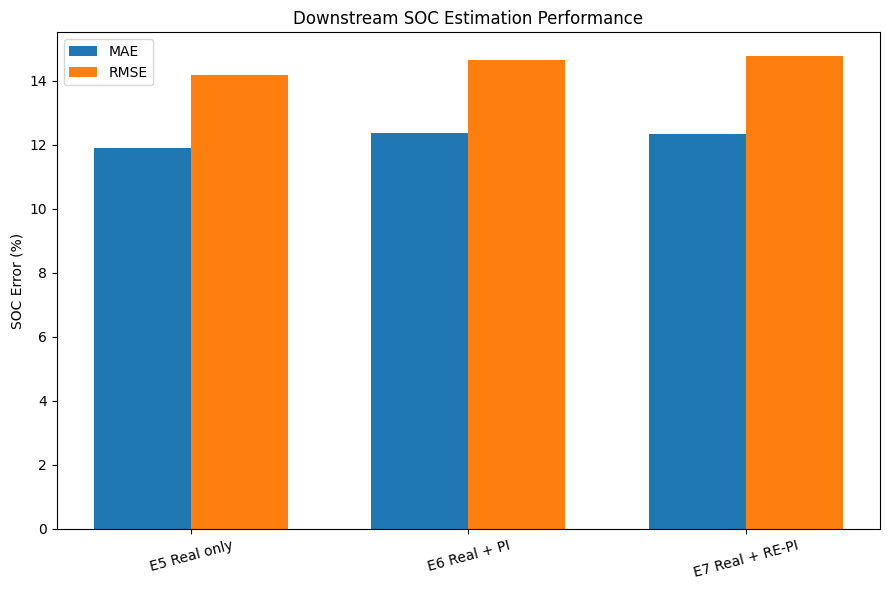


Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/figures/Figure_SOC_E5_E6_E7_MAE_RMSE.png


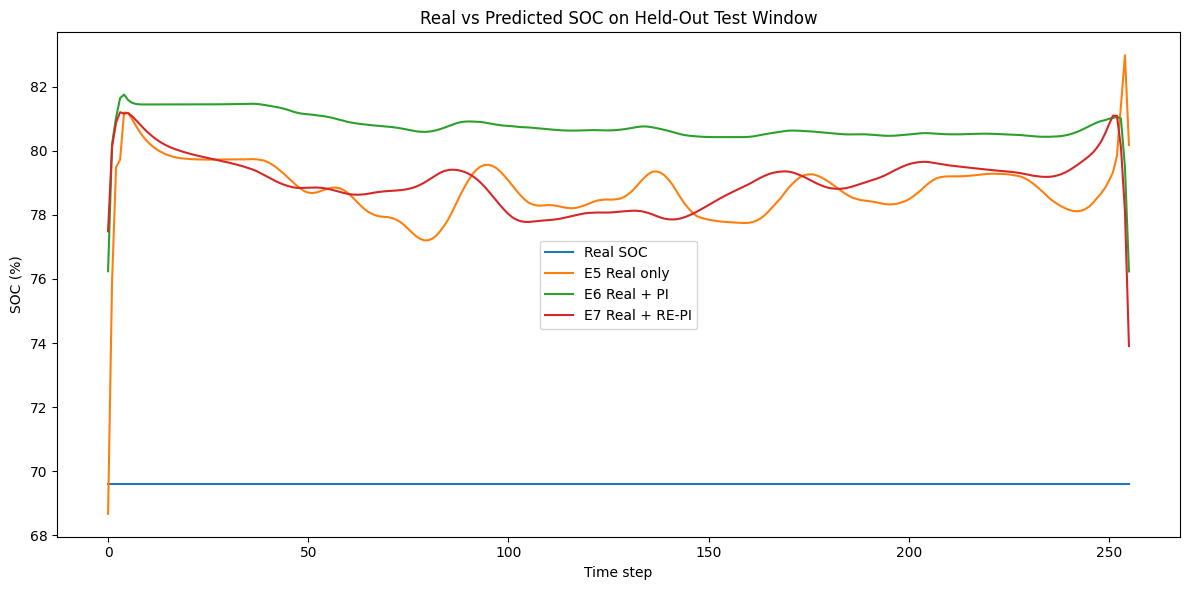


Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/figures/Figure_SOC_real_vs_predicted_test_window.png


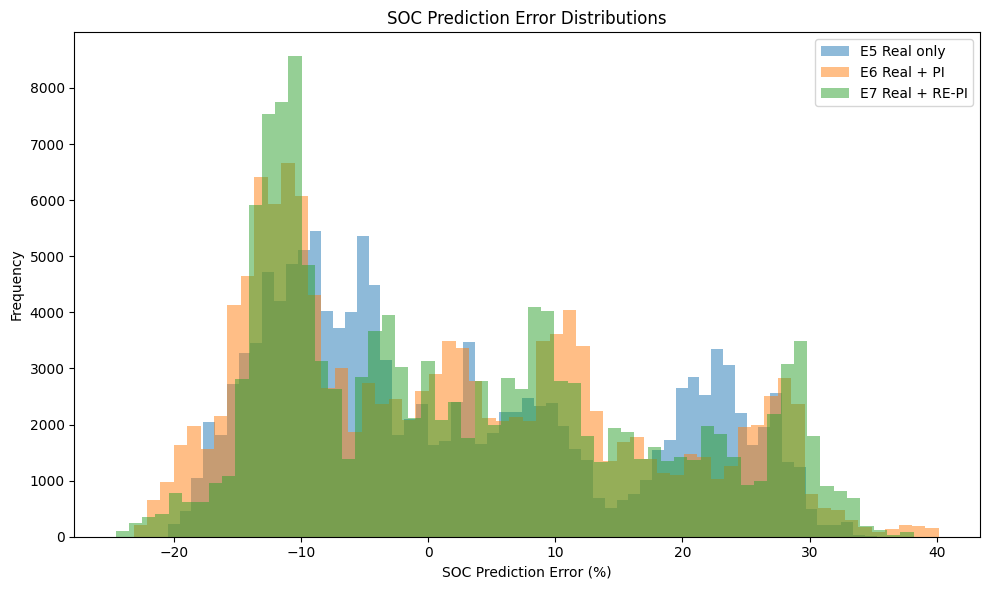


Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/figures/Figure_SOC_error_distributions_E5_E6_E7.png


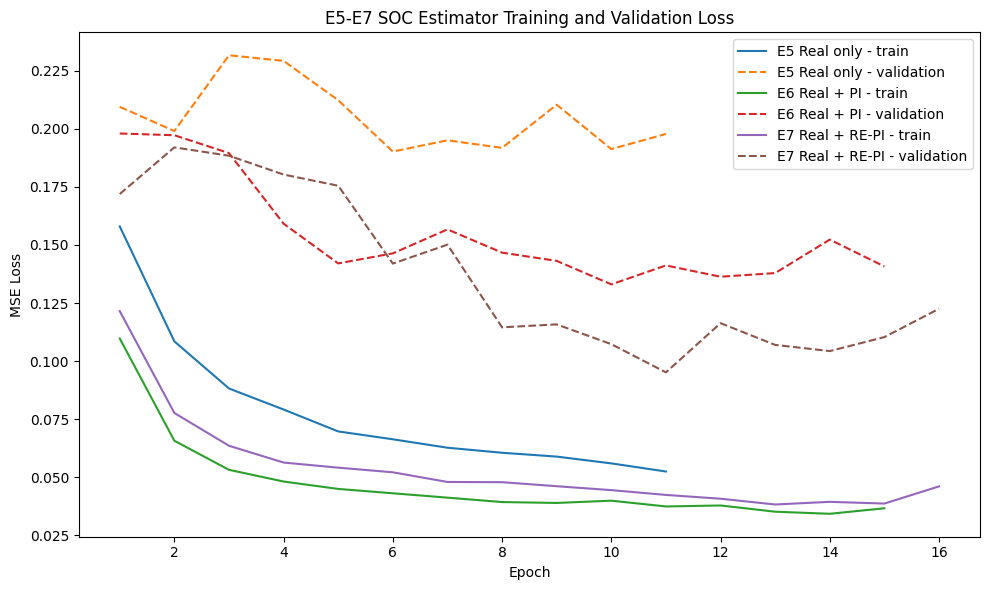


Saved:
/content/drive/MyDrive/RE_PI_CycleEV/results/figures/Figure_SOC_E5_E6_E7_training_validation_loss.png

SOC COMPARISON RELATIVE TO E5
Comparison  MAE_difference_percent  RMSE_difference_percent
  E6 vs E5                0.466418                 0.488817
  E7 vs E5                0.434882                 0.605582

STEP 29G COMPLETE

Final SOC result:
       Experiment  MAE_SOC_percent  RMSE_SOC_percent  Mean_Error_percent  Std_Error_percent  Max_Absolute_Error_percent
     E5_Real_Only        11.904641         14.169821            2.316216          13.979234                   35.256237
  E6_Real_Plus_PI        12.371059         14.658638            1.694691          14.560346                   40.156532
E7_Real_Plus_REPI        12.339523         14.775403            2.708686          14.524997                   38.170311

Figures saved in:
/content/drive/MyDrive/RE_PI_CycleEV/results/figures

Results saved in:
/content/drive/MyDrive/RE_PI_CycleEV/results/soc_downstream

IMPORTANT

In [ ]:
# ================================================================
# STEP 29G: FINAL SOC FIGURES AND E5-E7 COMPARISON
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*75)
print("STEP 29G: FINAL SOC FIGURES AND E5-E7 COMPARISON")
print("="*75)


# ================================================================
# 1. Directories
# ================================================================

soc_result_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/results/soc_downstream"
)

figure_dir = (
    "/content/drive/MyDrive/"
    "RE_PI_CycleEV/results/figures"
)

os.makedirs(soc_result_dir, exist_ok=True)
os.makedirs(figure_dir, exist_ok=True)


# ================================================================
# 2. Check required variables
# ================================================================

required_variables = [
    "test_soc_physical",
    "E5_pred_physical",
    "E6_pred_physical",
    "E7_pred_physical",
    "soc_test_results"
]

print("\nChecking required variables:")

for variable in required_variables:

    print(
        f"{variable:30s} -> "
        f"{variable in globals()}"
    )


# ================================================================
# 3. Reload SOC results if necessary
# ================================================================

results_path = os.path.join(
    soc_result_dir,
    "E5_E6_E7_SOC_test_results.csv"
)

if "soc_test_results" not in globals():

    soc_test_results = pd.read_csv(
        results_path
    )

    print("\nSOC results loaded from Drive.")


# ================================================================
# 4. Save/confirm final results table
# ================================================================

final_soc_path = os.path.join(
    soc_result_dir,
    "FINAL_E5_E6_E7_SOC_RESULTS.csv"
)

soc_test_results.to_csv(
    final_soc_path,
    index=False
)

print("\nFinal SOC results:")
print(
    soc_test_results.to_string(
        index=False
    )
)


# ================================================================
# 5. Figure 1 — MAE and RMSE comparison
# ================================================================

experiments = [
    "E5 Real only",
    "E6 Real + PI",
    "E7 Real + RE-PI"
]

mae_values = soc_test_results[
    "MAE_SOC_percent"
].values

rmse_values = soc_test_results[
    "RMSE_SOC_percent"
].values

x = np.arange(
    len(experiments)
)

width = 0.35

plt.figure(figsize=(9, 6))

plt.bar(
    x - width/2,
    mae_values,
    width,
    label="MAE"
)

plt.bar(
    x + width/2,
    rmse_values,
    width,
    label="RMSE"
)

plt.xticks(
    x,
    experiments,
    rotation=15
)

plt.ylabel(
    "SOC Error (%)"
)

plt.title(
    "Downstream SOC Estimation Performance"
)

plt.legend()

plt.tight_layout()

fig1_path = os.path.join(
    figure_dir,
    "Figure_SOC_E5_E6_E7_MAE_RMSE.png"
)

plt.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(fig1_path)


# ================================================================
# 6. Figure 2 — Real vs predicted SOC trajectories
# ================================================================
#
# Use one representative held-out test window.
# We use the first test window only for visualization.
# Quantitative metrics use ALL 520 test windows.

window_index = 0

real_soc_window = test_soc_physical[
    window_index
]

E5_soc_window = E5_pred_physical[
    window_index
]

E6_soc_window = E6_pred_physical[
    window_index
]

E7_soc_window = E7_pred_physical[
    window_index
]

time_axis = np.arange(
    len(real_soc_window)
)


plt.figure(figsize=(12, 6))

plt.plot(
    time_axis,
    real_soc_window,
    label="Real SOC"
)

plt.plot(
    time_axis,
    E5_soc_window,
    label="E5 Real only"
)

plt.plot(
    time_axis,
    E6_soc_window,
    label="E6 Real + PI"
)

plt.plot(
    time_axis,
    E7_soc_window,
    label="E7 Real + RE-PI"
)

plt.xlabel(
    "Time step"
)

plt.ylabel(
    "SOC (%)"
)

plt.title(
    "Real vs Predicted SOC on Held-Out Test Window"
)

plt.legend()

plt.tight_layout()

fig2_path = os.path.join(
    figure_dir,
    "Figure_SOC_real_vs_predicted_test_window.png"
)

plt.savefig(
    fig2_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(fig2_path)


# ================================================================
# 7. Figure 3 — SOC prediction errors
# ================================================================

E5_error = (
    E5_pred_physical -
    test_soc_physical
)

E6_error = (
    E6_pred_physical -
    test_soc_physical
)

E7_error = (
    E7_pred_physical -
    test_soc_physical
)


plt.figure(figsize=(10, 6))

plt.hist(
    E5_error.flatten(),
    bins=60,
    alpha=0.5,
    label="E5 Real only"
)

plt.hist(
    E6_error.flatten(),
    bins=60,
    alpha=0.5,
    label="E6 Real + PI"
)

plt.hist(
    E7_error.flatten(),
    bins=60,
    alpha=0.5,
    label="E7 Real + RE-PI"
)

plt.xlabel(
    "SOC Prediction Error (%)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "SOC Prediction Error Distributions"
)

plt.legend()

plt.tight_layout()

fig3_path = os.path.join(
    figure_dir,
    "Figure_SOC_error_distributions_E5_E6_E7.png"
)

plt.savefig(
    fig3_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(fig3_path)


# ================================================================
# 8. Figure 4 — Training/validation loss curves
# ================================================================

history_paths = {
    "E5 Real only": os.path.join(
        soc_result_dir,
        "E5_Real_Only_training_history.csv"
    ),

    "E6 Real + PI": os.path.join(
        soc_result_dir,
        "E6_Real_Plus_PI_training_history.csv"
    ),

    "E7 Real + RE-PI": os.path.join(
        soc_result_dir,
        "E7_Real_Plus_REPI_training_history.csv"
    )
}


plt.figure(figsize=(10, 6))

for label, path in history_paths.items():

    if os.path.exists(path):

        history_df = pd.read_csv(
            path
        )

        epochs = np.arange(
            1,
            len(history_df) + 1
        )

        plt.plot(
            epochs,
            history_df["loss"],
            label=f"{label} - train"
        )

        plt.plot(
            epochs,
            history_df["val_loss"],
            linestyle="--",
            label=f"{label} - validation"
        )

    else:

        print(
            "WARNING: history file not found:",
            path
        )


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "MSE Loss"
)

plt.title(
    "E5-E7 SOC Estimator Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

fig4_path = os.path.join(
    figure_dir,
    "Figure_SOC_E5_E6_E7_training_validation_loss.png"
)

plt.savefig(
    fig4_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(fig4_path)


# ================================================================
# 9. Calculate differences relative to E5
# ================================================================

E5_mae = soc_test_results.loc[
    soc_test_results["Experiment"] == "E5_Real_Only",
    "MAE_SOC_percent"
].iloc[0]

E5_rmse = soc_test_results.loc[
    soc_test_results["Experiment"] == "E5_Real_Only",
    "RMSE_SOC_percent"
].iloc[0]

E6_mae = soc_test_results.loc[
    soc_test_results["Experiment"] == "E6_Real_Plus_PI",
    "MAE_SOC_percent"
].iloc[0]

E6_rmse = soc_test_results.loc[
    soc_test_results["Experiment"] == "E6_Real_Plus_PI",
    "RMSE_SOC_percent"
].iloc[0]

E7_mae = soc_test_results.loc[
    soc_test_results["Experiment"] == "E7_Real_Plus_REPI",
    "MAE_SOC_percent"
].iloc[0]

E7_rmse = soc_test_results.loc[
    soc_test_results["Experiment"] == "E7_Real_Plus_REPI",
    "RMSE_SOC_percent"
].iloc[0]


comparison_df = pd.DataFrame({

    "Comparison": [
        "E6 vs E5",
        "E7 vs E5"
    ],

    "MAE_difference_percent": [
        E6_mae - E5_mae,
        E7_mae - E5_mae
    ],

    "RMSE_difference_percent": [
        E6_rmse - E5_rmse,
        E7_rmse - E5_rmse
    ]
})


comparison_path = os.path.join(
    soc_result_dir,
    "E5_E6_E7_SOC_comparison_relative_to_E5.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


print("\n" + "="*75)
print("SOC COMPARISON RELATIVE TO E5")
print("="*75)

print(
    comparison_df.to_string(
        index=False
    )
)


# ================================================================
# 10. Final summary
# ================================================================

print("\n" + "="*75)
print("STEP 29G COMPLETE")
print("="*75)

print("\nFinal SOC result:")
print(
    soc_test_results.to_string(
        index=False
    )
)

print("\nFigures saved in:")
print(figure_dir)

print("\nResults saved in:")
print(soc_result_dir)

print("\nIMPORTANT:")
print(
    "No additional model training was performed in Step 29G."
)

print(
    "\nThis completes the Step 29 downstream SOC experiment."
)

print("="*75)